Code to replicate cross-border climate risk analysis, with EORA26 as MRIOT and INFORM Climate Change as climate risk index.

# MRIOT
----

## EORA26

In [1]:
import pymrio

eora_storage = "C:/users/delah/Documents/Code/Exposition_commerciale/Approches_IO/MRIOT/EORA"

eora = pymrio.parse_eora26(year=2016, path=eora_storage)

mriot = eora
mriot.calc_all()

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1939: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=0, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)


# Climate risk index
-----

## Importing INFORM Climate Change
----

Here INFORM Climate Change is imported. Not all countries of EORA26 have a risk index (see 2.2 below). 

New countries are added to INFORM data (Taiwan, Hong Kong, Macau, Monaco, Andorra, San Marino). 

Two letter country codes are converted into three letter country codes.

low_risk_countries and high_risk_countries are extensively used in the following of the code.

In [15]:
import pandas as pd

file_path = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Indices/INFORM_Climate_Change_Index/InformCC_usable.xlsx'
Climate_Risk_INFORMCC = pd.read_excel(file_path)

# Replace NaN values in the 'Country' column with "NA"
Climate_Risk_INFORMCC['Country'].fillna("NA", inplace=True)

# Calculate the "Change in Risk' column
Climate_Risk_INFORMCC['Change in Risk'] = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']-Climate_Risk_INFORMCC['INFORM  2022']

# Add risk index for countries that are in EORA, have not risk index in INFORM, but can be linked to countries in INFORM.

# China - Taiwan
row_tw = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_tw['Country'] = 'TW'
# China - HK
row_hk = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_hk['Country'] = 'HK'
# China - Macao
row_mo = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_mo['Country'] = 'MO'
# France - Monaco
row_mc = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_mc['Country'] = 'MC'
# France - Andorra
row_ad = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_ad['Country'] = 'AD'
# Italy - San Marino
row_sm = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'IT'].copy()
row_sm['Country'] = 'SM'

Climate_Risk_INFORMCC = pd.concat([Climate_Risk_INFORMCC, row_tw, row_hk, row_mo, row_mc, row_ad, row_sm], ignore_index=True)
# As a consequence, there are now 197 countries in this database.
      
## Distributing all countries of INFORM CCI by risk level
########

df = Climate_Risk_INFORMCC
VLR_list = list(df[(df['INDEX 2050 Pessimistic'] >= 0) & (df['INDEX 2050 Pessimistic'] <= 1.9)]['Country'])
LR_list = list(df[(df['INDEX 2050 Pessimistic'] >= 2) & (df['INDEX 2050 Pessimistic'] <= 3.4)]['Country'])
MR_list = list(df[(df['INDEX 2050 Pessimistic'] >= 3.5) & (df['INDEX 2050 Pessimistic'] <= 4.9)]['Country'])
HR_list = list(df[(df['INDEX 2050 Pessimistic'] >= 5) & (df['INDEX 2050 Pessimistic'] <= 6.4)]['Country'])
VHR_list = list(df[(df['INDEX 2050 Pessimistic'] >= 6.5) & (df['INDEX 2050 Pessimistic'] <= 10)]['Country'])
# The sum of the lists is 197, because there are 191 countries in INFORM CCI + 6 countries linked to another country.

## Distributing EORA's countries by risk level
#########

# Importing EORA's countries (3-letter code)

leontieff= mriot.L
country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()
MRIOT_3_letters = list(country_list).copy()

# Some countries are discarded from EORA's data, because they do not have a risk level (ABW, PYF, GRL, BMU, CYM, VGB, NCL) or do not exist anymore (USR, ANT)
MRIOT_3_letters.remove('ABW')
MRIOT_3_letters.remove('PYF')
MRIOT_3_letters.remove('GRL')
MRIOT_3_letters.remove('BMU')
MRIOT_3_letters.remove('CYM')
MRIOT_3_letters.remove('VGB')
MRIOT_3_letters.remove('NCL')
MRIOT_3_letters.remove('USR')
MRIOT_3_letters.remove('ANT')
# There are then 180 EORA countries with risk indices.

# Conversion table (2-letter code / 3-letter)

csv_file = "C:/Users/delah/Documents/Code/Exposition_commerciale/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Converting the 180 EORA's countries to 2 letter code
code_mapping3to2 = dict(zip(iso_convert['alpha-3'], iso_convert['alpha-2']))
MRIOT_2_letters = [code_mapping3to2[code] for code in MRIOT_3_letters]

VLR_list_MRIOT = list(filter(lambda x: x in VLR_list, MRIOT_2_letters))
LR_list_MRIOT = list(filter(lambda x: x in LR_list, MRIOT_2_letters))
MR_list_MRIOT = list(filter(lambda x: x in MR_list, MRIOT_2_letters))
HR_list_MRIOT = list(filter(lambda x: x in HR_list, MRIOT_2_letters))
VHR_list_MRIOT = list(filter(lambda x: x in VHR_list, MRIOT_2_letters))
    
# Translating 3 letters to 2 letters
code_mapping2to3 = dict(zip(iso_convert['alpha-2'], iso_convert['alpha-3']))
VLR_list_MRIOT = [code_mapping2to3[code] for code in VLR_list_MRIOT]

LR_list_MRIOT = [code_mapping2to3[code] for code in LR_list_MRIOT]

MR_list_MRIOT = [code_mapping2to3[code] for code in MR_list_MRIOT]

HR_list_MRIOT = [code_mapping2to3[code] for code in HR_list_MRIOT]

VHR_list_MRIOT = [code_mapping2to3[code] for code in VHR_list_MRIOT]

# Defining a low and high risk country lists
high_risk_countries=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
low_risk_countries=LR_list_MRIOT+VLR_list_MRIOT

## Comparing countries in EORA26 and INFORM Climate Change
----

In the data, EORA has 189 countries. For a list, see : https://worldmrio.com/metadata.jsp.

In the data, INFORM Climate Change has 191 countries.

The countries in EORA that do not have a risk index in INFORM Climate Change are (see code below) : 
- ABW - Aruba
- AND - Andorra
- TWN - Taiwan (Officially known as the Republic of China)
- PYF - French Polynesia
- GRL - Greenland
- BMU - Bermuda
- CYM - Cayman Islands
- MCO - Monaco
- VGB - Virgin Islands
- MAC - Macau
- SMR - San Marino
- HKG - Hong Kong
- NCL - New Caledonia
- USR - USSR ? 
- ANT - Antillas Netherlands.

Two countries seem to be outdated : ANT is for the Netherlands Antilles (this entity was dissolved in 2010, and its territories were restructured) ; USR for USSR. 
They account for null or extremely small amounts of trade and we take them away from from the country list. EORA has then 187 countries.

Some islands (Aruba,French Polynesia,Greenland,Bermuda,Cayman Islands,Virgin Islands,New Caledonia) do not have a climate risk index and are discarded from the country list.

Some countries do not have a risk index, but are usally associated with a bigger country :
- Taiwan, Hong Kong and Macau can be associated with China,
- Andorra and Monaco with France, 
- Saint Marin with Italy.

In the end, EORA should have then 180 countries with risk index.

In [152]:
# Import INFORM CCI (2 digits) and EORA (3 digits) country lists
#####

inform_country_list_2 = list(Climate_Risk_INFORMCC['Country']) # 2 digits
eora_country_list_3 = list(leontieff.index.get_level_values(0).unique()) # 3 digits

# Clean EORA of non-existant countries
#####

# ANT and USR are taken out of the list
eora_country_list_3.remove('ANT')
eora_country_list_3.remove('USR')

# Make EORA country 2 digits
#####

# Correspondance between country name, alpha-2 and alpha-3 codes
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]
# Add South Sudan to iso_convert
new_row_1 = pd.DataFrame({'name': ['South Sudan'], 'alpha-2': ['SD'], 'alpha-3': ['SDS']})
new_row_2 = pd.DataFrame({'name': ['Sudan'], 'alpha-2': ['SD'], 'alpha-3': ['SUD']})
iso_convert = pd.concat([iso_convert, new_row_1,new_row_2])

code_mapping = dict(zip(iso_convert['alpha-3'], iso_convert['alpha-2']))

#Creating Eora 2 digits
eora_country_list_2 = [code_mapping[code] for code in eora_country_list_3]

# Comparing INFORM CCI (2 digits) with EORA (2 digits) country lists
#####

# We want to know which countries of EORA do not have a risk index
eora_not_inform = list(set(eora_country_list_2) - set(inform_country_list_2))

print("Countries in EORA with no risk index :", eora_not_inform)

Countries in EORA with no risk index : ['MC', 'VG', 'SM', 'KY', 'MO', 'HK', 'AW', 'AD', 'NC', 'PF', 'BM', 'TW', 'GL']


## Risk maps
----

### 5 risk levels

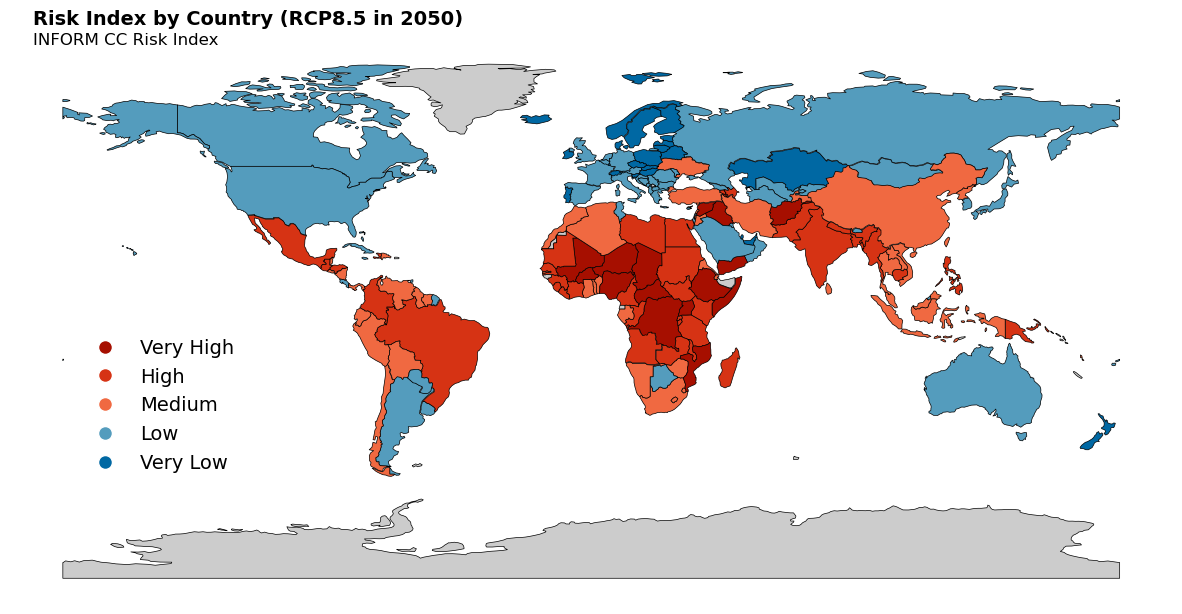

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

HR_list_MRIOT.append('SSD')
HR_list_MRIOT.append('SDN')

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Very High': '#a60f00' ,   # Dark Red
    'High': '#d63314',     # Medium Red
    'Medium': '#f06941',   # Light Red
    'Low': '#549cbd',    # Green
    'Very Low': '#0068a3',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in VLR_list_MRIOT:
        iso_to_color[code] = risk_levels['Very Low']
    elif code in LR_list_MRIOT:
        iso_to_color[code] = risk_levels['Low']
    elif code in MR_list_MRIOT:
        iso_to_color[code] = risk_levels['Medium']
    elif code in HR_list_MRIOT:
        iso_to_color[code] = risk_levels['High']
    elif code in VHR_list_MRIOT:
        iso_to_color[code] = risk_levels['Very High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=14)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig('C:/Users/delah/Documents/Code/Exposition_commerciale/Tables IO/figures/world_map_EORA_INFORM.png')

# Show the map
plt.show()

HR_list_MRIOT.remove('SSD')
HR_list_MRIOT.remove('SDN')

### Low/High risk

Low / High risk threshold is put at 3.5, that is between Low Risk and Medium Risk categories.

Generating low/high country lists with different thresholds 

In [4]:
import pandas as pd

file_path = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Indices/INFORM_Climate_Change_Index/InformCC_usable.xlsx'
Climate_Risk_INFORMCC = pd.read_excel(file_path)
# Replace NaN values in the 'Country' column with "NA"
Climate_Risk_INFORMCC['Country'].fillna("NA", inplace=True)
# Calculate the difference and add it as a new column
Climate_Risk_INFORMCC['Change in Risk'] = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']-Climate_Risk_INFORMCC['INFORM  2022']
# Add risk index for countries that are in EORA, have not risk index in INFORM CCI, but can be linked to countries in INFORM CCI

# China - Taiwan
row_tw = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_tw['Country'] = 'TW'
# China - HK
row_hk = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_hk['Country'] = 'HK'
# China - Macao
row_mo = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_mo['Country'] = 'MO'
# France - Monaco
row_mc = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_mc['Country'] = 'MC'
# France - Andorra
row_ad = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_ad['Country'] = 'AD'
# Italy - San Marino
row_sm = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'IT'].copy()
row_sm['Country'] = 'SM'

Climate_Risk_INFORMCC = pd.concat([Climate_Risk_INFORMCC, row_tw, row_hk, row_mo, row_mc, row_ad, row_sm], ignore_index=True)
# As a consequence, there are now 197 countries in this database.

# Conversion table (2-letter code / 3-letter)

csv_file = "C:/Users/delah/Documents/Code/Exposition_commerciale/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Threshold function
######

def create_risk_level_lists(inform_ccri_df, t):
    
    thresholds= {
    'VLR': (0, 1.9),
    'LR': (2, 3.4+t),
    'MR': (3.5+t, 4.9),
    'HR': (5, 6.4),
    'VHR': (6.5, 10)
    }

    # INFORM CCI 2 letters code by risk level
    df = inform_ccri_df
    risk_level_lists = {level: [] for level in thresholds.keys()}
    for level, (lower, upper) in thresholds.items():
        risk_level_lists[level] = list(df[(df['INDEX 2050 Pessimistic'] >= lower) & (df['INDEX 2050 Pessimistic'] <= upper)]['Country'])
   
    leontieff= mriot.L
    country_list = leontieff.index.get_level_values(0).unique()
    sector_list = leontieff.index.get_level_values(1).unique()

    MRIOT_3_letters = list(country_list).copy()

    # ANT, USR,  ABW, PYF, GRL, BMU, CYM, VGB, NCL are discarded because they either do not exist (USR) or do not have a risk index.
    MRIOT_3_letters.remove('ANT')  
    MRIOT_3_letters.remove('USR')  
    MRIOT_3_letters.remove('ABW')
    MRIOT_3_letters.remove('PYF')
    MRIOT_3_letters.remove('GRL')
    MRIOT_3_letters.remove('BMU')
    MRIOT_3_letters.remove('CYM')
    MRIOT_3_letters.remove('VGB')
    MRIOT_3_letters.remove('NCL')
    
    risk_level_lists_MRIOT = {level: [] for level in thresholds.keys()}
    
    code_mapping3to2 = dict(zip(iso_convert['alpha-3'], iso_convert['alpha-2']))

    # Triage des codes OCDE 2 lettres selon les niveaux de risque.
    MRIOT_2_letters = [code_mapping3to2[code] for code in MRIOT_3_letters]
    
    # Categorize countries by risk level based on 'INDEX 2050 Pessimistic' values
    for level, (lower, upper) in thresholds.items():
        risk_level_lists_MRIOT[level] = list(filter(lambda x: x in risk_level_lists[level], MRIOT_2_letters))    
    
    code_mapping2to3 = dict(zip(iso_convert['alpha-2'], iso_convert['alpha-3']))

    # Translate the lists of two-letter codes to three-letter codes
    risk_level_lists_MRIOT['VLR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['VLR']]

    risk_level_lists_MRIOT['LR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['LR']]

    risk_level_lists_MRIOT['MR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['MR']]

    risk_level_lists_MRIOT['HR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['HR']]

    risk_level_lists_MRIOT['VHR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['VHR']]

    return risk_level_lists_MRIOT


# Assuming 'Climate_Risk_INFORMCC' is your INFORM CCRI DataFrame and 'iso_convert' is your conversion DataFrame
# Define your thresholds here, for example:
thresholds= {
    'VLR': (0, 1.9),
    'LR': (2, 3.4),
    'MR': (3.5, 4.9),
    'HR': (5, 6.4),
    'VHR': (6.5, 10)
}


# Call the function with simulated data and thresholds
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, 0)

Displaying maps for standard threshold (= 3.5)

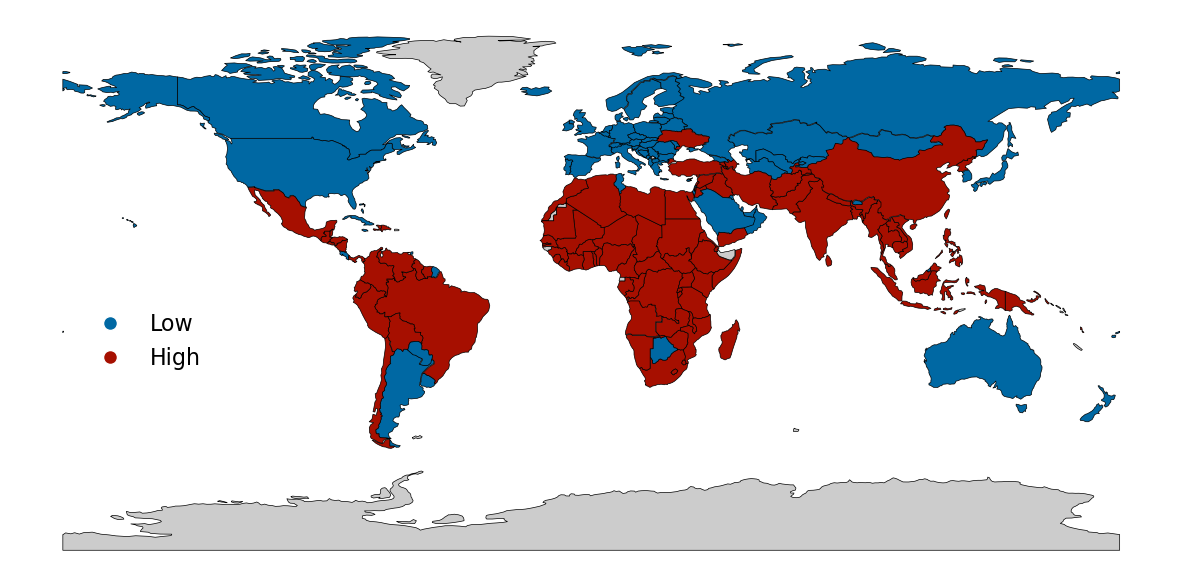

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, +0)

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in risk_level_lists_MRIOT['VLR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['LR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['MR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['HR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['VHR']:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

low_risk_countries = risk_level_lists_MRIOT['VLR']+risk_level_lists_MRIOT['LR']
high_risk_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Extended Data\Figure1b.png')

# Show the map
plt.show()

Displaying maps for non standard thresholds (t)

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

t=-0.75
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, t)

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in risk_level_lists_MRIOT['VLR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['LR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['MR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['HR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['VHR']:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

low_risk_countries = risk_level_lists_MRIOT['VLR']+risk_level_lists_MRIOT['LR']
high_risk_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4a.png')

t=+0.75
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, t)

# Load the GeoJSON file
world = gpd.read_file("C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in risk_level_lists_MRIOT['VLR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['LR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['MR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['HR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['VHR']:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

low_risk_countries = risk_level_lists_MRIOT['VLR']+risk_level_lists_MRIOT['LR']
high_risk_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])


plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4b.png')

# Show the map
plt.show()

NameError: name 'create_risk_level_lists' is not defined

## Other data
---

### Developed, developing, least developed country lists

Data come from UNTCAD : https://unctadstat.unctad.org/EN/Classifications.html.

In addition,
- Macau and Hong-Kong have been attributed to the same development group as Chine (developing),
- Monaco is considered developed,
- Virgin Islands (British) has been put in the same group as the United Kingdom (developed).

Names have been changed marginally to be coherent with country names used in other data.

In [7]:
least_developed_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "Cambodia",
    "Lao People's Democratic Republic",
    "Myanmar",
    "Nepal",
    "Yemen",
    "Yemen, Arab Republic",
    "Yemen, Democratic",
    "Angola",
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Congo, Democratic Republic of the",
    "Djibouti",
    "Eritrea",
    "Ethiopia",
    "Ethiopia (...1991)",
    "Gambia",
    "Guinea",
    "Guinea-Bissau",
    "Lesotho",
    "Liberia",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mozambique",
    "Niger",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Somalia",
    "South Sudan",
    "Sudan",
    "Sudan (...2011)",
    "Tanzania, United Republic of",
    "Togo",
    "Uganda",
    "Zambia",
    "Comoros",
    "Haiti",
    "Kiribati",
    "Sao Tome and Principe",
    "Solomon Islands",
    "Timor-Leste",
    "Tuvalu"
]

developed_countries = [
    "Bermuda",
    "Canada",
    "Greenland",
    "Saint Pierre and Miquelon",
    "United States of America",
    "Developed economies: Asia and Oceania",
    "Developed economies: Asia",
    "Israel",
    "Japan",
    "Korea, Republic of",
    "Developed economies: Oceania",
    "Australia",
    "Christmas Island",
    "Cocos (Keeling) Islands",
    "Heard Island and McDonald Islands",
    "New Zealand",
    "Norfolk Island",
    "United States Minor Outlying Islands",
    "Developed economies: Europe",
    "Albania",
    "Andorra",
    "Austria",
    "Belarus",
    "Belgium",
    "Bosnia and Herzegovina",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Czechoslovakia",
    "Denmark",
    "Estonia",
    "Faroe Islands",
    "Finland",
    "France",
    "Germany",
    "Germany, Democratic Republic of",
    "Germany, Federal Republic of",
    "Gibraltar",
    "Greece",
    "Holy See",
    "Hungary",
    "Iceland",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Moldova, Republic of",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "Russian Federation",
    "San Marino",
    "Serbia",
    "Serbia and Montenegro",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland", "Liechtenstein",
    "Ukraine",
    "Union of Soviet Socialist Republics",
    "United Kingdom of Great Britain and Northern Ireland",
    "Yugoslavia, Soc. Fed. Rep. of",
    "Monaco","Virgin Islands (British)","Taiwan, Province of China"
]

developing_countries = [
    "Algeria",
    "American Samoa",
    "Anguilla",
    "Antigua and Barbuda",
    "Argentina",
    "Armenia",
    "Aruba",
    "Azerbaijan",
    "Bahamas",
    "Bahrain",
    "Barbados",
    "Belize",
    "Bolivia (Plurinational State of)",
    "Bonaire, Sint Eustatius and Saba",
    "Botswana",
    "Bouvet Island",
    "Brazil",
    "British Indian Ocean Territory",
    "British Virgin Islands",
    "Brunei Darussalam",
    "Cabo Verde",
    "Cameroon",
    "Cayman Islands",
    "Chile",
    "China",
    "China, Hong Kong SAR",
    "China, Macao SAR",
    "China, Taiwan Province of",
    "Colombia",
    "Congo",
    "Cook Islands",
    "Costa Rica",
    "Côte d'Ivoire",
    "Cuba",
    "Curaçao",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Egypt",
    "El Salvador",
    "Equatorial Guinea",
    "Eswatini",
    "Falkland Islands (Malvinas)",
    "Fiji",
    "French Polynesia",
    "French Southern Territories",
    "Gabon",
    "Georgia",
    "Ghana",
    "Grenada",
    "Guam",
    "Guatemala",
    "Guyana",
    "Honduras",
    "India",
    "Indonesia",
    "Indonesia (...2002)",
    "Iran (Islamic Republic of)",
    "Iraq",
    "Jamaica",
    "Jordan",
    "Kazakhstan",
    "Kenya",
    "Korea (Democratic People's Republic of)",
    "Kuwait",
    "Kyrgyzstan",
    "Lebanon",
    "Libya",
    "Malaysia",
    "Maldives",
    "Marshall Islands",
    "Mauritius",
    "Mexico",
    "Micronesia (Federated States of)",
    "Mongolia",
    "Montserrat",
    "Morocco",
    "Namibia",
    "Nauru",
    "Netherlands Antilles",
    "New Caledonia",
    "Nicaragua",
    "Nigeria",
    "Niue",
    "Northern Mariana Islands",
    "Oman",
    "Pacific Islands, Trust Territory",
    "Pakistan",
    "Palau",
    "Panama",
    "Panama, Canal Zone",
    "Panama, excluding Canal Zone",
    "Papua New Guinea",
    "Paraguay",
    "Peru",
    "Philippines",
    "Pitcairn",
    "Qatar",
    "Saint Barthélemy",
    "Saint Helena",
    "Saint Kitts and Nevis",
    "Saint Lucia",
    "Saint Martin (French part)",
    "Saint Vincent and the Grenadines",
    "Samoa",
    "Saudi Arabia",
    "Seychelles",
    "Singapore",
    "Sint Maarten (Dutch part)",
    "South Africa",
    "South Georgia and South Sandwich Islands",
    "Sri Lanka",
    "Palestine, State of",
    "Suriname",
    "Syrian Arab Republic",
    "Tajikistan",
    "Thailand",
    "Tokelau",
    "Tonga",
    "Trinidad and Tobago",
    "Tunisia",
    "Turkey",
    "Turkmenistan",
    "Turks and Caicos Islands",
    "United Arab Emirates",
    "Uruguay",
    "Uzbekistan",
    "Vanuatu",
    "Venezuela (Bolivarian Republic of)",
    "Viet Nam",
    "Wallis and Futuna Islands",
    "Western Sahara",
    "Zimbabwe",
    "Hong Kong",
    "Macao"
]

# Country-level analysis
----

## Inputs
----

### Inputs (Direct)
----

In [127]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd
final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)
Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()

intermediary = mriot.Z

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######

values = {'VLR (%)': [0] * country_list.size}
cForeign_Inputs_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cForeign_Inputs_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cForeign_Inputs_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cForeign_Inputs_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cForeign_Inputs_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cForeign_Inputs_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)


# Foreign_GO
######

for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_VLR = 0
    intrants_c_foreign_LR = 0
    intrants_c_foreign_MR = 0
    intrants_c_foreign_HR = 0
    intrants_c_foreign_VHR = 0
    intrants_c_foreign_ROW = 0
    
    for s in sector_list:
        intermediary_cs = intermediary[c,s]
        intermediary_cs_foreign = intermediary_cs[intermediary_cs.index.get_level_values('region') != c]
        intermediary_cs_foreign_VLR = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(VLR_list_MRIOT)]
        intermediary_cs_foreign_LR = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(LR_list_MRIOT)]
        intermediary_cs_foreign_MR = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(MR_list_MRIOT)]
        intermediary_cs_foreign_HR = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(HR_list_MRIOT)]
        intermediary_cs_foreign_VHR = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(VHR_list_MRIOT)]
        intermediary_cs_foreign_ROW = intermediary_cs[~intermediary_cs.index.get_level_values('region').isin([c]) & intermediary_cs.index.get_level_values('region').isin(['ROW'])]
        
        intrants_c = intrants_c + intermediary_cs.sum()
        intrants_c_foreign = intrants_c_foreign + intermediary_cs_foreign.sum() 
        intrants_c_foreign_VLR = intrants_c_foreign_VLR + intermediary_cs_foreign_VLR.sum()  
        intrants_c_foreign_LR = intrants_c_foreign_LR + intermediary_cs_foreign_LR.sum()  
        intrants_c_foreign_MR = intrants_c_foreign_MR + intermediary_cs_foreign_MR.sum()   
        intrants_c_foreign_HR = intrants_c_foreign_HR + intermediary_cs_foreign_HR.sum()   
        intrants_c_foreign_VHR = intrants_c_foreign_VHR + intermediary_cs_foreign_VHR.sum()   
        intrants_c_foreign_ROW = intrants_c_foreign_ROW + intermediary_cs_foreign_ROW.sum()  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c*100
    cForeign_Inputs_LR.loc[c] = intrants_c_foreign_LR / intrants_c *100
    cForeign_Inputs_MR.loc[c] = intrants_c_foreign_MR / intrants_c *100
    cForeign_Inputs_HR.loc[c] = intrants_c_foreign_HR / intrants_c*100
    cForeign_Inputs_VHR.loc[c] = intrants_c_foreign_VHR / intrants_c *100
    cForeign_Inputs_ROW.loc[c] = intrants_c_foreign_ROW / intrants_c*100
    
    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_VLR, cForeign_Inputs_LR, cForeign_Inputs_MR, cForeign_Inputs_HR, cForeign_Inputs_VHR,cForeign_Inputs_ROW, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_direct = pd.concat(dataframes_to_concat, axis=1)


# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_direct = pd.concat(dataframes_to_concat, axis=1)
resulting_dataframe_country_inputs_direct = resulting_dataframe_country_inputs_direct.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_direct.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_inputs_direct = result

C:\Users\delah\AppData\Local\Temp\ipykernel_26000\3879646238.py:15: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\3879646238.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '20.84770098129413' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\3879646238.py:83: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.927357896171883' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipyk

### Inputs (Leontief)
-----

#### Code
----

In [ ]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######

values = {'cFIR (%)': [0] * country_list.size}
cFIR1 = pd.DataFrame(values, index=country_list)

values = {'VLR (%)': [0] * country_list.size}
cForeign_Inputs_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cForeign_Inputs_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cForeign_Inputs_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cForeign_Inputs_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cForeign_Inputs_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cForeign_Inputs_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)

# Foreign_GO
######

# Définition OCDE

#for c in country_list:
#    for s in sector_list:
#        cFIR.loc[c] = FIR.loc[c, s].squeeze() * gross_output.loc[c, s].squeeze() / gross_output.loc[c].sum().squeeze() + cFIR.loc[c].squeeze()

# cForeign_GO

for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_VLR = 0
    intrants_c_foreign_LR = 0
    intrants_c_foreign_MR = 0
    intrants_c_foreign_HR = 0
    intrants_c_foreign_VHR = 0
    intrants_c_foreign_ROW = 0
    
    for s in sector_list:
        leontieff_cs = leontieff[c,s]
        final_production_cs = final_production[c,s]
        leontieff_cs_foreign = leontieff_cs[leontieff_cs.index.get_level_values('region') != c]
        leontieff_cs_foreign_VLR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VLR_list_MRIOT)]
        leontieff_cs_foreign_LR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(LR_list_MRIOT)]
        leontieff_cs_foreign_MR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(MR_list_MRIOT)]
        leontieff_cs_foreign_HR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(HR_list_MRIOT)]
        leontieff_cs_foreign_VHR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VHR_list_MRIOT)]
        leontieff_cs_foreign_ROW = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(['ROW'])]
        
        intrants_cs = (leontieff_cs*final_production_cs).sum()
        intrants_cs_foreign = (leontieff_cs_foreign*final_production_cs).sum()
        intrants_cs_foreign_VLR = (leontieff_cs_foreign_VLR*final_production_cs).sum()
        intrants_cs_foreign_LR = (leontieff_cs_foreign_LR*final_production_cs).sum()
        intrants_cs_foreign_MR = (leontieff_cs_foreign_MR*final_production_cs).sum()
        intrants_cs_foreign_HR = (leontieff_cs_foreign_HR*final_production_cs).sum()
        intrants_cs_foreign_VHR = (leontieff_cs_foreign_VHR*final_production_cs).sum()
        intrants_cs_foreign_ROW = (leontieff_cs_foreign_ROW*final_production_cs).sum()

        
        intrants_c=intrants_c + intrants_cs
        intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
        intrants_c_foreign_VLR = intrants_c_foreign_VLR + intrants_cs_foreign_VLR  
        intrants_c_foreign_LR = intrants_c_foreign_LR + intrants_cs_foreign_LR  
        intrants_c_foreign_MR = intrants_c_foreign_MR + intrants_cs_foreign_MR   
        intrants_c_foreign_HR = intrants_c_foreign_HR + intrants_cs_foreign_HR   
        intrants_c_foreign_VHR = intrants_c_foreign_VHR + intrants_cs_foreign_VHR   
        intrants_c_foreign_ROW = intrants_c_foreign_ROW + intrants_cs_foreign_ROW  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c*100
    cForeign_Inputs_LR.loc[c] = intrants_c_foreign_LR / intrants_c *100
    cForeign_Inputs_MR.loc[c] = intrants_c_foreign_MR / intrants_c *100
    cForeign_Inputs_HR.loc[c] = intrants_c_foreign_HR / intrants_c*100
    cForeign_Inputs_VHR.loc[c] = intrants_c_foreign_VHR / intrants_c *100
    cForeign_Inputs_ROW.loc[c] = intrants_c_foreign_ROW / intrants_c*100
    
    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_VLR, cForeign_Inputs_LR, cForeign_Inputs_MR, cForeign_Inputs_HR, cForeign_Inputs_VHR,cForeign_Inputs_ROW, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)
resulting_dataframe_country_inputs_leontief = resulting_dataframe_country_inputs_leontief.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_inputs_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_4480\90309229.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_4480\90309229.py:104: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.81758874134755' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_4480\90309229.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9.68913087916651' has dtype incompatible with int64, please explicitly cast to a compatible dtype firs

In [116]:
resulting_dataframe_country_inputs_leontief

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,11.528853,23.229252,14.411164,6.034116,1.882372,0,58.516092,41.483908,34.758105,22.327652,39.112474
1,Hong Kong,High Risk,4.0,0.1,East Asia & Pacific,High income,7350409.0,Developing,4.051864,16.618468,34.818931,1.788555,0.063759,0,57.354527,42.645473,20.670332,36.671245,63.952279
2,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,6.357098,14.808846,20.675106,6.036783,2.696988,0,51.006468,48.993532,21.165943,29.408877,58.149247
3,Singapore,Low Risk,0.7,0.1,East Asia & Pacific,High income,5673743.0,Developing,3.550303,21.839808,19.836127,2.764829,0.107306,0,48.111373,51.888627,25.390111,22.708262,47.212121
4,Luxembourg,Low Risk,1.2,0.1,Europe & Central Asia,High income,657569.0,Developed,4.588006,37.986040,3.289430,0.874622,0.123913,0,46.874044,53.125956,42.574046,4.287965,9.150195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.305173,0.629878,0.544019,0.162113,0.049796,0,1.714303,98.285697,0.935051,0.755928,44.703583
183,South Sudan,High Risk,8.6,0.1,NaN,NaN,0.0,Least Developed,0.302446,0.602943,0.383765,0.160836,0.044380,0,1.527666,98.472334,0.905389,0.588981,39.413345
184,Guyana,High Risk,4.2,-0.1,Latin America & Caribbean,High income,813834.0,Developing,0.063690,0.880956,0.222943,0.055163,0.002026,0,1.225018,98.774982,0.944646,0.280132,22.872093
185,Myanmar,High Risk,6.3,0.1,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.150082,0.351130,0.219491,0.079762,0.012288,0,0.824747,99.175253,0.501212,0.311540,38.331540


In [110]:
df=resulting_dataframe_country_inputs_leontief
median_high_risk_developed_inputs = df[df['Development'] == 'Developed']['High Risk'].median()
median_high_risk_developed_inputs

4.381489653538567

#### Plot
----

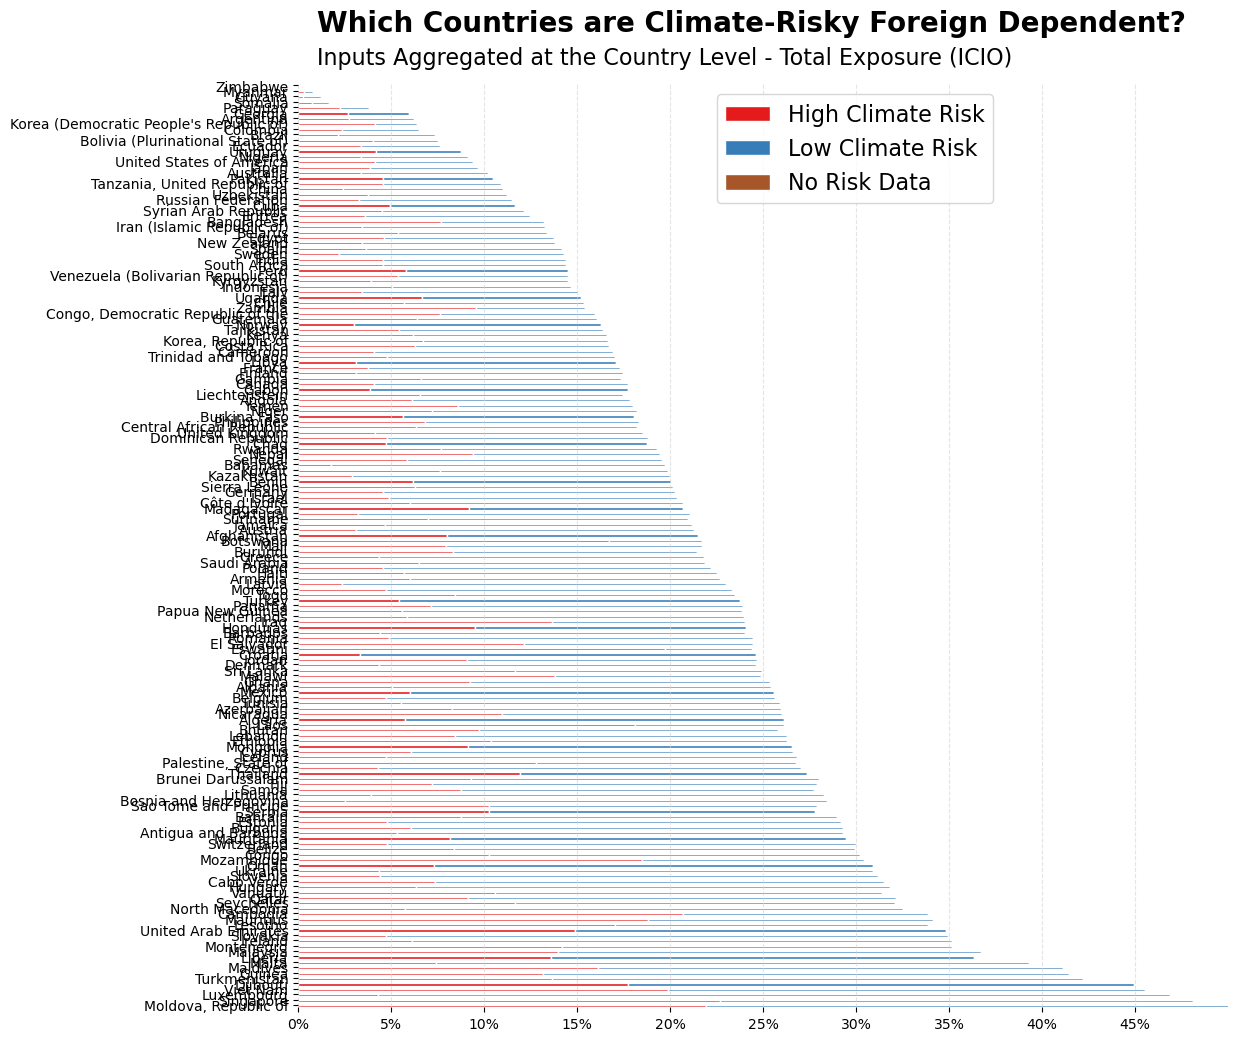

In [165]:
# Affichage par pays
######

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # Import seaborn for color palettes

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief

ocde_filter = 'no'

if ocde_filter=='yes':
    oecd_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Colombia', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel',
    'Italy', 'Japan', 'Korea, Republic of', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands',
    'New Zealand', 'Norway', 'Poland', 'Portugal', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'Switzerland', 'Turkey', 'United Kingdom of Great Britain and Northern Ireland', 'United States of America']
    # Filter the DataFrame to include only OECD member countries
    result = result[result['Country'].isin(oecd_countries)]

result['Country'] = result['Country'].replace('United Kingdom of Great Britain and Northern Ireland', 'United Kingdom')
result['Country'] = result['Country'].replace("Lao People's Democratic Republic", 'Laos')
result['Country'] = result['Country'].replace("Taiwan, Province of China", 'Taiwan')

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Width of the bars
bar_width = 0.4

# Positions of the left bar-boundaries
bar_l = [i+1 for i in range(len(result['Country']))]

# Positions of the x-axis ticks (center of the bars as bar labels)
tick_pos = [i+(bar_width/2) for i in bar_l]

# Creating the bars

# Creating the bars

affichage = 'agrege'

if affichage == 'detail':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set2", 7)

    ax.barh(bar_l, result['VLR (%)'], height=bar_width, label='Very low risk', color=color_palette[0], edgecolor='white')

    ax.barh(bar_l, result['LR (%)'], left=result['VLR (%)'], height=bar_width, label='Low risk', color=color_palette[1], edgecolor='white')

    ax.barh(bar_l, result['MR (%)'], left=result['VLR (%)']+result['LR (%)'], height=bar_width, label='Medium risk', color=color_palette[2], edgecolor='white')

    ax.barh(bar_l, result['HR (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)'], height=bar_width, label='High risk', color=color_palette[3], edgecolor='white')

    ax.barh(bar_l, result['VHR (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)']+result['HR (%)'], height=bar_width, label='Very high risk', color=color_palette[4], edgecolor='white')

    ax.barh(bar_l, result['ROW (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)']+result['HR (%)']+result['VHR (%)'], height=bar_width, label='ROW', color=color_palette[5], edgecolor='white')

    #ax.barh(bar_l, result['Local (%)'], left=result['High Risk']+result['Low Risk']+result['ROW (%)'], height=bar_width, label='Local', color='grey', edgecolor='white')

    
if affichage == 'agrege':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set1", 7)

    ax.barh(bar_l, result['High Risk'], height=bar_width, label='High Climate Risk', color=color_palette[0], edgecolor='white')

    ax.barh(bar_l, result['Low Risk'], left=result['High Risk'], height=bar_width, label='Low Climate Risk', color=color_palette[1], edgecolor='white')

    ax.barh(bar_l, result['ROW (%)'], left=result['High Risk']+result['Low Risk'], height=bar_width, label='No Risk Data', color=color_palette[6], edgecolor='white')
    
    # Set bold title in the left corner
    plt.text(0.02, 1.08, "Which Countries are Climate-Risky Foreign Dependent?", transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

    # Add a subtitle
    plt.text(0.02, 1.04, "Inputs Aggregated at the Country Level - Total Exposure (ICIO)", transform=ax.transAxes, fontsize=16, va='top', ha='left')


    #ax.barh(bar_l, result['Local (%)'], left=result['High Risk']+result['Low Risk']+result['ROW (%)'], height=bar_width, label='Local', color='grey', edgecolor='white')

        
if affichage == 'foreign':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set2", 7)

    ax.barh(bar_l, result['Foreign (%)'], height=bar_width, label='Foreign Inputs', color='grey', edgecolor='white')
    # Set bold title in the left corner
    plt.text(0.02, 1.08, "Which Countries are Foreign Dependent?", transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

    # Add a subtitle
    plt.text(0.02, 1.04, "Inputs Aggregated at the Country Level - Total Exposure (ICIO)", transform=ax.transAxes, fontsize=16, va='top', ha='left')


# Set the position of the x ticks
ax.set_yticks(tick_pos)

# Set the labels for the ticks
ax.set_yticklabels(result['Country'])


# Setting the x-axis and y-axis limits
plt.xlim([0,50])
plt.ylim([min(tick_pos)-bar_width, max(tick_pos)+bar_width])

# Adding the legend and title
plt.legend(loc=(0.45, 0.87),fontsize=16, frameon=True, facecolor='white')
# Set bold title in the left corner

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize the x-axis ticks and labels
x_ticks = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]  # Define your desired x-axis tick positions
x_tick_labels = [str(x) + '%' for x in x_ticks]  # Convert positions to labels

# Set the x-axis ticks and labels
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels)

# Customize the appearance of x-axis labels
plt.xticks(fontsize=10, rotation=0)  # Adjust the fontsize and rotation as needed

# Add light gray lines for x-axis labels
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='lightgray')

In [58]:
low_risk_list=VLR_list_MRIOT+LR_list_MRIOT
high_risk_list=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT

CI_country=mriot.Z.groupby('region').sum().T.groupby('region').sum().T
no_diag=CI_country
# Set the diagonal elements to zero
np.fill_diagonal(no_diag.values, 0)
CI = no_diag

# Create a new column to identify if the region is in the list or not
CI['Risk'] = CI.index.isin(high_risk_list)

# Group by this new column and sum all other columns
CI = CI.groupby('Risk').sum()
CI=CI.T
# Create a new column to identify if the region is in the list or not
CI['Risk'] = CI.index.isin(high_risk_list)

# Group by this new column and sum all other columns
CI = CI.groupby('Risk').sum()
CI=CI.T
CI
# Rename index and columns
CI.index = CI.index.map({False: 'Low Risk', True: 'High Risk'})
CI.columns = CI.columns.map({False: 'Low Risk', True: 'High Risk'})

CI

Risk,Low Risk,High Risk
Risk,,
Low Risk,6.608714e+09,2.825458e+09
High Risk,2.449865e+09,1.422449e+09


#### Distribution of Climate-Risk-Foreign Exposure
-----

##### Absolute Risk / Country
----

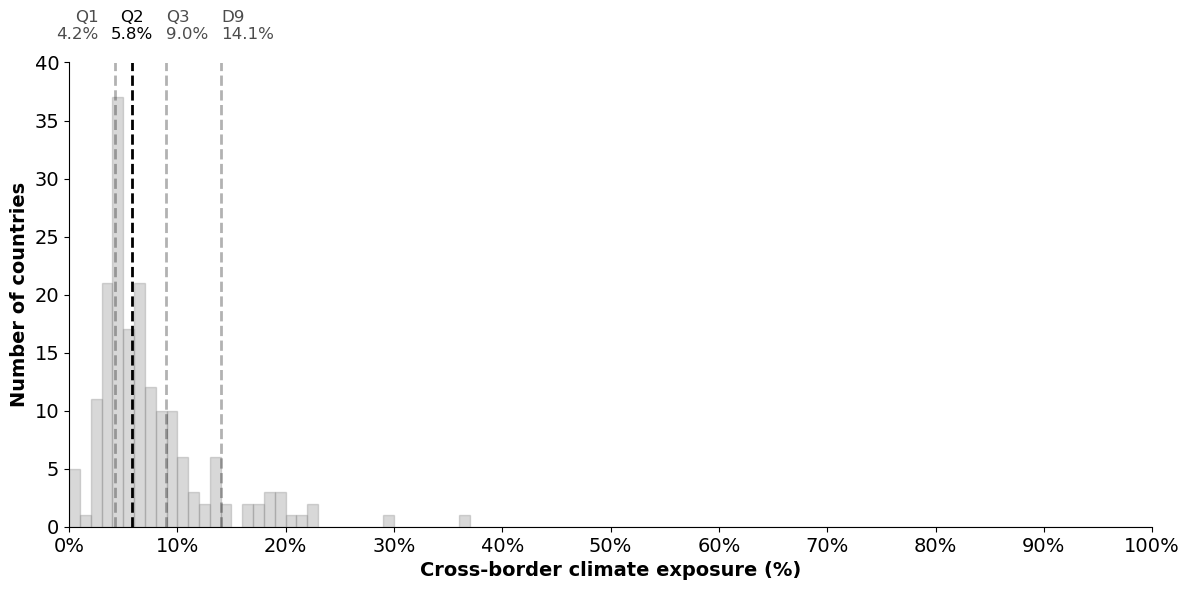

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Count rows for the entire dataset
total_row_counts = count_rows_in_bins(df, bins, 'High Risk')
data_to_plot = total_row_counts
color = 'grey'

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)

# Calculate and plot median and quartiles
flat_data = df['High Risk']
median_value = np.median(flat_data)
first_quartile = np.percentile(flat_data, 25)
third_quartile = np.percentile(flat_data, 75)
ninth_decile = np.percentile(flat_data, 90)

plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

# Annotate the lines
plt.text(median_value, 42 , f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
plt.text(first_quartile-1.5, 42, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)
plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14,fontweight='bold')
plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig1a.png")

plt.show()

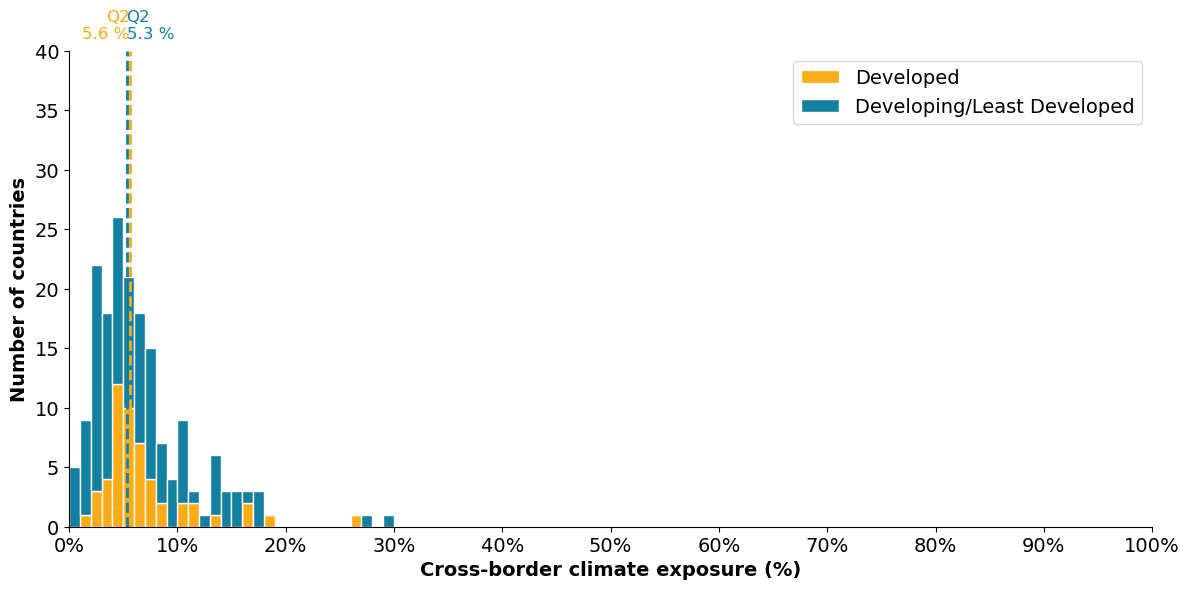

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_exports_leontief_CI

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
#bins = np.linspace(0, round(df['High Risk'].max(), 0) + 2, 30)
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']

developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk')
data_to_plot = [developed_row_counts, not_developed_row_counts]

# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)

plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='left', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='right', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.legend(fontsize=14)

plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig4a.png")

plt.show()

Vizualize it for consumption and exports

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_exports_leontief_CF

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
#bins = np.linspace(0, round(df['High Risk'].max(), 0) + 2, 30)
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']

developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk')
data_to_plot = [developed_row_counts, not_developed_row_counts]

# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)

plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='left', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='right', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.legend(fontsize=14)

plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig4a.png") # Intermediate Cons
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig4c.png") # Exports
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig4b.png") # Final Cons


plt.show()

NameError: name 'resulting_dataframe_country_exports_leontief_CF' is not defined

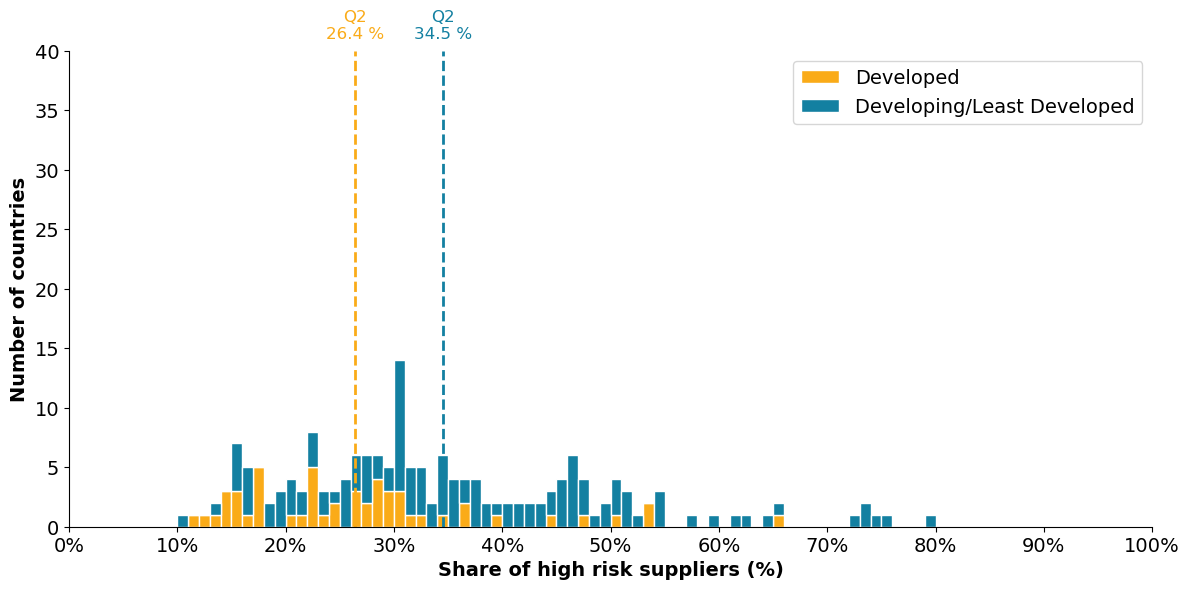

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_exports_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk (relative)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk (relative)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk (relative)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk (relative)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Share of high risk suppliers (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig4c.png")

plt.show()

Dependence to Foreign Countries

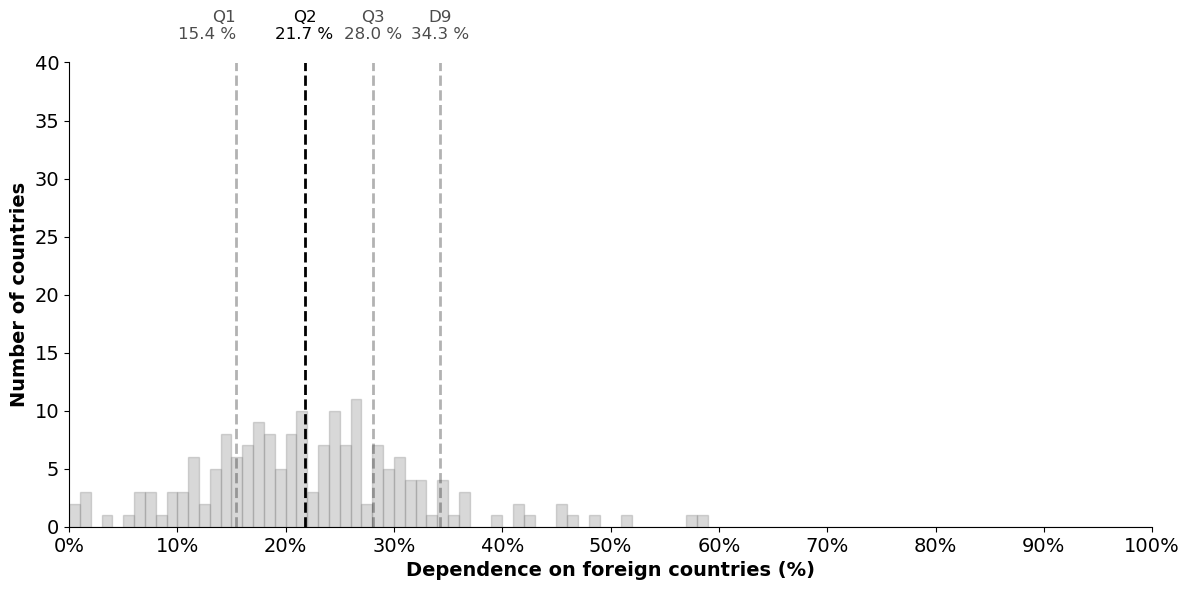

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    #bins = np.linspace(0, round(df['Foreign (%)'].max(), 0) + 2, 30)
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Foreign (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'Foreign (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Foreign (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Foreign (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = df['Foreign (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 42, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 42, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Dependence on foreign countries (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    #plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig2a.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

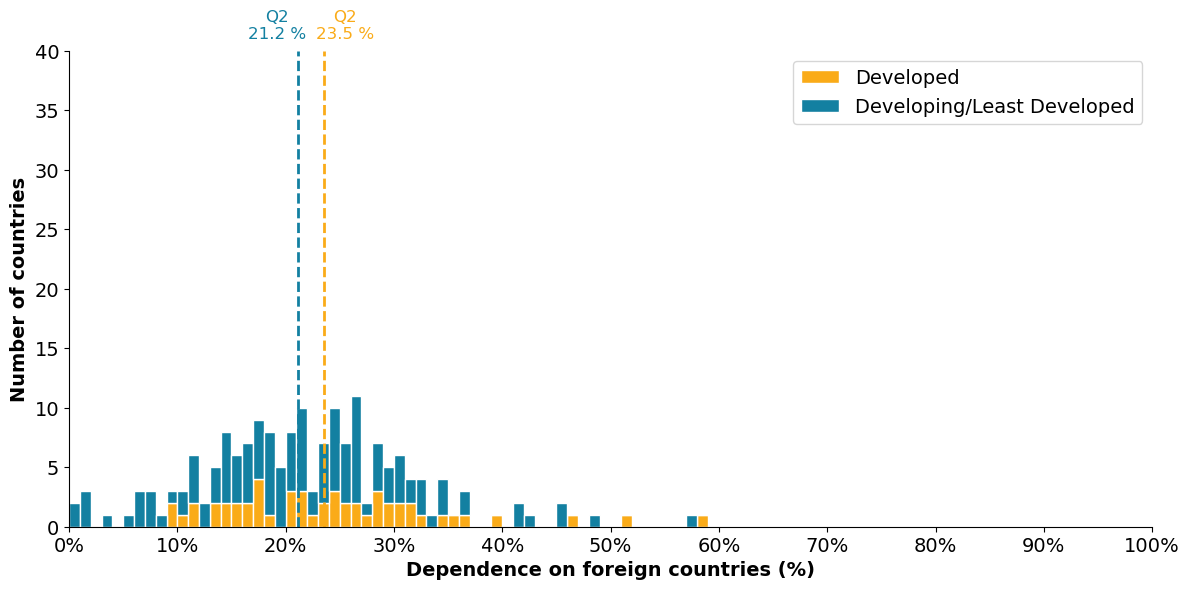

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'Foreign (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins,  'Foreign (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['Foreign (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['Foreign (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value-2, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value+2, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Dependence on foreign countries (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig4e.png")

plt.show()

In [19]:
np.median(resulting_dataframe_country_inputs_leontief['High Risk'])

5.836616849716054

##### Risky Suppliers / Country
----

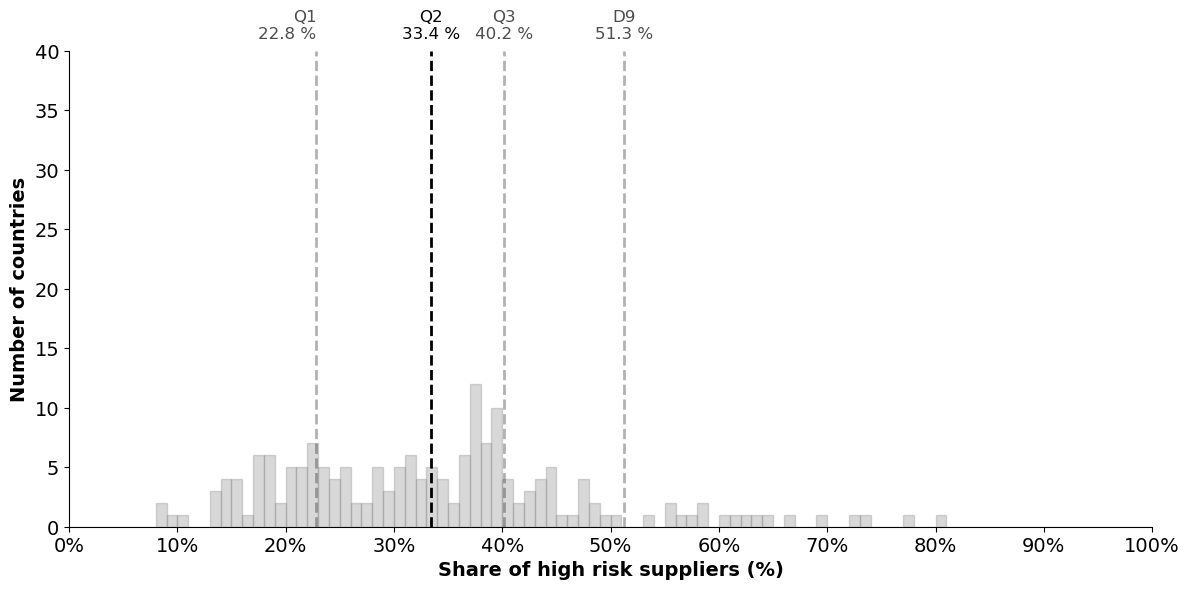

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'High Risk (relative)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'High Risk (relative)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'High Risk (relative)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'High Risk (relative)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = resulting_dataframe_country_inputs_leontief['High Risk (relative)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 41, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 41, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 41, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 41, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Share of high risk suppliers (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig3a.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

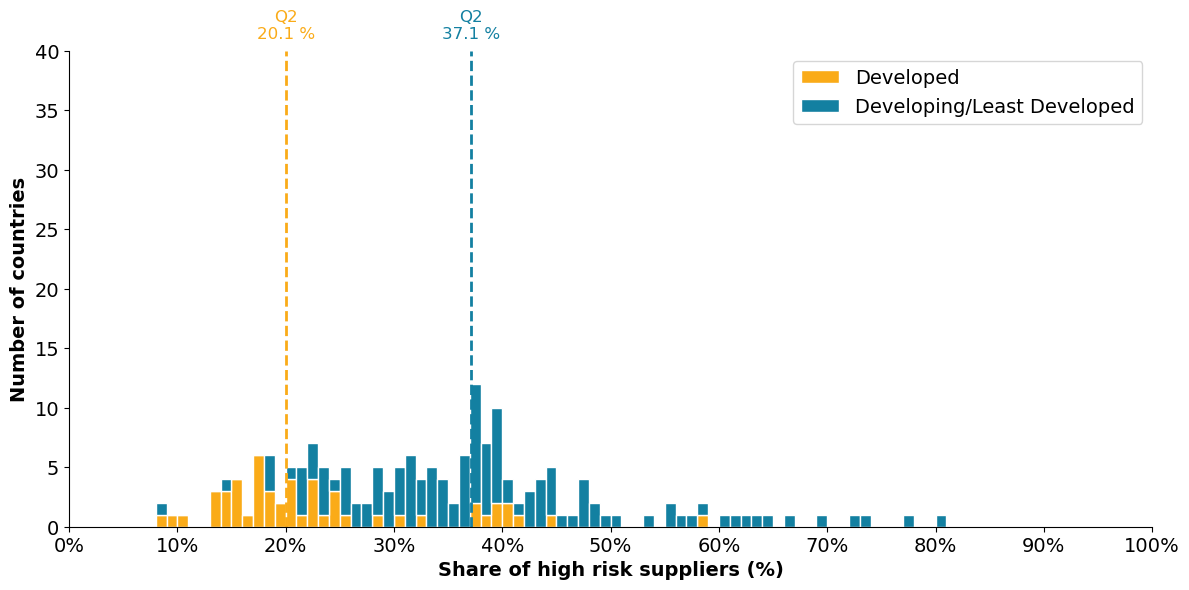

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk (relative)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk (relative)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk (relative)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk (relative)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Share of high risk suppliers (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\B\Fig4c.png")

plt.show()

##### Calculating aggregate exposure

(low/high risk // developing/developed)

In [9]:
import numpy as np
# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief
l = 'High Risk'
# Separate the data into two groups based on 'Development'
#developed_df = df[df['Development'] == 'Developed']
#not_dev_df = df[df['Development']!='Developed']
risky_df=df[df['Local Risk'] == 'High Risk']
not_risky_df=df[df['Local Risk'] == 'Low Risk']

#print('Dev =',np.median(developed_df[l]),'Not dev:',np.median(not_dev_df[l]))
print('Low Risk =',np.median(not_risky_df[l]),'High Risk =',np.median(risky_df[l]))


Low Risk = 4.777352401354822 High Risk = 6.5790825449593635


In [410]:
df = resulting_dataframe_country_inputs_leontief
median_high_risk = df[(df['Region'] != 'Europe & Central Asia') & (df['Development'] == 'Developed')]['High Risk (relative)'].median()
median_high_risk

28.889774600845342

In absolute quantity 

In [59]:
low_risk_list=VLR_list_MRIOT+LR_list_MRIOT
high_risk_list=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT

CI_country=mriot.Z.groupby('region').sum().T.groupby('region').sum().T
no_diag=CI_country
# Set the diagonal elements to zero
np.fill_diagonal(no_diag.values, 0)
CI = no_diag

# Create a new column to identify if the region is in the list or not
CI['Risk'] = CI.index.isin(high_risk_list)

# Group by this new column and sum all other columns
CI = CI.groupby('Risk').sum()
CI=CI.T
# Create a new column to identify if the region is in the list or not
CI['Risk'] = CI.index.isin(high_risk_list)

# Group by this new column and sum all other columns
CI = CI.groupby('Risk').sum()
CI=CI.T
CI
# Rename index and columns
CI.index = CI.index.map({False: 'Low Risk', True: 'High Risk'})
CI.columns = CI.columns.map({False: 'Low Risk', True: 'High Risk'})

CI

Risk,Low Risk,High Risk
Risk,,
Low Risk,6.608714e+09,2.825458e+09
High Risk,2.449865e+09,1.422449e+09


In [54]:
mriot.Z

region                                               AFG             \
sector                                       Agriculture    Fishing   
region sector                                                         
AFG    Agriculture                           98135.00000   25.30470   
       Fishing                                 132.40800  418.24000   
       Mining and Quarrying                   1603.91000   37.79110   
       Food & Beverages                      40408.80000  468.59600   
       Textiles and Wearing Apparel           1706.29000  219.67600   
...                                                  ...        ...   
ZWE    Public Administration                     2.32591    2.71441   
       Education, Health and Other Services      3.01483    3.20941   
       Private Households                        1.17719    1.37551   
       Others                                    3.30335    3.58883   
       Re-export & Re-import                     5.94325    6.83916   

region                                                            \
sector                                      Mining and Quarrying   
region sector                                                      
AFG    Agriculture                                     359.37200   
       Fishing                                           2.32455   
       Mining and Quarrying                          10299.00000   
       Food & Beverages                                 54.37240   
       Textiles and Wearing Apparel                    385.27000   
...                                                          ...   
ZWE    Public Administration                             3.56203   
       Education, Health and Other Services              4.24502   
       Private Households                                1.84375   
       Others                                            4.79122   
       Re-export & Re-import                             8.99569   

region                                                        \
sector                                      Food & Beverages   
region sector                                                  
AFG    Agriculture                              214505.00000   
       Fishing                                   28665.90000   
       Mining and Quarrying                        667.63800   
       Food & Beverages                         161090.00000   
       Textiles and Wearing Apparel               1929.72000   
...                                                      ...   
ZWE    Public Administration                         4.36533   
       Education, Health and Other Services          5.19153   
       Private Households                            2.25750   
       Others                                        5.92975   
       Re-export & Re-import                        11.27200   

region                                                                    \
sector                                      Textiles and Wearing Apparel   
region sector                                                              
AFG    Agriculture                                            2674.45000   
       Fishing                                                   4.19821   
       Mining and Quarrying                                     68.57620   
       Food & Beverages                                       1532.57000   
       Textiles and Wearing Apparel                          50932.00000   
...                                                                  ...   
ZWE    Public Administration                                     4.41346   
       Education, Health and Other Services                      5.24824   
       Private Households                                        2.27674   
       Others                                                    5.93691   
       Re-export & Re-import                                    11.27610   

region                                                      \
sector                      

##### Absolute Risk / Pop
-----

By population :

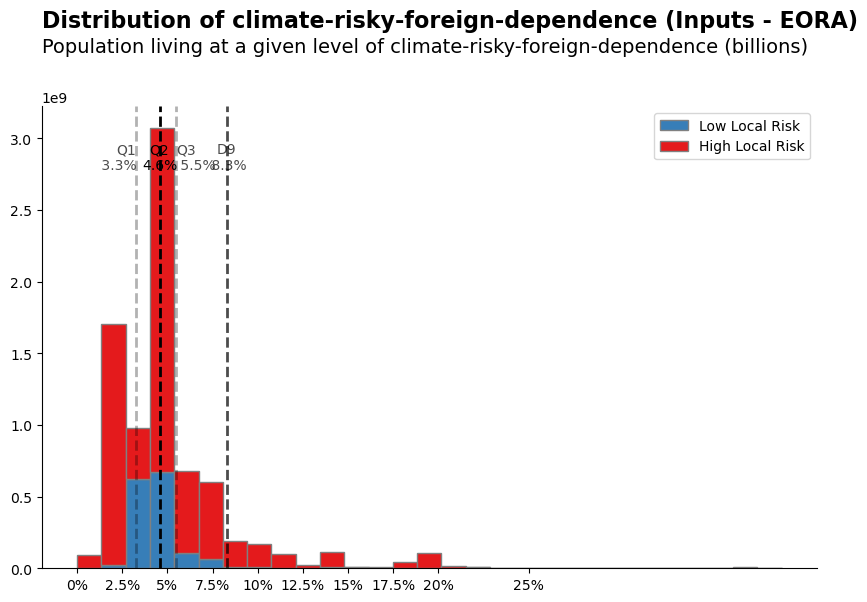

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def population_sum_in_bins(d, bins, column_name):
    bin_sums = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        bin_sum = bin_d['Population (2023)'].sum()
        bin_sums.append(bin_sum)
    return bin_sums

color_palette = sns.color_palette("Set1", 7)


def plot_population_distribution(df, graph_type='total'):
    """
    Plots the specified type of population distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    """
    # Define the number of bins and calculate the bin edges
    bins = np.linspace(0, round(df['High Risk'].max(),0)+2, 30)

    if graph_type == 'total':
        # Calculate population sums for the entire dataset
        total_population_sums = population_sum_in_bins(df, bins, 'High Risk')
        data_to_plot = total_population_sums
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'High Risk']
        low_risk_population_sums = population_sum_in_bins(low_risk_df, bins, 'High Risk')
        high_risk_population_sums = population_sum_in_bins(high_risk_df, bins, 'High Risk')
        data_to_plot = [low_risk_population_sums, high_risk_population_sums]
        color = [color_palette[1], color_palette[0]]  
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(10, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center',edgecolor='grey',alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center',edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center',edgecolor='grey')
        plt.legend()
    
    # Calculate population sums for the entire dataset
    total_population_sums = population_sum_in_bins(df, bins, 'High Risk')

    # Scale factor to avoid memory issues (adjust if necessary)
    scale_factor = 10000

    # Replicate 'High Risk' values according to scaled 'Population (2023)'
    weighted_risk_values = np.repeat(df['High Risk'], (df['Population (2023)'] / scale_factor).astype(int))

    # Calculate the weighted median, quartiles, and deciles
    weighted_median = np.median(weighted_risk_values)
    weighted_first_quartile = np.percentile(weighted_risk_values, 25)
    weighted_third_quartile = np.percentile(weighted_risk_values, 75)
    weighted_ninth_decile = np.percentile(weighted_risk_values, 90)
    
    # Draw lines for weighted median and quartiles
    plt.axvline(weighted_median, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(weighted_first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.7)

    # Find the maximum height of the bars for positioning the text
    max_height = max(max(data_to_plot)) if graph_type == 'risk_comparison' else max(data_to_plot)
    text_height = max_height * 1.15  # Place text slightly above the maximum bar height

    # Annotate the lines
    plt.text(weighted_median, text_height, f'Q2\n{weighted_median:.1f}%', horizontalalignment='center', color='black', verticalalignment='bottom')
    plt.text(weighted_first_quartile, text_height, f'Q1\n {weighted_first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_third_quartile, text_height, f'Q3\n {weighted_third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_ninth_decile, text_height, f'D9\n {weighted_ninth_decile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0,2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20, 25]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])

    # Titles
    plt.text(0, 1.21, "Distribution of climate-risky-foreign-dependence (Inputs - EORA)", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    plt.text(0, 1.15, "Population living at a given level of climate-risky-foreign-dependence (billions)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

    plt.show()

# Usage examples
#graph = "total" # for basic graph
graph = 'risk_comparison' # population divided by local risk

plot_population_distribution(df, graph_type=graph) 

##### Risky Suppliers / Pop
----

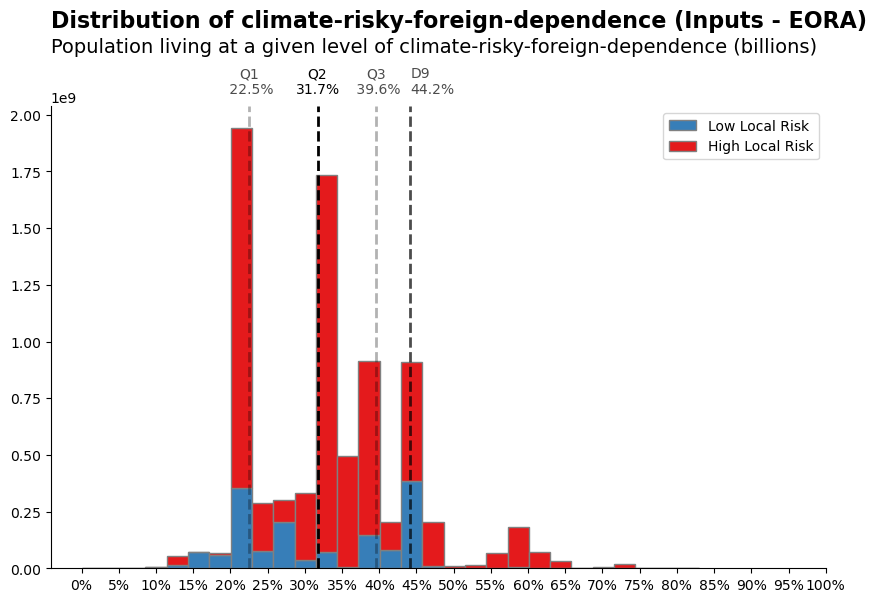

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def population_sum_in_bins(d, bins, column_name):
    bin_sums = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        bin_sum = bin_d['Population (2023)'].sum()
        bin_sums.append(bin_sum)
    return bin_sums

color_palette = sns.color_palette("Set1", 7)


def plot_population_distribution(df, graph_type='total'):
    """
    Plots the specified type of population distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    """
    # Define the number of bins and calculate the bin edges
    bins = np.linspace(0, round(df['High Risk (relative)'].max(),0)+2, 30)

    if graph_type == 'total':
        # Calculate population sums for the entire dataset
        total_population_sums = population_sum_in_bins(df, bins, 'High Risk (relative)')
        data_to_plot = total_population_sums
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'High Risk']
        low_risk_population_sums = population_sum_in_bins(low_risk_df, bins, 'High Risk (relative)')
        high_risk_population_sums = population_sum_in_bins(high_risk_df, bins, 'High Risk (relative)')
        data_to_plot = [low_risk_population_sums, high_risk_population_sums]
        color = [color_palette[1], color_palette[0]]  
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(10, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center',edgecolor='grey',alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center',edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center',edgecolor='grey')
        plt.legend()
    
    # Calculate population sums for the entire dataset
    total_population_sums = population_sum_in_bins(df, bins, 'High Risk (relative)')

    # Scale factor to avoid memory issues (adjust if necessary)
    scale_factor = 10000

    # Replicate 'High Risk (relative)' values according to scaled 'Population (2023)'
    weighted_risk_values = np.repeat(df['High Risk (relative)'], (df['Population (2023)'] / scale_factor).astype(int))

    # Calculate the weighted median, quartiles, and deciles
    weighted_median = np.median(weighted_risk_values)
    weighted_first_quartile = np.percentile(weighted_risk_values, 25)
    weighted_third_quartile = np.percentile(weighted_risk_values, 75)
    weighted_ninth_decile = np.percentile(weighted_risk_values, 90)
    
    # Draw lines for weighted median and quartiles
    plt.axvline(weighted_median, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(weighted_first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(weighted_ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.7)

    # Find the maximum height of the bars for positioning the text
    max_height = max(max(data_to_plot)) if graph_type == 'risk_comparison' else max(data_to_plot)
    text_height = max_height * 5.4  # Place text slightly above the maximum bar height

    # Annotate the lines
    plt.text(weighted_median, text_height, f'Q2\n{weighted_median:.1f}%', horizontalalignment='center', color='black', verticalalignment='bottom')
    plt.text(weighted_first_quartile, text_height, f'Q1\n {weighted_first_quartile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_third_quartile, text_height, f'Q3\n {weighted_third_quartile:.1f}%', horizontalalignment='center', color='black', alpha=0.7, verticalalignment='bottom')
    plt.text(weighted_ninth_decile, text_height, f'D9\n{weighted_ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7, verticalalignment='bottom')
    
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = list(range(0, 101, 5))
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])

    # Titles
    plt.text(0, 1.21, "Distribution of climate-risky-foreign-dependence (Inputs - EORA)", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    plt.text(0, 1.15, "Population living at a given level of climate-risky-foreign-dependence (billions)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

    plt.show()

# Usage examples
#graph = "total" # for basic graph
graph = 'risk_comparison' # population divided by local risk

plot_population_distribution(df, graph_type=graph) 

#### Correlation Risk & Climate-Foreign-Dependence

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\1096293787.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)'

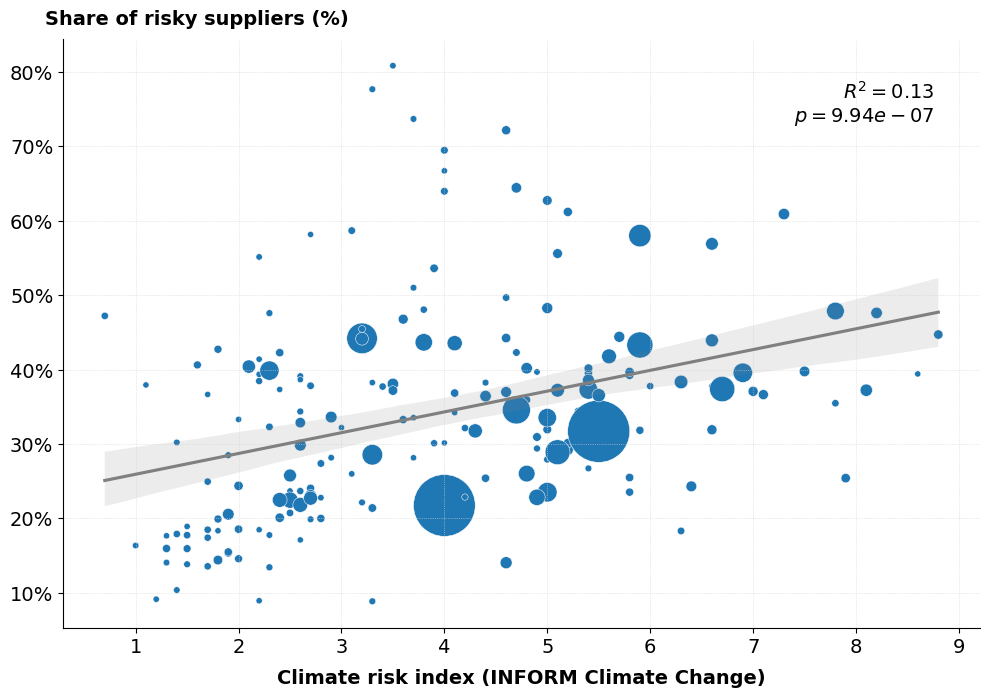

In [40]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig3a.png")
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Main text\Fig1c.png")

# Show the plot
#####
plt.show()

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


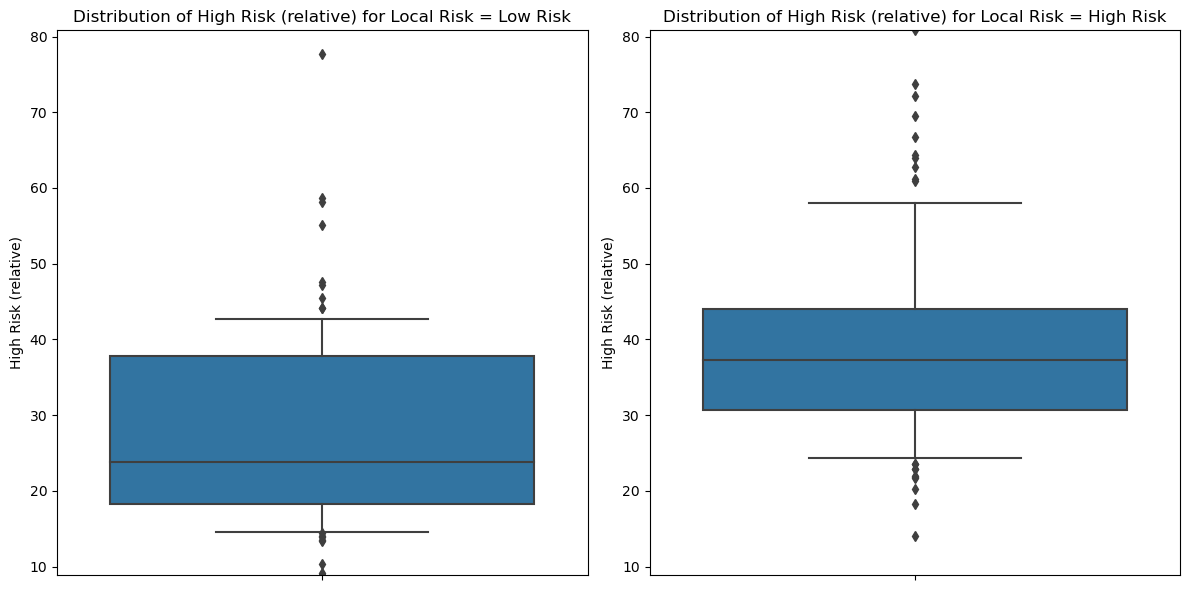

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming resulting_dataframe_country_cons_leontief is already defined
df = resulting_dataframe_country_inputs_leontief

# Separate the DataFrame into two based on 'Local Risk'
df_low_risk = df[df['Local Risk'] == 'Low Risk']
df_high_risk = df[df['Local Risk'] == 'High Risk']

# Determine the Y-axis limits based on the combined range of both subsets
y_min = min(df_low_risk['High Risk (relative)'].min(), df_high_risk['High Risk (relative)'].min())
y_max = max(df_low_risk['High Risk (relative)'].max(), df_high_risk['High Risk (relative)'].max())

# Plotting the boxplots
plt.figure(figsize=(12, 6))

# Boxplot for Low Risk
plt.subplot(1, 2, 1)
sns.boxplot(y='High Risk (relative)', data=df_low_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = Low Risk')
plt.ylim(y_min, y_max)

# Boxplot for High Risk
plt.subplot(1, 2, 2)
sns.boxplot(y='High Risk (relative)', data=df_high_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = High Risk')
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [ ]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name'], axis=1, inplace=True)

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

#notes['Country'] = notes['Country'].map(country_mapping)

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])


# Perform a left join based on columns 'A' and 'B'
merged_df = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
merged_df= merged_df.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Tables IO/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
merged_df = merged_df.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Tables IO/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
merged_df = merged_df.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

merged_df = merged_df.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
merged_df.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)
# Convert the column to numeric
merged_df['Population (2023)'] = pd.to_numeric(merged_df['Population (2023)'], errors='coerce').fillna(0)
# Drop rows where 'Population (2023)' is equal to 
merged_df = merged_df[merged_df['Population (2023)'] != 0]

merged_df['Log(Pop)']=np.log(merged_df['Population (2023)'])

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


# Create the scatter plot with a logarithmic scale for the y-axis
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(x='Log(Pop)', y='Foreign (%)', data=merged_df)
# Perform linear regression and calculate R²
slope, intercept, r_value, p_value, std_err = stats.linregress(merged_df['Log(Pop)'], merged_df['Foreign (%)'])
r_squared = r_value**2

plt.text(10, 10, f'R² = {r_squared:.4f}', fontsize=12, color='red')
# Add a regression line
sns.regplot(x='Log(Pop)', y='Foreign (%)', data=merged_df, scatter=False, color='red', line_kws={"color": "red"})

# Set labels and title
plt.xlabel('Population (2023)')
plt.ylabel('Foreign (%)')
plt.title('Foreign (%) vs. Population (2023) with Regression Line')

# Show the plot

#### XY Figure
-----

##### Plot
----

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

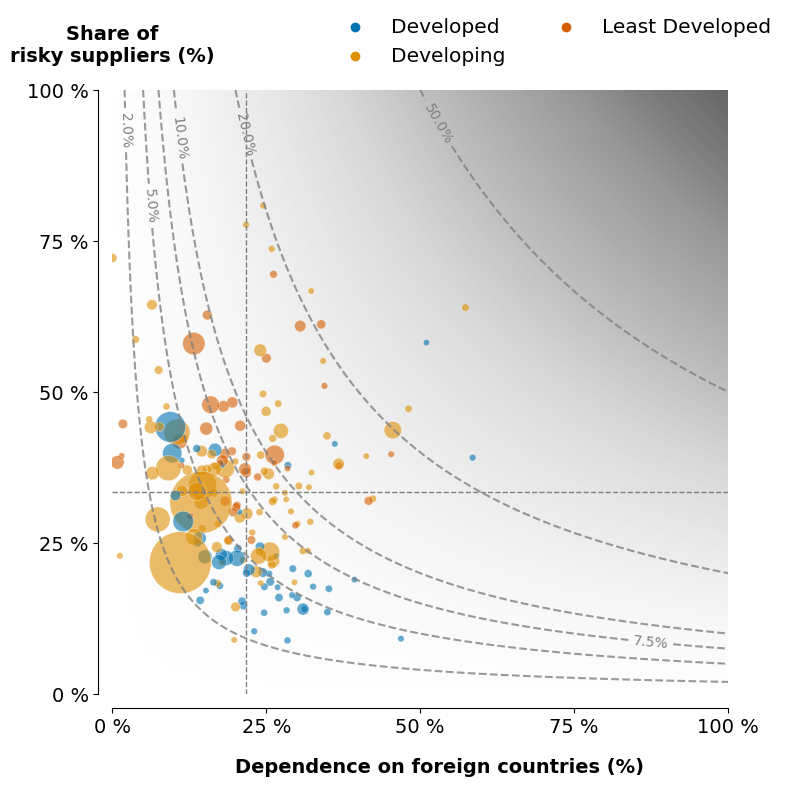

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator

result = resulting_dataframe_country_inputs_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))


# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 10, 256)
y = np.linspace(0, 10, 256)

z = np.outer(y,x)

plt.imshow(z, aspect='auto', extent=[0, 100, 0, 100], origin='lower', cmap='Greys',alpha=0.6)

plt.ylim(0, 100)
plt.xlim(0, 100)

# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 100, 256)
y = np.linspace(0, 100, 256)
X, Y = np.meshgrid(x, y)
Z = X * Y  # Adjust this function as needed to match the background gradient

# Create contour plot
contour = plt.contour(X, Y, Z, constants, colors='grey', linestyles='dashed', alpha=0.8)

# Label each contour line with its respective value divided by 1000
fmt = lambda x: f"{x/100:.1f}%"
clabels = plt.clabel(contour, fmt=fmt, inline=True, fontsize=10, colors='black')

# Adjust label colors to make them darker than contour lines
for label in clabels:
    label.set_color('grey')

    
constants = [200, 500, 750, 1000, 2000,5000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    #plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=0.3)
    # Adding text for the value of the constant
    #plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
palette = sns.color_palette(palette="colorblind", as_cmap=True)
# Colorblind-friendly palette
risk_palette = {'Developed': palette[0],  # Sky Blue
                'Developing': palette[1],
               "Least Developed":palette[3]}  # Coral

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=risk_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        bbox_to_anchor=(1.1,1.15),
        frameon=False,      # Suppress the legend box
        fontsize=14.5,
        ncol=2
    )

    
# Add letters to each quadrant
#plt.text(5, 5, 'A', fontsize=20, fontweight='bold')
#plt.text(13, 95, 'B', fontsize=20, fontweight='bold')
#plt.text(95, 14, 'C', fontsize=20, fontweight='bold')
#plt.text(95, 95, 'D', fontsize=20, fontweight='bold')

median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(20, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

locator = MaxNLocator(nbins=4)  # Set the number of bins to control the tick frequency
scatter.xaxis.set_major_locator(locator)
scatter.yaxis.set_major_locator(locator)
# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

#plt.grid(False, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1a.png")
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Main Text\Fig1a.png")

plt.show()

In [149]:
resulting_dataframe_country_inputs_leontief

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,11.528853,23.229252,14.411164,6.034116,1.882372,0,58.516092,41.483908,34.758105,22.327652,39.112474
1,Hong Kong,High Risk,4.0,0.1,East Asia & Pacific,High income,7350409.0,Developing,4.051864,16.618468,34.818931,1.788555,0.063759,0,57.354527,42.645473,20.670332,36.671245,63.952279
2,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,6.357098,14.808846,20.675106,6.036783,2.696988,0,51.006468,48.993532,21.165943,29.408877,58.149247
3,Singapore,Low Risk,0.7,0.1,East Asia & Pacific,High income,5673743.0,Developing,3.550303,21.839808,19.836127,2.764829,0.107306,0,48.111373,51.888627,25.390111,22.708262,47.212121
4,Luxembourg,Low Risk,1.2,0.1,Europe & Central Asia,High income,657569.0,Developed,4.588006,37.986040,3.289430,0.874622,0.123913,0,46.874044,53.125956,42.574046,4.287965,9.150195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.305173,0.629878,0.544019,0.162113,0.049796,0,1.714303,98.285697,0.935051,0.755928,44.703583
183,South Sudan,High Risk,8.6,0.1,NaN,NaN,0.0,Least Developed,0.302446,0.602943,0.383765,0.160836,0.044380,0,1.527666,98.472334,0.905389,0.588981,39.413345
184,Guyana,High Risk,4.2,-0.1,Latin America & Caribbean,High income,813834.0,Developing,0.063690,0.880956,0.222943,0.055163,0.002026,0,1.225018,98.774982,0.944646,0.280132,22.872093
185,Myanmar,High Risk,6.3,0.1,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.150082,0.351130,0.219491,0.079762,0.012288,0,0.824747,99.175253,0.501212,0.311540,38.331540


In [52]:
df = resulting_dataframe_country_inputs_leontief

# Importing the pandas library
import pandas as pd

# Assuming you have the DataFrame `df` after dropping columns
# Example setup: removing some columns from df
columns_to_drop = ["VLR (%)", "LR (%)", "MR (%)", "HR (%)", 
    "VHR (%)", "ROW (%)"
]

median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

# Exporting to an Excel file
df.to_excel(r"C:\Users\delah\OneDrive\Bureau\Figures\SUpp Mat\C\fig1a.xlsx", index=False)

In [24]:
resulting_dataframe_country_inputs_leontief

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,58.516092,41.483908,34.758105,22.327652,39.112474
1,Hong Kong,High Risk,4.0,0.1,East Asia & Pacific,High income,7350409.0,Developing,57.354527,42.645473,20.670332,36.671245,63.952279
2,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,51.006468,48.993532,21.165943,29.408877,58.149247
3,Singapore,Low Risk,0.7,0.1,East Asia & Pacific,High income,5673743.0,Developing,48.111373,51.888627,25.390111,22.708262,47.212121
4,Luxembourg,Low Risk,1.2,0.1,Europe & Central Asia,High income,657569.0,Developed,46.874044,53.125956,42.574046,4.287965,9.150195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,1.714303,98.285697,0.935051,0.755928,44.703583
183,South Sudan,High Risk,8.6,0.1,NaN,NaN,0.0,Least Developed,1.527666,98.472334,0.905389,0.588981,39.413345
184,Guyana,High Risk,4.2,-0.1,Latin America & Caribbean,High income,813834.0,Developing,1.225018,98.774982,0.944646,0.280132,22.872093
185,Myanmar,High Risk,6.3,0.1,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.824747,99.175253,0.501212,0.311540,38.331540


Moyenne sur les pays développés 

In [285]:
result = resulting_dataframe_country_inputs_leontief
print('Moyenne du high risk sur les pays développés : ',result[result['Development'] == 'Developed']['High Risk'].median().round(2),'%')

AttributeError: 'float' object has no attribute 'round'

In [305]:
result[result['Development'] == 'Developed']['High Risk'].quantile(0.8)

5.969230147504515

In [307]:
first_quartile = result['High Risk'].quantile(0.5)
first_quartile

5.825964202371849

##### Analyzing Quadrants
-----

How many countries are in each quarter ?

In [33]:
df = resulting_dataframe_country_inputs_leontief
# Calculate medians
median_foreign = df['Foreign (%)'].median()
median_high_risk_relative = df['High Risk (relative)'].median()

# Create masks for each category
foreign_climate = df[(df['Foreign (%)'] > median_foreign) & (df['High Risk (relative)'] > median_high_risk_relative)]
noforeign_climate = df[(df['Foreign (%)'] < median_foreign) & (df['High Risk (relative)'] > median_high_risk_relative)]
foreign_noclimate = df[(df['Foreign (%)'] > median_foreign) & (df['High Risk (relative)'] < median_high_risk_relative)]
noforeign_noclimate = df[(df['Foreign (%)'] < median_foreign) & (df['High Risk (relative)'] < median_high_risk_relative)]

total_records = len(df)

# Calculate the percentage of each category
percentage_foreign_climate = (len(foreign_climate) / total_records) * 100
percentage_noforeign_climate = (len(noforeign_climate) / total_records) * 100
percentage_foreign_noclimate = (len(foreign_noclimate) / total_records) * 100
percentage_noforeign_noclimate = (len(noforeign_noclimate) / total_records) * 100

# Print the percentages
print(f"Foreign oriented + high-risk suppliers: {round(percentage_foreign_climate,1)}%")
print(f"Foreign oriented + low-risk suppliers: {round(percentage_foreign_noclimate,1)}%")
print(f"Local oriented + high-risk suppliers: {round(percentage_noforeign_climate,1)}%")
print(f"Local oriented + low-risk suppliers: {round(percentage_noforeign_noclimate,1)}%")

Foreign oriented + high-risk suppliers: 22.2%
Foreign oriented + low-risk suppliers: 27.8%
Local oriented + high-risk suppliers: 27.8%
Local oriented + low-risk suppliers: 22.2%


Results on a graph : 

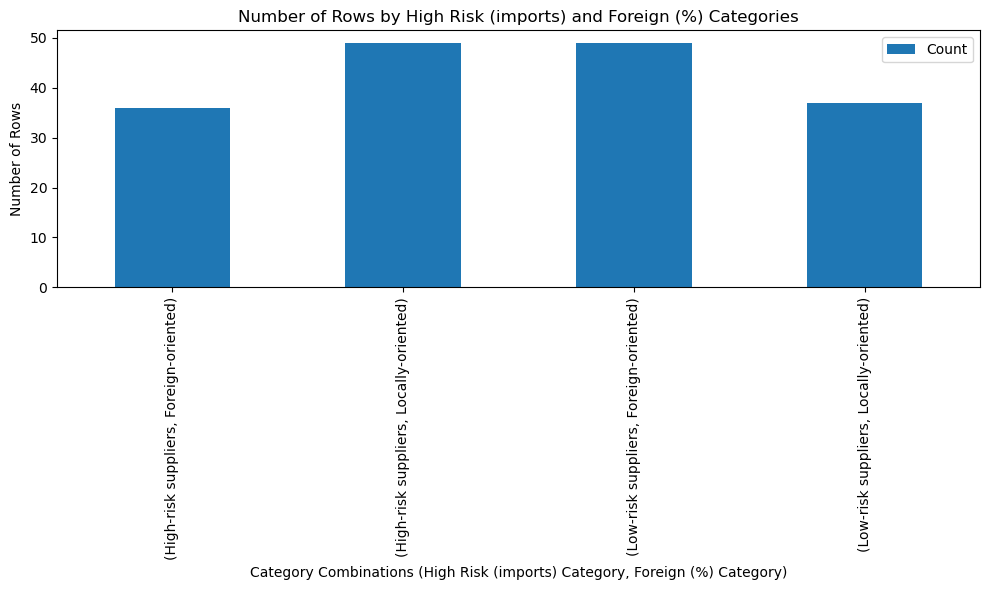

In [140]:
import pandas as pd
import matplotlib.pyplot as plt

df = resulting_dataframe_country_inputs_leontief
# Calculate medians
median_foreign = df['Foreign (%)'].median()
median_high_risk_relative = df['High Risk (relative)'].median()

# Create masks for each category
foreign_climate = df[(df['Foreign (%)'] > median_foreign) & (df['High Risk (relative)'] > median_high_risk_relative)]
noforeign_climate = df[(df['Foreign (%)'] < median_foreign) & (df['High Risk (relative)'] > median_high_risk_relative)]
foreign_noclimate = df[(df['Foreign (%)'] > median_foreign) & (df['High Risk (relative)'] < median_high_risk_relative)]
noforeign_noclimate = df[(df['Foreign (%)'] < median_foreign) & (df['High Risk (relative)'] < median_high_risk_relative)]

total_records = len(df)

# Calculate the percentage of each category
percentage_foreign_climate = (len(foreign_climate) / total_records) * 100
percentage_noforeign_climate = (len(noforeign_climate) / total_records) * 100
percentage_foreign_noclimate = (len(foreign_noclimate) / total_records) * 100
percentage_noforeign_noclimate = (len(noforeign_noclimate) / total_records) * 100

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')


# Group the data by 'High Risk (relative) Category' and 'Foreign (%) Category' and count the rows
count_combinations = df.groupby(['High Risk (relative) Category', 'Foreign (%) Category']).size().reset_index(name='Count')

# Set the combination of categories as the index for plotting
count_combinations.set_index(['High Risk (relative) Category', 'Foreign (%) Category'], inplace=True)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))
count_combinations.plot(kind='bar', y='Count', ax=ax)

# Set labels and title
ax.set_xlabel('Category Combinations (High Risk (relative) Category, Foreign (%) Category)')
ax.set_ylabel('Number of Rows')
ax.set_title('Number of Rows by High Risk (relative) and Foreign (%) Categories')

# Show the plot
plt.tight_layout()
plt.show()

Population in each category :

In [151]:
df = resulting_dataframe_country_inputs_leontief
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming you already have the DataFrame with the added categories

# Group the data by 'High Risk (relative) Category' and 'Foreign (%) Category' and sum the population
population_sum = df.groupby(['High Risk (relative) Category', 'Foreign (%) Category'])['Population (2023)'].sum().reset_index()

# Set the combination of categories as the index for plotting
population_sum.set_index(['High Risk (relative) Category', 'Foreign (%) Category'], inplace=True)

total = population_sum.sum().iloc[0]

# Calculate the percentage of each category
percentage_foreign_climate = (population_sum.loc[('High-risk suppliers', 'Foreign-oriented'), 'Population (2023)'] / total) * 100
percentage_noforeign_climate = (population_sum.loc[('High-risk suppliers', 'Locally-oriented'), 'Population (2023)']/ total) * 100
percentage_foreign_noclimate = (population_sum.loc[('Low-risk suppliers', 'Foreign-oriented'), 'Population (2023)'] / total) * 100
percentage_noforeign_noclimate = (population_sum.loc[('High-risk suppliers', 'Locally-oriented'), 'Population (2023)']/ total) * 100

# Print the percentages
print(f"Foreign oriented + high-risk suppliers: {round(percentage_foreign_climate,1)}%")
print(f"Foreign oriented + low-risk suppliers: {round(percentage_foreign_noclimate,1)}%")
print(f"Local oriented + high-risk suppliers: {round(percentage_noforeign_climate,1)}%")
print(f"Local oriented + low-risk suppliers: {round(percentage_noforeign_noclimate,1)}%")

Foreign oriented + high-risk suppliers: 7.9%
Foreign oriented + low-risk suppliers: 8.1%
Local oriented + high-risk suppliers: 33.6%
Local oriented + low-risk suppliers: 33.6%


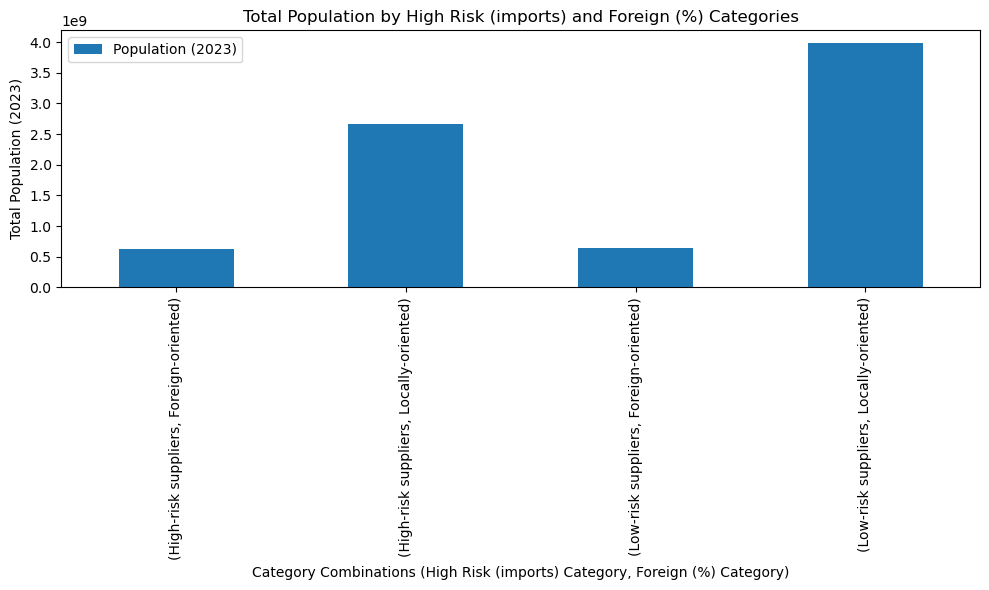

In [141]:
df = resulting_dataframe_country_inputs_leontief
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming you already have the DataFrame with the added categories

# Group the data by 'High Risk (relative) Category' and 'Foreign (%) Category' and sum the population
population_sum = df.groupby(['High Risk (relative) Category', 'Foreign (%) Category'])['Population (2023)'].sum().reset_index()

# Set the combination of categories as the index for plotting
population_sum.set_index(['High Risk (relative) Category', 'Foreign (%) Category'], inplace=True)

# Create a bar plot
fig, ax = plt.subplots(figsize=(10, 6))
population_sum.plot(kind='bar', y='Population (2023)', ax=ax)


# Set labels and title
ax.set_xlabel('Category Combinations (High Risk (relative) Category, Foreign (%) Category)')
ax.set_ylabel('Total Population (2023)')
ax.set_title('Total Population by High Risk (relative) and Foreign (%) Categories')

# Show the plot
plt.tight_layout()
plt.show()

Séparer risky et non risky dans le quadrant 4

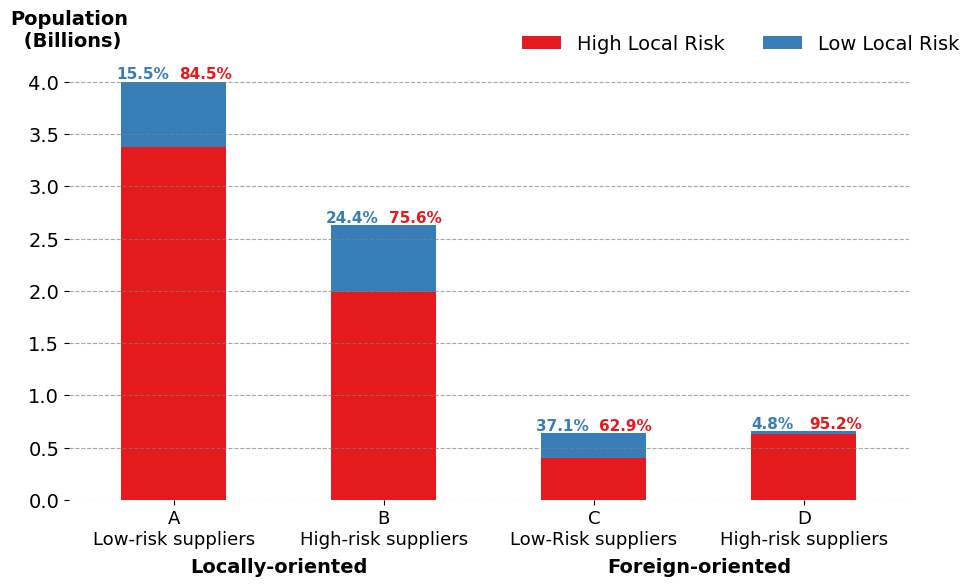

In [18]:
import seaborn as sns

df = resulting_dataframe_country_inputs_leontief
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.3e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['A\nLow-risk suppliers', 'B\nHigh-risk suppliers', 'C\nLow-Risk suppliers', 'D\nHigh-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.13, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Main text\Fig1b.png")
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig2a.png")

plt.show()

In [70]:
a  = df_sorted[(df_sorted['High Risk (relative) Category'] == 'High-risk suppliers') & (df_sorted['Foreign (%) Category'] == 'Foreign-oriented')& (df_sorted['Local Risk'] == 'Low Risk')]
b  = df_sorted[(df_sorted['High Risk (relative) Category'] == 'High-risk suppliers') & (df_sorted['Foreign (%) Category'] == 'Foreign-oriented')& (df_sorted['Local Risk'] == 'High Risk')]
a_sum=a['Population (2023)'].sum()
b_sum = b['Population (2023)'].sum()
summ=a_sum+b_sum
a_sum/summ*100
a.sort_values(by='Population (2023)')

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),...,HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative),High Risk (relative) Category,Foreign (%) Category
2,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,6.357098,14.808846,...,6.036783,2.696988,0,51.006468,48.993532,21.165943,29.408877,58.149247,High-risk suppliers,Foreign-oriented
22,Seychelles,Low Risk,1.7,-0.1,Sub-Saharan Africa,High income,100649.0,Developing,6.823806,13.553100,...,2.724185,0.361479,0,32.366510,67.633490,20.376906,11.793277,36.659030,High-risk suppliers,Foreign-oriented
42,Sao Tome and Principe,Low Risk,2.4,0.5,Sub-Saharan Africa,Lower middle income,231856.0,Least Developed,6.579768,10.989595,...,2.561650,0.814015,0,28.465266,71.534734,17.569363,10.463638,37.326142,High-risk suppliers,Foreign-oriented
9,Maldives,Low Risk,2.2,0.1,South Asia,Upper middle income,521021.0,Developing,13.339116,11.611331,...,5.311930,0.240405,0,41.248466,58.751534,24.950447,16.196835,39.363074,High-risk suppliers,Foreign-oriented
13,Montenegro,Low Risk,2.2,0.0,Europe & Central Asia,Upper middle income,615737.0,Developed,6.629446,14.259152,...,3.686715,1.297287,0,36.138652,63.861348,20.888599,14.754628,41.395320,High-risk suppliers,Foreign-oriented
56,Bhutan,Low Risk,3.3,0.1,South Asia,Lower middle income,787424.0,Least Developed,5.301864,10.741502,...,2.567668,0.664438,0,26.292738,73.707262,16.043367,9.936237,38.246300,High-risk suppliers,Foreign-oriented
18,Mauritius,Low Risk,2.2,0.1,Sub-Saharan Africa,Upper middle income,1263939.0,Developing,4.170631,11.165483,...,6.324941,0.292249,0,34.242027,65.757973,15.336114,18.840674,55.127106,High-risk suppliers,Foreign-oriented
0,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,11.528853,23.229252,...,6.034116,1.882372,0,58.516092,41.483908,34.758105,22.327652,39.112474,High-risk suppliers,Foreign-oriented
53,Mongolia,Low Risk,2.6,0.2,East Asia & Pacific,Lower middle income,3447157.0,Developing,4.367686,13.073812,...,0.673681,0.109781,0,26.618848,73.381152,17.441499,9.132638,34.366640,High-risk suppliers,Foreign-oriented
3,Singapore,Low Risk,0.7,0.1,East Asia & Pacific,High income,5673743.0,Developing,3.550303,21.839808,...,2.764829,0.107306,0,48.111373,51.888627,25.390111,22.708262,47.212121,High-risk suppliers,Foreign-oriented


In [76]:
df_sorted[df_sorted['Country']=='Switzerland']

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),...,HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative),High Risk (relative) Category,Foreign (%) Category
34,Switzerland,Low Risk,1.5,0.0,Europe & Central Asia,High income,8821953.0,Developed,4.270156,20.930269,...,0.939215,0.084375,0,30.015663,69.984337,25.200425,4.780717,15.945748,Low-risk suppliers,Foreign-oriented


In [81]:
population_by_risk.to_excel(r"C:\Users\delah\OneDrive\Bureau\Figures\Main text\fig1b.xlsx", index=False)
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.381197e+09  621438809.0
                     High-risk suppliers            1.985680e+09  640302367.0
Foreign-oriented     Low-risk suppliers             4.014812e+08  236994578.0
                     High-risk suppliers            6.260549e+08   31356608.0

In [97]:
# Export the DataFrame to an Excel file
output_path = "C:/Users/delah/OneDrive/Bureau/Figures/Main text/fig1b.xlsx"
population_by_risk.to_excel(output_path)
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.381197e+09  621438809.0
                     High-risk suppliers            1.985680e+09  640302367.0
Foreign-oriented     Low-risk suppliers             4.014812e+08  236994578.0
                     High-risk suppliers            6.260549e+08   31356608.0

## Consumption
----

### Consumption (Direct)
---

In [247]:
import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

final_production_by_destination = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = final_production_by_destination.groupby(level='region', axis=1).sum()

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Pour chaque pays, quelle pondération de la consommation finale ?
####

values = {'VLR (%)': [0] * country_list.size}
cConsoFin_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cConsoFin_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cConsoFin_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cConsoFin_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cConsoFin_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cConsoFin_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for c in country_list:
    cConsoFin = final_production_by_destination[c]
    cConsoFin_tot = final_production_by_destination[c].sum()
    country_list_except = [x for x in country_list if x != c]
    for cc in country_list_except:
        for s in sector_list:
            if cc=='ROW':
                cConsoFin_ROW.loc[c] = cConsoFin_ROW.loc[c]+cConsoFin.loc[cc,s]
            if cc in VLR_list_MRIOT:
                cConsoFin_VLR.loc[c] = cConsoFin_VLR.loc[c]+cConsoFin.loc[cc,s]
            if cc in LR_list_MRIOT:
                cConsoFin_LR.loc[c] = cConsoFin_LR.loc[c]+cConsoFin.loc[cc,s]
            if cc in MR_list_MRIOT:
                cConsoFin_MR.loc[c] = cConsoFin_MR.loc[c]+cConsoFin.loc[cc,s]
            if cc in HR_list_MRIOT:
                cConsoFin_HR.loc[c] = cConsoFin_HR.loc[c]+cConsoFin.loc[cc,s]
            if cc in VHR_list_MRIOT:
                cConsoFin_VHR.loc[c] = cConsoFin_VHR.loc[c]+cConsoFin.loc[cc,s]
    cConsoFin_Foreign.loc[c] = cConsoFin_VLR.loc[c].iloc[0] + cConsoFin_LR.loc[c].iloc[0] + cConsoFin_MR.loc[c].iloc[0] + cConsoFin_HR.loc[c].iloc[0] + cConsoFin_VHR.loc[c].iloc[0] + cConsoFin_ROW.loc[c].iloc[0]
    cConsoFin_Local.loc[c] = cConsoFin_tot - cConsoFin_Foreign.loc[c].iloc[0]
    
    #Ratios
    cConsoFin_VLR.loc[c]=cConsoFin_VLR.loc[c]/cConsoFin_tot*100
    cConsoFin_LR.loc[c]=cConsoFin_LR.loc[c]/cConsoFin_tot*100
    cConsoFin_MR.loc[c]=cConsoFin_MR.loc[c]/cConsoFin_tot*100
    cConsoFin_HR.loc[c]=cConsoFin_HR.loc[c]/cConsoFin_tot*100
    cConsoFin_VHR.loc[c]=cConsoFin_VHR.loc[c]/cConsoFin_tot*100
    cConsoFin_ROW.loc[c]=cConsoFin_ROW.loc[c]/cConsoFin_tot*100
    cConsoFin_Local.loc[c]=cConsoFin_Local.loc[c]/cConsoFin_tot*100
    cConsoFin_Foreign.loc[c]=cConsoFin_Foreign.loc[c]/cConsoFin_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_VLR, cConsoFin_LR, cConsoFin_MR, cConsoFin_HR, cConsoFin_VHR,cConsoFin_ROW, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_direct = pd.concat(dataframes_to_concat, axis=1)

resulting_dataframe_country_cons_direct = resulting_dataframe_country_cons_direct.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_direct.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_cons_direct = result

C:\Users\delah\AppData\Local\Temp\ipykernel_15168\561936681.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = final_production_by_destination.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\561936681.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '76.23999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_LR.loc[c] = cConsoFin_LR.loc[c]+cConsoFin.loc[cc,s]
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\561936681.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '29.219009' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_MR.loc[c] = cConsoFin_MR.loc[c]+cConsoFin.loc[cc,s]
C:\Users\delah\AppData\Loc

#### Correlation Risk & Climate-Foreign-Dependence

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_25236\2503853084.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)'

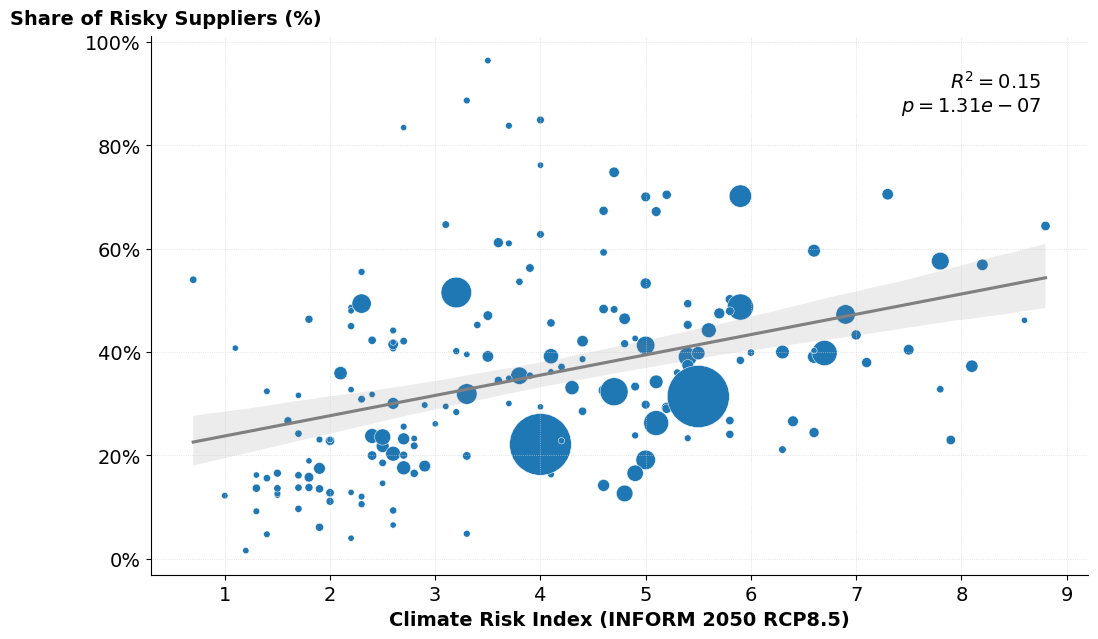

In [68]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_direct

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate Risk Index (INFORM 2050 RCP8.5)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.15, 1.05, 'Share of Risky Suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig2c.png")

# Show the plot
#####
plt.show()

#### XY Figure

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

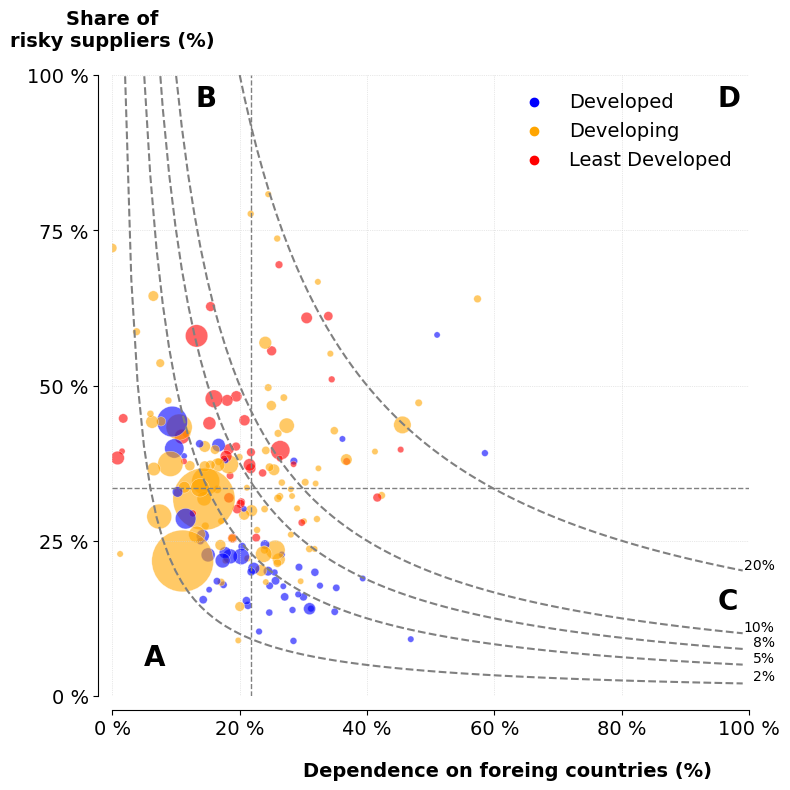

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_inputs_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        frameon=False,      # Suppress the legend box
        fontsize=14
    )
    

    
median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreing countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()

plt.show()

##### Analyzing Quadrants


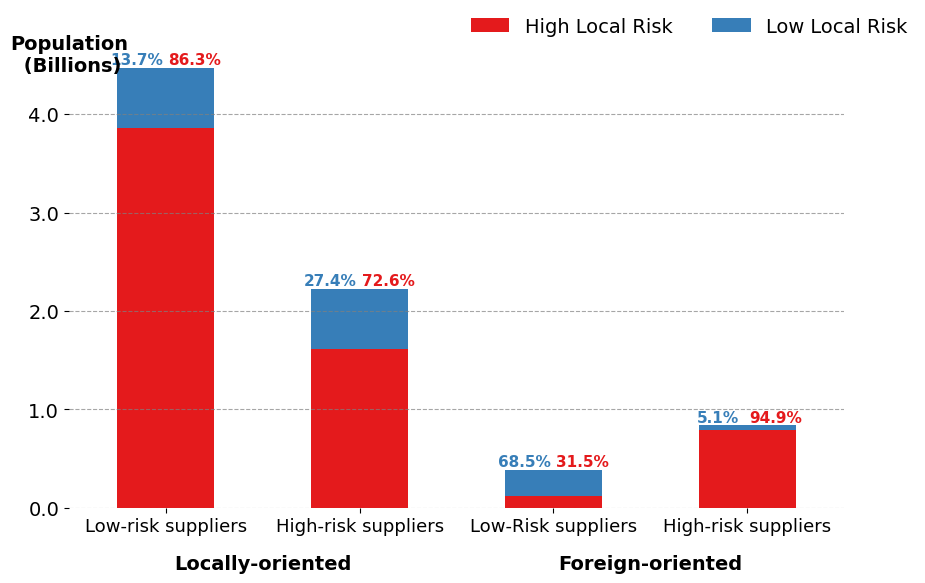

In [71]:
df = resulting_dataframe_country_cons_direct
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.4e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

# Show the plot
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig1b.png")

plt.show()

### Consumption (Leontief)
----

#### Code

In [20]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

final_production_by_destination = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = final_production_by_destination.groupby(level='region', axis=1).sum()

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######

values = {'VLR (%)': [0] * leontieff.index.size}
risk_cs_VLR = pd.DataFrame(values, index=leontieff.index)

values = {'LR (%)': [0] * leontieff.index.size}
risk_cs_LR = pd.DataFrame(values, index=leontieff.index)

values = {'MR (%)': [0] * leontieff.index.size}
risk_cs_MR = pd.DataFrame(values, index=leontieff.index)

values = {'HR (%)': [0] * leontieff.index.size}
risk_cs_HR = pd.DataFrame(values, index=leontieff.index)

values = {'VHR (%)': [0] * leontieff.index.size}
risk_cs_VHR = pd.DataFrame(values, index=leontieff.index)

values = {'ROW (%)': [0] * leontieff.index.size}
risk_cs_ROW = pd.DataFrame(values, index=leontieff.index)

# Créations d'indicateurs de risque de la production pour chaque couple (c,s)
######

for c in country_list:
    for s in sector_list:
        leontieff_cs = leontieff[c,s]
        final_production_cs = final_production[c,s]
        leontieff_cs_foreign = leontieff_cs[leontieff_cs.index.get_level_values('region') != c]
        leontieff_cs_foreign_VLR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VLR_list_MRIOT)]
        leontieff_cs_foreign_LR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(LR_list_MRIOT)]
        leontieff_cs_foreign_MR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(MR_list_MRIOT)]
        leontieff_cs_foreign_HR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(HR_list_MRIOT)]
        leontieff_cs_foreign_VHR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VHR_list_MRIOT)]
        leontieff_cs_foreign_ROW = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(['ROW'])]
        leontieff_cs_local = leontieff_cs[leontieff_cs.index.get_level_values('region').isin([c])]

        intrants_cs = (leontieff_cs*final_production_cs).sum()
        intrants_cs_local = (leontieff_cs_local*final_production_cs).sum()
        intrants_cs_foreign = (leontieff_cs_foreign*final_production_cs).sum()
        intrants_cs_foreign_VLR = (leontieff_cs_foreign_VLR*final_production_cs).sum()
        intrants_cs_foreign_LR = (leontieff_cs_foreign_LR*final_production_cs).sum()
        intrants_cs_foreign_MR = (leontieff_cs_foreign_MR*final_production_cs).sum()
        intrants_cs_foreign_HR = (leontieff_cs_foreign_HR*final_production_cs).sum()
        intrants_cs_foreign_VHR = (leontieff_cs_foreign_VHR*final_production_cs).sum()
        intrants_cs_foreign_ROW = (leontieff_cs_foreign_ROW*final_production_cs).sum()

        risk_cs_VLR.loc[c,s] = intrants_cs_foreign_VLR
        risk_cs_LR.loc[c,s] = intrants_cs_foreign_LR
        risk_cs_MR.loc[c,s] = intrants_cs_foreign_MR
        risk_cs_HR.loc[c,s] = intrants_cs_foreign_HR 
        risk_cs_VHR.loc[c,s] = intrants_cs_foreign_VHR
        risk_cs_ROW.loc[c,s] = intrants_cs_foreign_ROW 
        
        if c=='ROW':
             risk_cs_ROW.loc[c,s]= risk_cs_ROW.loc[c,s]+final_production_cs+intrants_cs_local
        if c in VLR_list_MRIOT:
             risk_cs_VLR.loc[c,s]= risk_cs_VLR.loc[c,s]+final_production_cs+intrants_cs_local
        if c in LR_list_MRIOT:
             risk_cs_LR.loc[c,s]= risk_cs_LR.loc[c,s]+final_production_cs+intrants_cs_local
        if c in MR_list_MRIOT:
             risk_cs_MR.loc[c,s]= risk_cs_MR.loc[c,s]+final_production_cs+intrants_cs_local
        if c in HR_list_MRIOT:
             risk_cs_HR.loc[c,s]= risk_cs_HR.loc[c,s]+final_production_cs+intrants_cs_local
        if c in VHR_list_MRIOT:
             risk_cs_VHR.loc[c,s]= risk_cs_VHR.loc[c,s]+final_production_cs+intrants_cs_local

        risk_cs_VLR.loc[c,s] = risk_cs_VLR.loc[c,s]/ (intrants_cs+final_production_cs)*100
        risk_cs_LR.loc[c,s] = risk_cs_LR.loc[c,s] / (intrants_cs+final_production_cs)*100
        risk_cs_MR.loc[c,s] = risk_cs_MR.loc[c,s] / (intrants_cs+final_production_cs)*100
        risk_cs_HR.loc[c,s] = risk_cs_HR.loc[c,s] / (intrants_cs+final_production_cs)*100
        risk_cs_VHR.loc[c,s] = risk_cs_VHR.loc[c,s] / (intrants_cs+final_production_cs)*100
        risk_cs_ROW.loc[c,s] = risk_cs_ROW.loc[c,s] / (intrants_cs+final_production_cs)*100

# Replace all NaN values with zeros
risk_cs_VLR = risk_cs_VLR.fillna(0)
risk_cs_LR = risk_cs_LR.fillna(0)
risk_cs_MR = risk_cs_MR.fillna(0)
risk_cs_HR = risk_cs_HR.fillna(0)
risk_cs_VHR = risk_cs_VHR.fillna(0)
risk_cs_ROW = risk_cs_ROW.fillna(0)

# List of DataFrames to concatenate
risk_cs = [risk_cs_VLR, risk_cs_LR, risk_cs_MR, risk_cs_HR, risk_cs_VHR,risk_cs_ROW]

# Concatenate the DataFrames along columns (axis=1)
risk_cs = pd.concat(risk_cs,axis=1)

# Pour chaque pays, quelle pondération de la consommation finale ?
####

values = {'VLR (%)': [0] * country_list.size}
cConsoFin_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cConsoFin_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cConsoFin_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cConsoFin_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cConsoFin_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cConsoFin_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for c in country_list:
    cConsoFin = final_production_by_destination[c]
    cConsoFin_tot = final_production_by_destination[c].sum()
    country_list_except = [x for x in country_list if x != c]
    for cc in country_list_except:
        for s in sector_list:
            cConsoFin_VLR.loc[c] = cConsoFin_VLR.loc[c]+cConsoFin.loc[cc,s]*risk_cs_VLR.loc[cc,s].iloc[0]/100
            cConsoFin_LR.loc[c] = cConsoFin_LR.loc[c]+cConsoFin.loc[cc,s]*risk_cs_LR.loc[cc,s].iloc[0]/100
            cConsoFin_MR.loc[c] = cConsoFin_MR.loc[c]+cConsoFin.loc[cc,s]*risk_cs_MR.loc[cc,s].iloc[0]/100
            cConsoFin_HR.loc[c] = cConsoFin_HR.loc[c]+cConsoFin.loc[cc,s]*risk_cs_HR.loc[cc,s].iloc[0]/100
            cConsoFin_VHR.loc[c] = cConsoFin_VHR.loc[c]+cConsoFin.loc[cc,s]*risk_cs_VHR.loc[cc,s].iloc[0]/100
            cConsoFin_ROW.loc[c] = cConsoFin_ROW.loc[c]+cConsoFin.loc[cc,s]*risk_cs_ROW.loc[cc,s].iloc[0]/100
    cConsoFin_Foreign.loc[c] = cConsoFin_VLR.loc[c].iloc[0] + cConsoFin_LR.loc[c].iloc[0] + cConsoFin_MR.loc[c].iloc[0] + cConsoFin_HR.loc[c].iloc[0] + cConsoFin_VHR.loc[c].iloc[0] + cConsoFin_ROW.loc[c].iloc[0]
    cConsoFin_Local.loc[c] = cConsoFin_tot - cConsoFin_Foreign.loc[c].iloc[0]
    
    #Ratios
    cConsoFin_VLR.loc[c]=cConsoFin_VLR.loc[c]/cConsoFin_tot*100
    cConsoFin_LR.loc[c]=cConsoFin_LR.loc[c]/cConsoFin_tot*100
    cConsoFin_MR.loc[c]=cConsoFin_MR.loc[c]/cConsoFin_tot*100
    cConsoFin_HR.loc[c]=cConsoFin_HR.loc[c]/cConsoFin_tot*100
    cConsoFin_VHR.loc[c]=cConsoFin_VHR.loc[c]/cConsoFin_tot*100
    cConsoFin_ROW.loc[c]=cConsoFin_ROW.loc[c]/cConsoFin_tot*100
    cConsoFin_Local.loc[c]=cConsoFin_Local.loc[c]/cConsoFin_tot*100
    cConsoFin_Foreign.loc[c]=cConsoFin_Foreign.loc[c]/cConsoFin_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_VLR, cConsoFin_LR, cConsoFin_MR, cConsoFin_HR, cConsoFin_VHR,cConsoFin_ROW, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

resulting_dataframe_country_cons_leontief = resulting_dataframe_country_cons_leontief.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_30208\194430680.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = final_production_by_destination.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_30208\194430680.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '20207.729860384577' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_VLR.loc[c,s] = intrants_cs_foreign_VLR
C:\Users\delah\AppData\Local\Temp\ipykernel_30208\194430680.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '54281.64681905972' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_LR.loc[c,s] = intrants_cs_foreign_LR
C:\Users\delah\AppData\Local\Temp\ipyker

In [122]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_cons_leontief2.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_cons_leontief, f)

In [102]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_cons_leontief2.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_cons_leontief = pickle.load(f)

In [130]:
df=resulting_dataframe_country_cons_leontief
median_high_risk_developed_consumption = df[df['Development'] == 'Developed']['High Risk'].median()
#median_high_risk_developed = df[df['Region'] == 'Europe & Central Asia']['High Risk'].median()
median_high_risk_developed_consumption

2.2808642671434116

#### Autre version du code

In [119]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd


# Calcul de la final production, tout usage confondus
##########

x = mriot.x
final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1)
Y = final_production_by_use.T.groupby('region').sum().T

L = mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

low_risk_countries=VLR_list_MRIOT+LR_list_MRIOT
high_risk_countries = MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

In [144]:
def indicator(element, lst):
    return 1 if element in lst else 0

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            low_risk_countries_except =  [x for x in low_risk_countries if x != cc] ## cc is not risky, but c is, if it is in high_risk_countries
            high_risk_countries_except =  [x for x in high_risk_countries if x != cc]

            risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
            risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
            
            total = y.loc[c,s]+y.loc[c,s]*L[c,s].sum()
            
            risk_cs_low.loc[cc,c,s] = risk_cs_low.loc[cc,c,s]/total*100
            risk_cs_high.loc[cc,c,s] = risk_cs_high.loc[cc,c,s]/total*100
            
    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)
    
# Replace all NaN values with zeros
risk_cs = risk_cs.fillna(0)

In [146]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/risk_cs_consumption_leontief.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [ ]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/risk_cs_consumption_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)
    
# Assuming 'df' is your DataFrame
risk_cs.index.names = ['region' if name == 'Country' else 'sector' if name == 'Sector' else name for name in risk_cs.index.names]

In [260]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

Y = final_production_by_use.T.groupby('region').sum().T

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

low_risk_countries=VLR_list_MRIOT+LR_list_MRIOT
high_risk_countries = MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT


values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for cc in country_list:
    Y_cc = Y[cc]
    Y_cc_tot = Y_cc.sum()
    country_list_except = [x for x in country_list if x != cc]
    cConsoFin_low.loc[cc]=1

    for c in country_list_except:
        for s in sector_list:
            cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
            cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
    cConsoFin_Foreign.loc[cc] = cConsoFin_low.loc[cc].iloc[0] + cConsoFin_high.loc[cc].iloc[0]
    cConsoFin_Local.loc[cc] = Y_cc_tot - cConsoFin_Foreign.loc[cc].iloc[0]

    #Ratios
    cConsoFin_low.loc[cc]=cConsoFin_low.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_high.loc[cc]=cConsoFin_high.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Local.loc[cc]=cConsoFin_Local.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Foreign.loc[cc]=cConsoFin_Foreign.loc[cc].iloc[0]/Y_cc_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief_2 = pd.concat(dataframes_to_concat, axis=1)


C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2409030926.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '77.04608833459356' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2409030926.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.19124427403385483' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2409030926.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3972530.95543

In [265]:
resulting_dataframe_country_cons_leontief_2 = resulting_dataframe_country_cons_leontief_2.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief_2.sort_values('Foreign (%)', ascending=False).reset_index()

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_cons_leontief_2 = result

In [269]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_cons_leontief_R.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_cons_leontief_2, f)

In [19]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_cons_leontief_R.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_cons_leontief_2 = pickle.load(f)

#### Correlation Risk & Climate-Foreign-Dependence

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\521596210.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)',

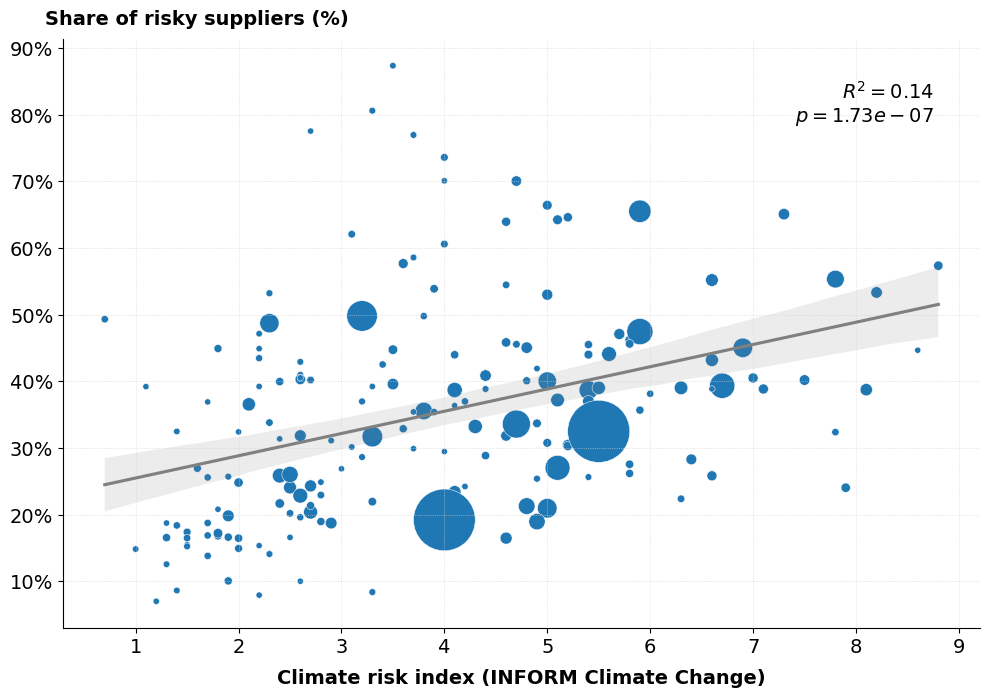

In [43]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief_2

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig3b.png")

# Show the plot
#####
plt.show()

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


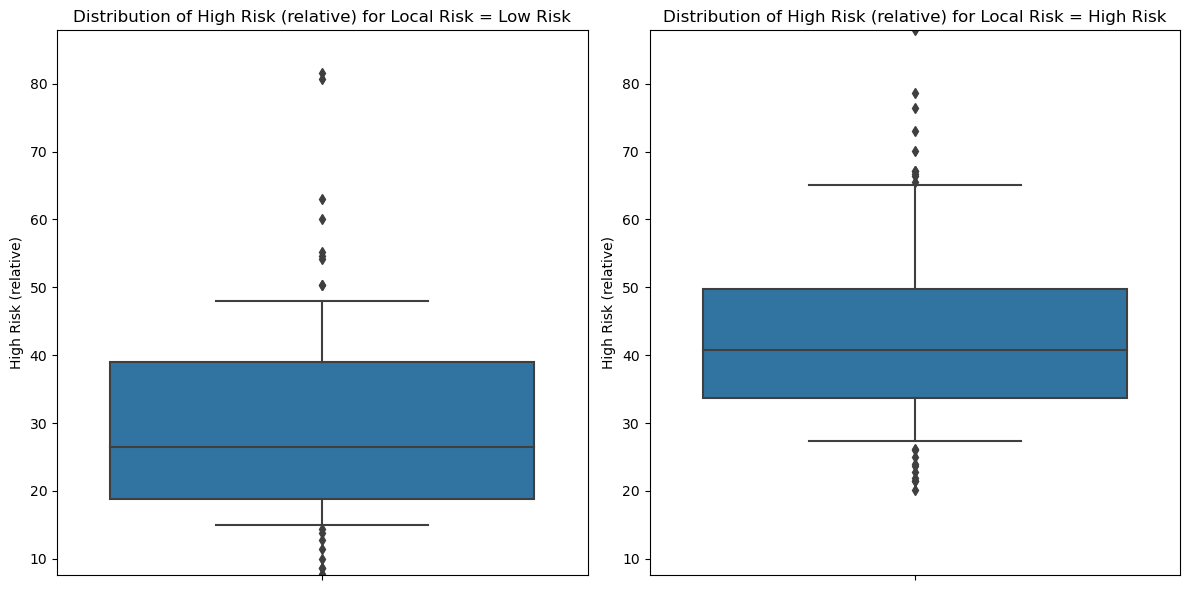

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming resulting_dataframe_country_cons_leontief is already defined
df = resulting_dataframe_country_cons_leontief

# Separate the DataFrame into two based on 'Local Risk'
df_low_risk = df[df['Local Risk'] == 'Low Risk']
df_high_risk = df[df['Local Risk'] == 'High Risk']

# Determine the Y-axis limits based on the combined range of both subsets
y_min = min(df_low_risk['High Risk (relative)'].min(), df_high_risk['High Risk (relative)'].min())
y_max = max(df_low_risk['High Risk (relative)'].max(), df_high_risk['High Risk (relative)'].max())

# Plotting the boxplots
plt.figure(figsize=(12, 6))

# Boxplot for Low Risk
plt.subplot(1, 2, 1)
sns.boxplot(y='High Risk (relative)', data=df_low_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = Low Risk')
plt.ylim(y_min, y_max)

# Boxplot for High Risk
plt.subplot(1, 2, 2)
sns.boxplot(y='High Risk (relative)', data=df_high_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = High Risk')
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

#### XY Figure

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

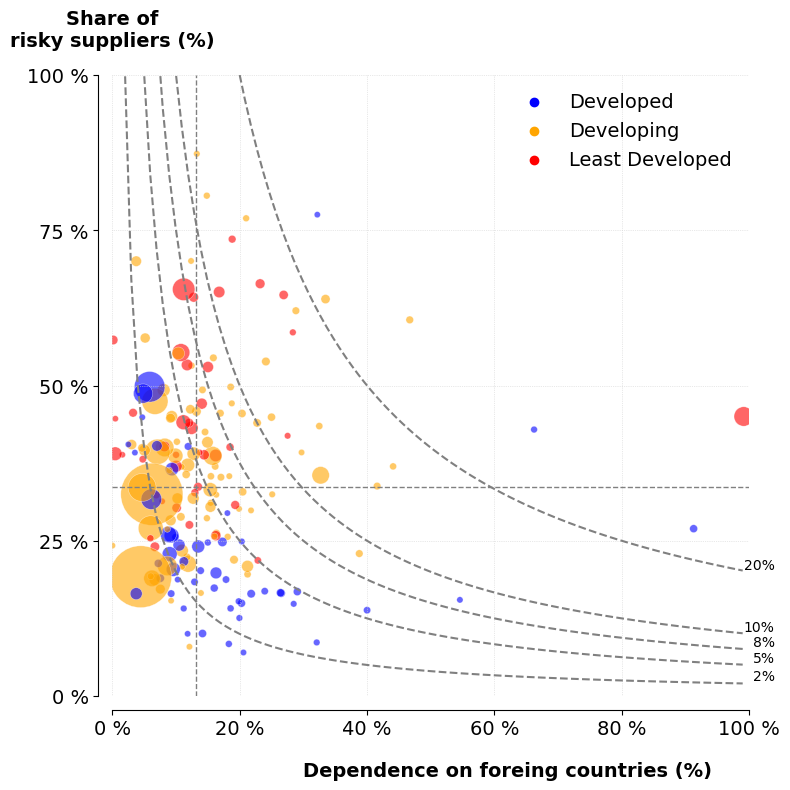

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_cons_leontief_2

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['red', 'blue', 'orange']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )
    
    handles, labels = scatter.get_legend_handles_labels()
    # Example indices - replace them with actual indices from your list
    developed_index = labels.index('Developed')
    developing_index = labels.index('Developing')
    least_developed_index = labels.index('Least Developed')

    # Reorder handles and labels
    ordered_handles = [handles[developed_index], handles[developing_index], handles[least_developed_index]]
    ordered_labels = ['Developed', 'Developing', 'Least Developed']

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=ordered_handles,
        labels=ordered_labels,
        loc='upper right',  # Adjust location as needed
        frameon=False,      # This removes the box around the legend
        fontsize=14
    )    
    
median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreing countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1b.png")

plt.show()

##### Analyzing Quadrants


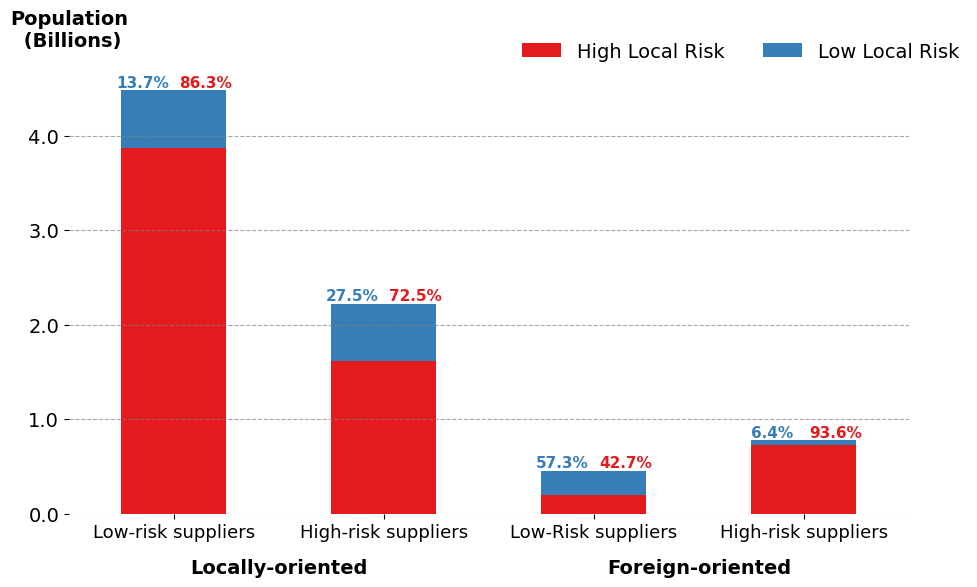

In [39]:
df = resulting_dataframe_country_cons_leontief_2
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig2b.png")

plt.show()

In [67]:
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.590400e+09  612406012.0
                     High-risk suppliers            1.886574e+09  609276249.0
Foreign-oriented     Low-risk suppliers             2.068078e+08  258874822.0
                     High-risk suppliers            7.106308e+08   49535279.0

In [56]:
population_by_risk['Low Risk'].sum()

1530092362.0

## Exports
-----

### Exports (Direct Intermediary + Final)
----

#### Code

In [114]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)
Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()

intermediary = mriot.Z

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######


values = {'VLR (%)': [0] * country_list.size}
cExports_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cExports_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cExports_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cExports_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cExports_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cExports_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

# Foreign_GO
######

for c in country_list:
    production_c = gross_output.loc[c].sum().iloc[0]
    #production_c= final_production.loc[c].sum()
    export_c_VLR=0
    export_c_LR=0
    export_c_MR=0
    export_c_HR=0
    export_c_VHR=0
    export_c_ROW=0
    for s in sector_list:
        country_list_except = [x for x in country_list if x != c]
        for cc in country_list_except:
            if cc=='ROW':
                 export_c_ROW=export_c_ROW+ intermediary.loc[c,s][cc].sum() + Y_matrix.loc[c,s][cc]
            if cc in VLR_list_MRIOT:
                 export_c_VLR=export_c_VLR+ intermediary.loc[c,s][cc].sum()+ Y_matrix.loc[c,s][cc]
            if cc in LR_list_MRIOT:
                 export_c_LR=export_c_LR+ intermediary.loc[c,s][cc].sum()+ Y_matrix.loc[c,s][cc]
            if cc in MR_list_MRIOT:
                 export_c_MR=export_c_MR+ intermediary.loc[c,s][cc].sum()+ Y_matrix.loc[c,s][cc]
            if cc in HR_list_MRIOT:
                 export_c_HR=export_c_HR+ intermediary.loc[c,s][cc].sum()+ Y_matrix.loc[c,s][cc]
            if cc in VHR_list_MRIOT:
                 export_c_VHR=export_c_VHR+ intermediary.loc[c,s][cc].sum()+ Y_matrix.loc[c,s][cc]
                    
    cExports_VLR.loc[c] = export_c_VLR / production_c*100
    cExports_LR.loc[c] = export_c_LR / production_c *100
    cExports_MR.loc[c] = export_c_MR / production_c *100
    cExports_HR.loc[c] = export_c_HR / production_c*100
    cExports_VHR.loc[c] = export_c_VHR / production_c *100
    cExports_ROW.loc[c] = export_c_ROW / production_c*100
    
    cExports.loc[c] = (export_c_VLR+export_c_LR+export_c_MR+export_c_HR+export_c_VHR+export_c_ROW)/production_c*100
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_VLR, cExports_LR, cExports_MR, cExports_HR, cExports_VHR,cExports_ROW, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_direct = pd.concat(dataframes_to_concat, axis=1)
resulting_dataframe_country_exports_direct = resulting_dataframe_country_exports_direct.drop('USR', errors='ignore')

C:\Users\delah\AppData\Local\Temp\ipykernel_6480\1963059318.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_6480\1963059318.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.16275008941838268' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_VLR.loc[c] = export_c_VLR / production_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_6480\1963059318.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.5289545005095798' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_LR.loc[c] = export_c_LR / production_c *100
C:\Users\delah\AppData\Local\Temp\ipykernel_6480\1963059318.p

In [115]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_direct.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_exports_direct = result

In [116]:
resulting_dataframe_country_exports_direct

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,Ethiopia,High Risk,6.9000000000,0.1000000000,Sub-Saharan Africa,Low income,126527060.0000000000,Least Developed,2.8757548243,76.5739754959,14.8801295052,0.9817730700,0.1545581634,0,95.4661910587,4.5338089413,79.4497303202,16.0164607385,16.7771025123
1,Belarus,Low Risk,1.6000000000,0.2000000000,Europe & Central Asia,Upper middle income,9167767.0000000000,Developed,5.8969847253,79.8081185092,3.8962323849,1.0864976182,0.2387543932,0,90.9265876307,9.0734123693,85.7051032344,5.2214843963,5.7425276064
2,Hong Kong,High Risk,4.0000000000,0.1000000000,East Asia & Pacific,High income,7350409.0000000000,Developing,7.3609018434,20.8062650067,30.9814580431,6.6485287489,0.3885081412,0,66.1856617833,33.8143382167,28.1671668501,38.0184949332,57.4421920229
3,Singapore,Low Risk,0.7000000000,0.1000000000,East Asia & Pacific,High income,5673743.0000000000,Developing,3.3046780151,16.3638003000,26.8564222626,6.1975033749,0.2657549992,0,52.9881589518,47.0118410482,19.6684783151,33.3196806367,62.8813706606
4,Ireland,Low Risk,1.7000000000,0.0000000000,Europe & Central Asia,High income,5120455.0000000000,Developed,6.5165035598,39.1408836309,2.9480454817,1.2749488775,0.1134811342,0,49.9938626842,50.0061373158,45.6573871908,4.3364754935,8.6740156904
6,Malta,Low Risk,1.5000000000,0.0000000000,Middle East & North Africa,High income,524909.0000000000,Developed,8.7278770434,29.4892610354,6.3320514664,2.1037330863,0.4902704581,0,47.1431930895,52.8568069105,38.2171380788,8.9260550107,18.9339211575
7,Djibouti,High Risk,4.9000000000,0.5000000000,Middle East & North Africa,Lower middle income,1136455.0000000000,Least Developed,4.0855375788,31.5930846978,5.3899397552,3.6086100198,1.2853686795,0,45.9625407311,54.0374592689,35.6786222766,10.2839184545,22.3745647889
8,Luxembourg,Low Risk,1.2000000000,0.1000000000,Europe & Central Asia,High income,657569.0000000000,Developed,5.1728505465,33.6803329705,2.8910409198,0.8997469769,0.1360340279,0,42.7800054416,57.2199945584,38.8531835170,3.9268219246,9.1791057154
9,United Arab Emirates,Low Risk,1.8000000000,0.2000000000,Middle East & North Africa,High income,9516871.0000000000,Developing,2.3592030109,22.6365251977,10.5812445521,6.0566525098,0.6155787877,0,42.2492040581,57.7507959419,24.9957282086,17.2534758496,40.8373985598
10,"Moldova, Republic of",Low Risk,2.6000000000,0.3000000000,Europe & Central Asia,Upper middle income,2464653.0000000000,Developed,11.2720179081,11.2383080555,6.3954531188,4.1033371260,7.9072316700,0,40.9163478784,59.0836521216,22.5103259636,18.4060219148,44.9845180941


In [106]:
data = mriot.Z.loc['FRA'].groupby(level='region', axis=1).sum().sum()
# Assuming 'data' is your Series
top_50 = data.nlargest(50)
top_50

C:\Users\delah\AppData\Local\Temp\ipykernel_25236\3130225691.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data = mriot.Z.loc['FRA'].groupby(level='region', axis=1).sum().sum()


region
FRA    2.149294e+09
DEU    6.741466e+07
CHN    3.911682e+07
GBR    3.441561e+07
USA    3.404644e+07
BEL    2.741773e+07
ITA    2.520657e+07
ESP    2.512447e+07
CHE    1.892784e+07
NLD    1.775915e+07
LUX    1.380669e+07
TUR    8.105990e+06
JPN    7.354691e+06
DZA    7.268839e+06
POL    7.049709e+06
IND    6.886323e+06
SGP    5.477949e+06
ARE    5.379994e+06
MAR    5.352592e+06
MEX    4.994041e+06
IRL    4.838092e+06
DNK    4.560725e+06
KOR    4.195813e+06
CAN    4.147954e+06
PRT    3.895899e+06
AUT    3.884463e+06
HKG    3.739612e+06
RUS    3.434195e+06
SAU    3.117304e+06
BRA    2.913553e+06
TUN    2.885244e+06
THA    2.787299e+06
GRC    2.628044e+06
SWE    2.485980e+06
HUN    2.425055e+06
CZE    2.235794e+06
ISR    2.143362e+06
MYS    1.944643e+06
ROU    1.818832e+06
NOR    1.784554e+06
CIV    1.650302e+06
SVK    1.573922e+06
CMR    1.516473e+06
FIN    1.445182e+06
IDN    1.402171e+06
VNM    1.351058e+06
ZAF    1.321085e+06
QAT    1.294970e+06
IRQ    1.231279e+06
AUS    1.2248

In [118]:
#Importations directes
data = mriot.Z['ETH'].groupby(level='region', axis=0).sum().T.sum()

top_50 = data.nlargest(50)
top_50

C:\Users\delah\AppData\Local\Temp\ipykernel_25236\2665735259.py:2: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  data = mriot.Z['ETH'].groupby(level='region', axis=0).sum().T.sum()


region
ETH    119706.894710
IND     49181.495063
CHN     29804.323884
ITA     25876.573189
USA     19781.191676
DEU     18474.662146
GBR     15830.501891
NLD     10995.404212
BEL      7816.485722
FRA      6862.715853
ZAF      6468.438847
VNM      5968.680711
TUR      5741.659640
SWE      5714.959936
ESP      5287.087301
CHE      4839.066138
JPN      4769.268984
DNK      3622.505881
THA      3517.585552
KOR      3009.791169
ISR      2921.750150
IRL      2787.835108
KEN      2681.458973
AUS      2660.740938
SGP      2474.964467
GRC      2420.668777
BRA      2055.815799
RUS      1570.061784
AUT      1561.004678
SVK      1552.887693
PRY      1515.668115
LUX      1327.307984
CZE      1297.003149
IRN      1244.158661
HUN      1035.148907
MLT       985.440406
HKG       912.972672
POL       900.035795
QAT       849.931700
IDN       832.750851
GEO       779.749421
PRT       731.692041
FIN       718.416509
ZWE       713.300958
SVN       650.402873
MYS       643.901543
KAZ       618.806808
KGZ   

#### Correlation Risk & Climate-Foreign-Dependence


C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

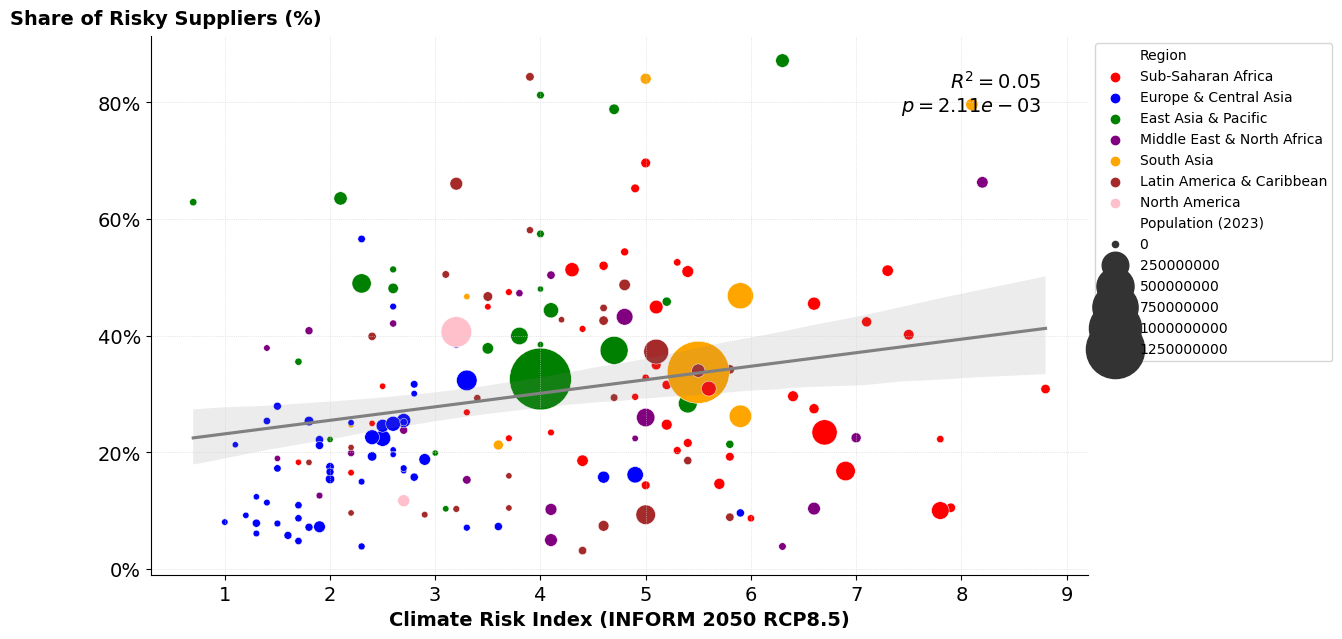

In [119]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_direct

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='region'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Region', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate Risk Index (INFORM 2050 RCP8.5)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.15, 1.05, 'Share of Risky Suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig2c.png")

# Show the plot
#####
plt.show()

#### XY Figure

##### Plot

In [74]:
### import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_exports_direct

# Adjust the figure size as needed
plt.figure(figsize=(10, 10))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['red', 'blue', 'orange', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        frameon=False,      # Suppress the legend box
        fontsize=14
    )
    
median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(35, -9, 'Foreign Dependence (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\n Risky Suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=12)  # Adjust fontsize as needed
plt.yticks(fontsize=12)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig2a.png")

plt.show()

NameError: name 'resulting_dataframe_country_exports_direct' is not defined

##### Analyzing Quadrants

In [ ]:
df = resulting_dataframe_country_exports_direct
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 5.3e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

# Show the plot
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig2b.png")

plt.show()

### Exports (Direct Final Consumption)

#### Code

In [89]:
import pandas as pd

final_production = mriot.Y.groupby(level='region', axis=1).sum().groupby(level='region', axis=0).sum().copy()

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Pour chaque pays, quelle pondération de la consommation finale ?
####

values = {'VLR (%)': [0] * country_list.size}
cExports_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cExports_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cExports_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cExports_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cExports_VHR = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cProd_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cProd_Local = pd.DataFrame(values, index=country_list)

for c in country_list: # list of countries exporting
    cExport = final_production.loc[c]
    cProd_tot = final_production.loc[c].sum()
    country_list_except = [x for x in country_list if x != c]
    for cc in country_list_except: # countries exported to
        if cc in VLR_list_MRIOT:
            cExports_VLR.loc[c] = cExports_VLR.loc[c]+cExport.loc[cc]
        if cc in LR_list_MRIOT:
            cExports_LR.loc[c] = cExports_LR.loc[c]+cExport.loc[cc]
        if cc in MR_list_MRIOT:
            cExports_MR.loc[c] = cExports_MR.loc[c]+cExport.loc[cc]
        if cc in HR_list_MRIOT:
            cExports_HR.loc[c] = cExports_HR.loc[c]+cExport.loc[cc]
        if cc in VHR_list_MRIOT:
            cExports_VHR.loc[c] = cExports_VHR.loc[c]+cExport.loc[cc]
    cProd_Foreign.loc[c] = cExports_VLR.loc[c].iloc[0] + cExports_LR.loc[c].iloc[0] + cExports_MR.loc[c].iloc[0] + cExports_HR.loc[c].iloc[0] + cExports_VHR.loc[c].iloc[0]
    cProd_Local.loc[c] = cProd_tot - cProd_Foreign.loc[c].iloc[0]
    
    #Ratios
    cExports_VLR.loc[c]=cExports_VLR.loc[c]/cProd_tot*100
    cExports_LR.loc[c]=cExports_LR.loc[c]/cProd_tot*100
    cExports_MR.loc[c]=cExports_MR.loc[c]/cProd_tot*100
    cExports_HR.loc[c]=cExports_HR.loc[c]/cProd_tot*100
    cExports_VHR.loc[c]=cExports_VHR.loc[c]/cProd_tot*100
    
    cProd_Local.loc[c]=cProd_Local.loc[c]/cProd_tot*100
    cProd_Foreign.loc[c]=cProd_Foreign.loc[c]/cProd_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_VLR, cExports_LR, cExports_MR, cExports_HR, cExports_VHR, cProd_Foreign, cProd_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_export_fin_direct = pd.concat(dataframes_to_concat, axis=1)

resulting_dataframe_country_export_fin_direct = resulting_dataframe_country_export_fin_direct.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_export_fin_direct.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_export_fin_direct = result

C:\Users\delah\AppData\Local\Temp\ipykernel_25236\1726902699.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production = mriot.Y.groupby(level='region', axis=1).sum().groupby(level='region', axis=0).sum().copy()
C:\Users\delah\AppData\Local\Temp\ipykernel_25236\1726902699.py:3: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  final_production = mriot.Y.groupby(level='region', axis=1).sum().groupby(level='region', axis=0).sum().copy()
C:\Users\delah\AppData\Local\Temp\ipykernel_25236\1726902699.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '278.771681' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_LR.loc[c] = cExports_LR.loc[c]+cExport.loc[cc]
C:\Users\delah\AppData\Local\Temp\ipykernel_25236\1726902699.py:44: FutureWarning

#### Correlation Risk & Climate-Foreign-Dependence


C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_25236\538871234.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)',

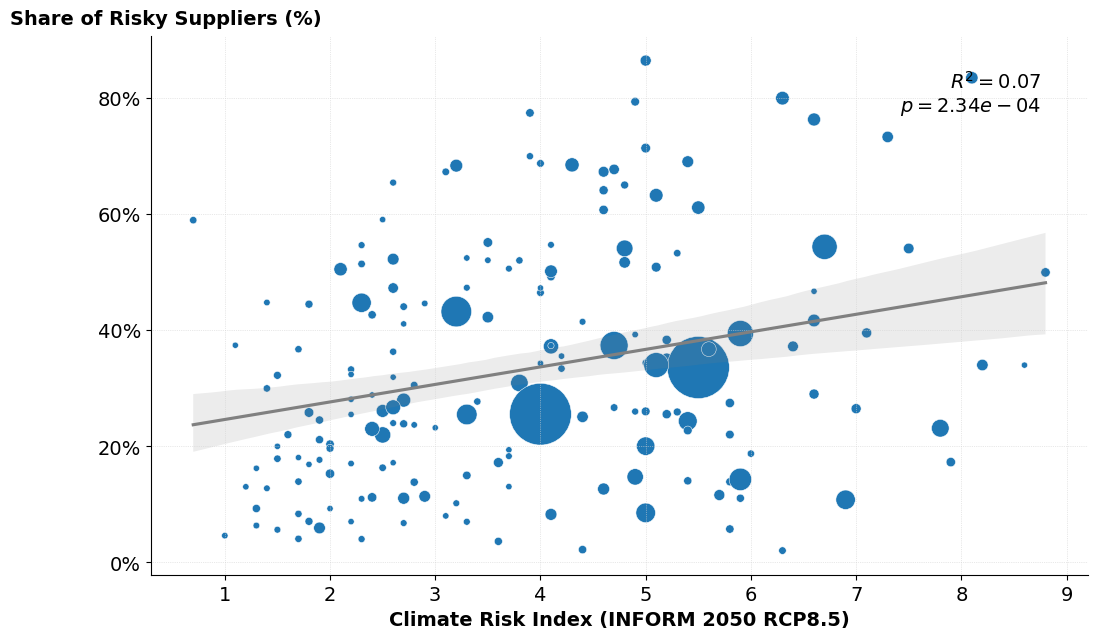

In [92]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_export_fin_direct

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate Risk Index (INFORM 2050 RCP8.5)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.15, 1.05, 'Share of Risky Suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Fig2c.png")

# Show the plot
#####
plt.show()

In [90]:
resulting_dataframe_country_export_fin_direct

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,Ethiopia,High Risk,6.9,0.1,Sub-Saharan Africa,Low income,126527060.0,Least Developed,2.650166,63.979295,5.133981,2.590294,0.334233,74.687969,25.312031,66.629461,8.058508,10.789567
1,Hong Kong,High Risk,4.0,0.1,East Asia & Pacific,High income,7350409.0,Developing,6.061482,24.836462,18.986178,7.287836,0.515588,57.687545,42.312455,30.897944,26.789602,46.439143
2,Luxembourg,Low Risk,1.2,0.1,Europe & Central Asia,High income,657569.0,Developed,7.476730,37.069800,4.702393,1.689171,0.277734,51.215827,48.784173,44.546530,6.669297,13.021945
3,Ireland,Low Risk,1.7,0.0,Europe & Central Asia,High income,5120455.0,Developed,6.523100,37.839714,2.508033,1.385587,0.153736,48.410171,51.589829,44.362814,4.047357,8.360550
4,Malta,Low Risk,1.5,0.0,Middle East & North Africa,High income,524909.0,Developed,5.148205,32.666417,5.584145,3.278259,0.583218,47.260244,52.739756,37.814622,9.445622,19.986401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Libya,High Risk,6.3,0.1,Middle East & North Africa,Upper middle income,6888388.0,Developing,0.014062,0.217146,0.002725,0.001299,0.000780,0.236013,99.763987,0.231209,0.004804,2.035472
183,Venezuela (Bolivarian Republic of),High Risk,4.6,0.4,Latin America & Caribbean,Upper middle income,28838499.0,Developing,0.015254,0.056925,0.035883,0.108765,0.003608,0.220435,99.779565,0.072179,0.148256,67.256214
184,Guyana,High Risk,4.2,-0.1,Latin America & Caribbean,High income,813834.0,Developing,0.017914,0.033650,0.010165,0.008077,0.010159,0.079966,99.920034,0.051564,0.028401,35.516739
185,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.009317,0.017939,0.004154,0.020136,0.002888,0.054433,99.945567,0.027256,0.027178,49.928409


### Exports (Direct Intermediary)
-----

#### Code
-----

In [106]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)
Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()

intermediary = mriot.Z

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######


values = {'VLR (%)': [0] * country_list.size}
cExports_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cExports_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cExports_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cExports_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cExports_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cExports_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

# Foreign_GO
######

for c in country_list:
    production_c = gross_output.loc[c].sum().iloc[0]
    export_c_VLR=0
    export_c_LR=0
    export_c_MR=0
    export_c_HR=0
    export_c_VHR=0
    export_c_ROW=0
    for s in sector_list:
        country_list_except = [x for x in country_list if x != c]
        for cc in country_list_except:
            if cc=='ROW':
                 export_c_ROW=export_c_ROW+ intermediary.loc[c,s][cc].sum()
            if cc in VLR_list_MRIOT:
                 export_c_VLR=export_c_VLR+ intermediary.loc[c,s][cc].sum()
            if cc in LR_list_MRIOT:
                 export_c_LR=export_c_LR+ intermediary.loc[c,s][cc].sum()
            if cc in MR_list_MRIOT:
                 export_c_MR=export_c_MR+ intermediary.loc[c,s][cc].sum()
            if cc in HR_list_MRIOT:
                 export_c_HR=export_c_HR+ intermediary.loc[c,s][cc].sum()
            if cc in VHR_list_MRIOT:
                 export_c_VHR=export_c_VHR+ intermediary.loc[c,s][cc].sum()
                    
    cExports_VLR.loc[c] = export_c_VLR / production_c*100
    cExports_LR.loc[c] = export_c_LR / production_c *100
    cExports_MR.loc[c] = export_c_MR / production_c *100
    cExports_HR.loc[c] = export_c_HR / production_c*100
    cExports_VHR.loc[c] = export_c_VHR / production_c *100
    cExports_ROW.loc[c] = export_c_ROW / production_c*100
    
    cExports.loc[c] = (export_c_VLR+export_c_LR+export_c_MR+export_c_HR+export_c_VHR+export_c_ROW)/production_c*100
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_VLR, cExports_LR, cExports_MR, cExports_HR, cExports_VHR,cExports_ROW, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_direct_CI = pd.concat(dataframes_to_concat, axis=1)
resulting_dataframe_country_exports_direct_CI = resulting_dataframe_country_exports_direct_CI.drop('USR', errors='ignore')

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_direct_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_exports_direct_CI = result

C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2743054593.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y_matrix = final_production_by_use.groupby(axis=1, level=0).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2743054593.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.11292107424211743' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_VLR.loc[c] = export_c_VLR / production_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\2743054593.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.3533781728654127' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_LR.loc[c] = export_c_LR / production_c *100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\27430545

### Exports (Leontief CI)
----

#### Code

In [92]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######

values = {'VLR (%)': [0] * country_list.size}
cExports_VLR = pd.DataFrame(values, index=country_list)

values = {'LR (%)': [0] * country_list.size}
cExports_LR = pd.DataFrame(values, index=country_list)

values = {'MR (%)': [0] * country_list.size}
cExports_MR = pd.DataFrame(values, index=country_list)

values = {'HR (%)': [0] * country_list.size}
cExports_HR = pd.DataFrame(values, index=country_list)

values = {'VHR (%)': [0] * country_list.size}
cExports_VHR = pd.DataFrame(values, index=country_list)

values = {'ROW (%)': [0] * country_list.size}
cExports_ROW = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

# Foreign_GO
######


for c in country_list:
    exports_c = 0
    exports_c_VLR = 0
    exports_c_LR = 0
    exports_c_MR = 0
    exports_c_HR = 0
    exports_c_VHR = 0
    exports_c_ROW = 0
    final_production_c = final_production[~final_production.index.get_level_values('region').isin([c])]
    final_production_c_VLR = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(VLR_list_MRIOT)]
    final_production_c_LR = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(LR_list_MRIOT)]
    final_production_c_MR = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(MR_list_MRIOT)]
    final_production_c_HR = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(HR_list_MRIOT)]
    final_production_c_VHR = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(VHR_list_MRIOT)]
    final_production_c_ROW = final_production[~final_production.index.get_level_values('region').isin([c]) & final_production.index.get_level_values('region').isin(['ROW'])]
    production= gross_output.loc[c].sum().iloc[0]

    for s in sector_list:
        leontieff_cs = leontieff.loc[c,s]
        
        leontieff_cs = leontieff_cs[leontieff_cs.index.get_level_values('region') != c]
        leontieff_cs_foreign_VLR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VLR_list_MRIOT)]
        leontieff_cs_foreign_LR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(LR_list_MRIOT)]
        leontieff_cs_foreign_MR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(MR_list_MRIOT)]
        leontieff_cs_foreign_HR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(HR_list_MRIOT)]
        leontieff_cs_foreign_VHR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VHR_list_MRIOT)]
        leontieff_cs_foreign_ROW = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(['ROW'])]
        
        exports_cs = (leontieff_cs*final_production_c).sum()
        exports_cs_VLR = (leontieff_cs_foreign_VLR*final_production_c_VLR).sum()
        exports_cs_LR = (leontieff_cs_foreign_LR*final_production_c_LR).sum()
        exports_cs_MR = (leontieff_cs_foreign_MR*final_production_c_MR).sum()
        exports_cs_HR = (leontieff_cs_foreign_HR*final_production_c_HR).sum()
        exports_cs_VHR = (leontieff_cs_foreign_VHR*final_production_c_VHR).sum()
        exports_cs_ROW = (leontieff_cs_foreign_ROW*final_production_c_ROW).sum()
        
        exports_c = exports_c + exports_cs
        exports_c_VLR = exports_c_VLR + exports_cs_VLR  
        exports_c_LR = exports_c_LR + exports_cs_LR  
        exports_c_MR = exports_c_MR + exports_cs_MR   
        exports_c_HR = exports_c_HR + exports_cs_HR   
        exports_c_VHR = exports_c_VHR + exports_cs_VHR   
        exports_c_ROW = exports_c_ROW + exports_cs_ROW  

    cExports.loc[c] = exports_c / production*100
    cExports_VLR.loc[c] = exports_c_VLR / production*100
    cExports_LR.loc[c] = exports_c_LR / production *100
    cExports_MR.loc[c] = exports_c_MR / production *100
    cExports_HR.loc[c] = exports_c_HR / production*100
    cExports_VHR.loc[c] = exports_c_VHR / production *100
    cExports_ROW.loc[c] = exports_c_ROW / production*100
    
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_VLR, cExports_LR, cExports_MR, cExports_HR, cExports_VHR,cExports_ROW, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CI = pd.concat(dataframes_to_concat, axis=1)

C:\Users\delah\AppData\Local\Temp\ipykernel_15168\1375314352.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.4430912088531453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports.loc[c] = exports_c / production*100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\1375314352.py:98: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.12632251416827184' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_VLR.loc[c] = exports_c_VLR / production*100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\1375314352.py:99: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.5332982234232738' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_LR.loc[

In [93]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_exports_leontief_CI = result

In [94]:
resulting_dataframe_country_exports_leontief_CI

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
0,Belarus,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,7.428180,73.684144,8.818596,2.195237,0.367386,0,92.536338,7.463662,81.112324,11.381219,12.304880
1,Ethiopia,High Risk,6.9,0.1,Sub-Saharan Africa,Low income,126527060.0,Least Developed,3.735324,68.055028,16.160169,1.543092,0.226543,0,89.744941,10.255059,71.790353,17.929804,19.984143
7,Malta,Low Risk,1.5,0.0,Middle East & North Africa,High income,524909.0,Developed,8.759576,36.570075,12.420643,3.269706,0.650630,0,61.774144,38.225856,45.329650,16.340978,26.497182
9,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,3.045167,37.581321,11.935780,3.337190,1.528528,0,57.709194,42.290806,40.626487,16.801498,29.256639
10,Djibouti,High Risk,4.9,0.5,Middle East & North Africa,Lower middle income,1136455.0,Least Developed,3.501382,34.798016,11.651088,4.310804,1.434900,0,56.070892,43.929108,38.299398,17.396793,31.235157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Yemen,High Risk,8.2,0.1,Middle East & North Africa,Low income,34449825.0,Least Developed,0.110070,1.197755,2.303846,0.180787,0.012730,0,3.806071,96.193929,1.307825,2.497362,65.630463
188,Afghanistan,High Risk,8.1,0.1,South Asia,Low income,42239854.0,Least Developed,0.126323,0.533298,0.266383,1.484694,0.030019,0,2.443091,97.556909,0.659621,1.781096,72.974301
189,Sudan,High Risk,6.6,0.2,NaN,NaN,0.0,Least Developed,0.048331,0.749477,0.257826,0.060027,0.019861,0,1.141849,98.858151,0.797808,0.337714,29.740847
190,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.008333,0.097372,0.023880,0.013758,0.009482,0,0.153248,99.846752,0.105705,0.047120,30.832525


In [95]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_exports_leontief_CI.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_leontief_CI, f)

In [62]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_exports_leontief_CI.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_leontief_CI = pickle.load(f)

#### Correlation Risk & Climate-Foreign-Dependence
-----

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\3637620891.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)'

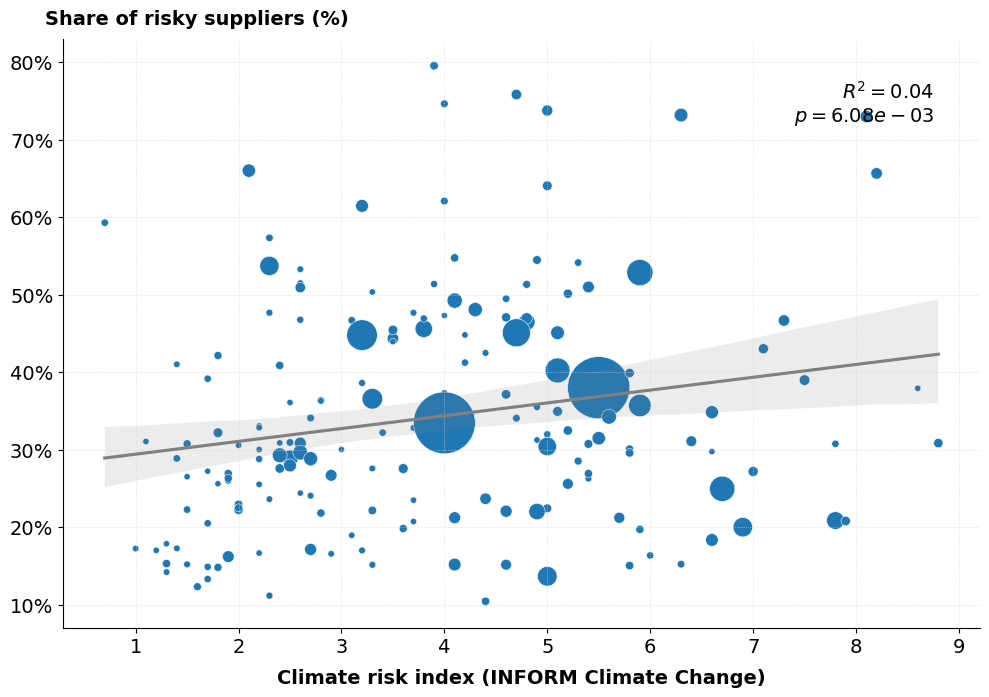

In [45]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CI

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig3c.png")

# Show the plot
#####
plt.show()

In [249]:
# Setting options to display the entire series
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.10f}'.format)
high_risk_countries=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
#Exports
a=mriot.Z.loc['COD'].sum().groupby('region').sum().sort_values(ascending=False)
#mriot.Z['COG'].T.sum().groupby('region').sum().sort_values(ascending=False)
#a=mriot.Z['COD'].T.sum().groupby('region').sum().sort_values(ascending=False)
# Convert the Series to a DataFrame and reset the index
a = a.reset_index()
a=a[a['region']!='COD']
# Rename the columns appropriately
a.columns = ['region', 'value']

risk=a[a['region'].isin(high_risk_countries)]['value'].sum()
summ = a['value'].sum()
risk/summ*100


8.866259806962299

In [197]:
resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Country']=='Congo']

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),...,HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative),High Risk (relative) Category,Foreign (%) Category
32,Congo,High Risk,5.3000000000,0.1000000000,Sub-Saharan Africa,Lower middle income,6106869.0000000000,Developing,3.1166411636,16.7072806527,...,3.8041420231,0.2621031164,0,30.2916558206,69.7083441794,19.8239218163,10.4065984141,34.4241459783,High-risk suppliers,Foreign-oriented


C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


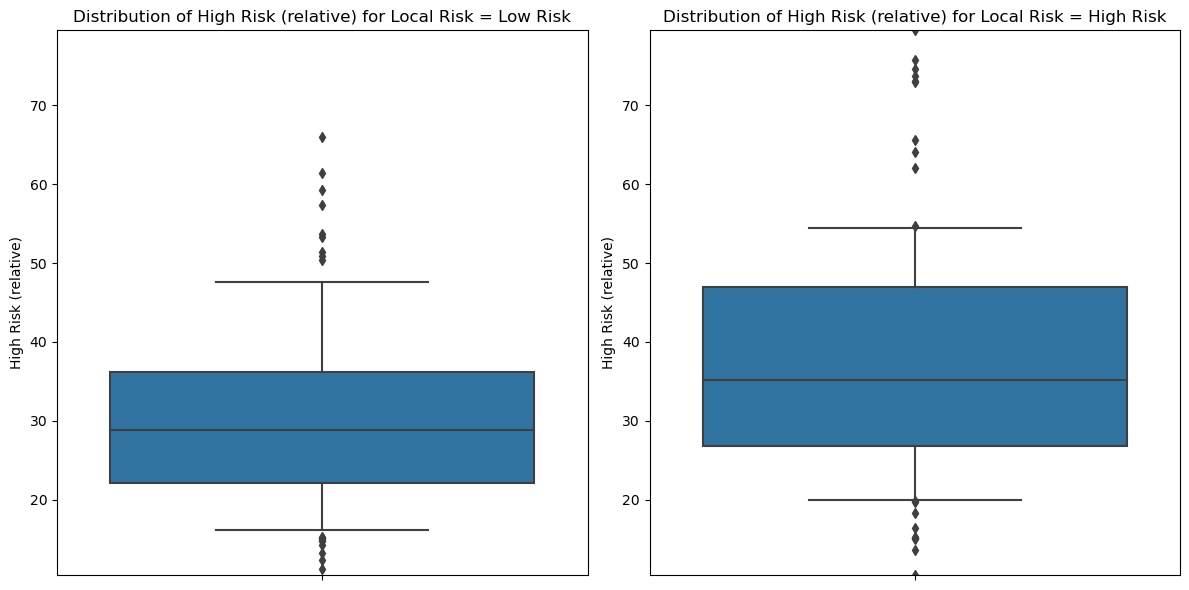

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming resulting_dataframe_country_cons_leontief is already defined
df = resulting_dataframe_country_exports_leontief_CI

# Separate the DataFrame into two based on 'Local Risk'
df_low_risk = df[df['Local Risk'] == 'Low Risk']
df_high_risk = df[df['Local Risk'] == 'High Risk']

# Determine the Y-axis limits based on the combined range of both subsets
y_min = min(df_low_risk['High Risk (relative)'].min(), df_high_risk['High Risk (relative)'].min())
y_max = max(df_low_risk['High Risk (relative)'].max(), df_high_risk['High Risk (relative)'].max())

# Plotting the boxplots
plt.figure(figsize=(12, 6))

# Boxplot for Low Risk
plt.subplot(1, 2, 1)
sns.boxplot(y='High Risk (relative)', data=df_low_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = Low Risk')
plt.ylim(y_min, y_max)

# Boxplot for High Risk
plt.subplot(1, 2, 2)
sns.boxplot(y='High Risk (relative)', data=df_high_risk,whis=[10,90])
plt.title('Distribution of High Risk (relative) for Local Risk = High Risk')
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

#### XY Figure

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

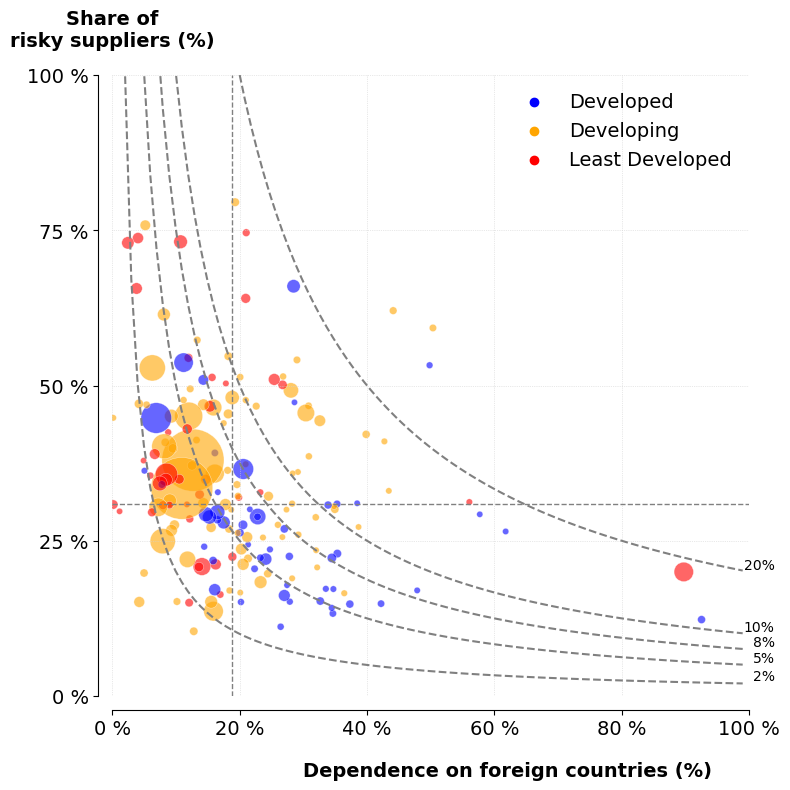

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_exports_leontief_CI

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'red', 'orange']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    num_developed_groups = len(result['Development'].unique())
    
    handles, labels = scatter.get_legend_handles_labels()
    # Example indices - replace them with actual indices from your list
    developed_index = labels.index('Developed')
    developing_index = labels.index('Developing')
    least_developed_index = labels.index('Least Developed')
    ordered_handles = [handles[developed_index], handles[developing_index], handles[least_developed_index]]
    ordered_labels = ['Developed', 'Developing', 'Least Developed']

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=ordered_handles,
        labels=ordered_labels,
        loc='upper right',  # Adjust location as needed
        frameon=False,      # This removes the box around the legend
        fontsize=14
    )    


median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1c.png")

plt.show()

##### Analyzing Quadrants


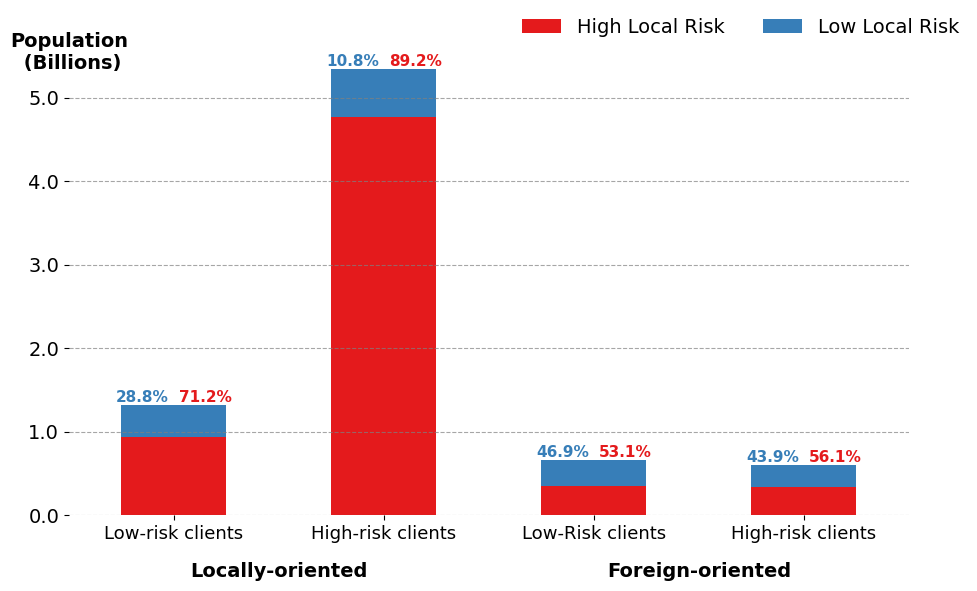

In [38]:
df = resulting_dataframe_country_exports_leontief_CI
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 5.3e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk clients', 'High-risk clients', 'Low-Risk clients', 'High-risk clients']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

plt.tight_layout()

# Show the plot
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig2c.png")

plt.show()

In [ ]:
a  = df_sorted[(df_sorted['High Risk (relative) Category'] == 'High-risk suppliers') & (df_sorted['Foreign (%) Category'] == 'Foreign-oriented')& (df_sorted['Local Risk'] == 'Low Risk')]
b  = df_sorted[(df_sorted['High Risk (relative) Category'] == 'High-risk suppliers') & (df_sorted['Foreign (%) Category'] == 'Foreign-oriented')& (df_sorted['Local Risk'] == 'High Risk')]
a_sum=a['Population (2023)'].sum()
b_sum = b['Population (2023)'].sum()
summ=a_sum+b_sum
a.sort_values(by='Population (2023)')

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),...,HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative),High Risk (relative) Category,Foreign (%) Category
9,Maldives,Low Risk,2.2,0.1,South Asia,Upper middle income,521021.0,Developing,2.289656,20.986643,...,1.511245,0.620307,0,30.568960,69.431040,23.276299,7.292661,23.856425,High-risk suppliers,Foreign-oriented
63,Cabo Verde,Low Risk,2.5,0.6,Sub-Saharan Africa,Lower middle income,598682.0,Developing,1.655062,9.253805,...,1.788556,0.695530,0,14.728571,85.271429,10.908867,3.819704,25.933976,High-risk suppliers,Foreign-oriented
77,Bhutan,Low Risk,3.3,0.1,South Asia,Lower middle income,787424.0,Least Developed,1.191921,5.874671,...,4.583826,0.570030,0,13.073402,86.926598,7.066592,6.006810,45.946801,High-risk suppliers,Foreign-oriented
16,Bahrain,Low Risk,1.4,0.3,Middle East & North Africa,High income,1485509.0,Developing,2.415357,13.722920,...,3.816342,0.084848,0,25.078823,74.921177,16.138276,8.940547,35.649786,High-risk suppliers,Foreign-oriented
11,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,3.568037,10.562633,...,3.327231,6.840347,0,29.892366,70.107634,14.130671,15.761695,52.728162,High-risk suppliers,Foreign-oriented
58,Mongolia,Low Risk,2.6,0.2,East Asia & Pacific,Lower middle income,3447157.0,Developing,0.369980,7.702305,...,0.219753,0.146546,0,15.177665,84.822335,8.072285,7.105381,46.814715,High-risk suppliers,Foreign-oriented
38,Georgia,Low Risk,3.2,0.1,Europe & Central Asia,Upper middle income,3698729.0,Developing,1.558984,10.058693,...,1.709345,0.590828,0,18.149751,81.850249,11.617676,6.532075,35.989888,High-risk suppliers,Foreign-oriented
21,Oman,Low Risk,2.6,0.2,Middle East & North Africa,High income,4644384.0,Developing,4.335370,8.637183,...,0.252868,0.257974,0,22.834724,77.165276,12.972553,9.862171,43.189359,High-risk suppliers,Foreign-oriented
5,Singapore,Low Risk,0.7,0.1,East Asia & Pacific,High income,5673743.0,Developing,2.593708,10.907676,...,3.734418,0.129154,0,37.975907,62.024093,13.501384,24.474523,64.447502,High-risk suppliers,Foreign-oriented
45,Bulgaria,Low Risk,2.5,0.3,Europe & Central Asia,Upper middle income,6386070.0,Developed,1.301087,10.834970,...,0.508404,0.149081,0,16.731590,83.268410,12.136057,4.595533,27.466204,High-risk suppliers,Foreign-oriented


In [70]:
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             7.032334e+08  370731286.0
                     High-risk suppliers            4.807941e+09  715725028.0
Foreign-oriented     Low-risk suppliers             4.380970e+08  317327426.0
                     High-risk suppliers            4.451417e+08  126308622.0

In [53]:
population_by_risk['Low Risk'].sum()

1530092362.0

### Exports (Leontief CF)
-----

#### Code

In [ ]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

leontief= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

low_risk_countries=VLR_list_MRIOT+LR_list_MRIOT
high_risk_countries = MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

final_production_by_destination = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = final_production_by_destination.groupby(level='region', axis=1).sum()

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            final_production_cs=final_production_by_destination.loc[c,s]
            final_production_cs_tot = final_production_cs.sum()

            risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
            risk_cs_high.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(high_risk_countries)].sum() / final_production_cs_tot*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)

In [36]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/risk_cs_exports_leontief.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [40]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/risk_cs_exports_leontief.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)
    
# Assuming 'df' is your DataFrame
risk_cs.index.names = ['region' if name == 'Country' else 'sector' if name == 'Sector' else name for name in risk_cs.index.names]

In [41]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

low_risk_countries=VLR_list_MRIOT+LR_list_MRIOT
high_risk_countries = MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT

values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)


for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    final_production_c = y[~y.index.get_level_values('region').isin([c])]
    final_production_and_risk_c_low = y[~y.index.get_level_values('region').isin([c])]*risk_cs.loc[c]['Low Risk']/100
    final_production_and_risk_c_high = y[~y.index.get_level_values('region').isin([c])]*risk_cs.loc[c]['High Risk']/100
    
    for s in sector_list:
        L_cs = L.loc[c,s]
        L_cs = L_cs[L_cs.index.get_level_values('region') != c]
        
        exports_cs= (L_cs*final_production_c).sum()
        exports_cs_low = (L_cs*final_production_and_risk_c_low).sum()
        exports_cs_high = (L_cs*final_production_and_risk_c_high).sum()
        
        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low  
        exports_c_high = exports_c_high + exports_cs_high  

    x_c = x.loc[c].sum().iloc[0]

    cExports.loc[c] = exports_c / x_c*100
    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CF = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CF.sort_values('Foreign (%)', ascending=False).reset_index()



# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_country_exports_leontief_CF = result

C:\Users\delah\AppData\Local\Temp\ipykernel_31584\50899750.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.4430912088531453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports.loc[c] = exports_c / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_31584\50899750.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.7160446907124519' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_31584\50899750.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.7245061978788816' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_high

In [60]:
resulting_dataframe_country_exports_leontief_CF

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative),High Risk (relative) Category,Foreign (%) Category
0,Belarus,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,92.536338,7.463662,79.904958,12.194560,13.240634,Low-risk suppliers,Foreign-oriented
1,Ethiopia,High Risk,6.9,0.1,Sub-Saharan Africa,Low income,126527060.0,Least Developed,89.744941,10.255059,70.978319,18.708511,20.859819,Low-risk suppliers,Foreign-oriented
7,Malta,Low Risk,1.5,0.0,Middle East & North Africa,High income,524909.0,Developed,61.774144,38.225856,43.622188,18.044530,29.261376,Low-risk suppliers,Foreign-oriented
9,San Marino,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,57.709194,42.290806,39.823126,17.658067,30.719730,Low-risk suppliers,Foreign-oriented
10,Djibouti,High Risk,4.9,0.5,Middle East & North Africa,Lower middle income,1136455.0,Least Developed,56.070892,43.929108,37.830666,17.940668,32.168260,High-risk suppliers,Foreign-oriented
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Yemen,High Risk,8.2,0.1,Middle East & North Africa,Low income,34449825.0,Least Developed,3.806071,96.193929,1.507112,2.297364,60.385826,High-risk suppliers,Locally-oriented
188,Afghanistan,High Risk,8.1,0.1,South Asia,Low income,42239854.0,Least Developed,2.443091,97.556909,0.716045,1.724506,70.660530,High-risk suppliers,Locally-oriented
189,Sudan,High Risk,6.6,0.2,NaN,NaN,0.0,Least Developed,1.141849,98.858151,0.787157,0.349243,30.732396,Low-risk suppliers,Locally-oriented
190,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.153248,99.846752,0.105305,0.047583,31.122580,Low-risk suppliers,Locally-oriented


In [59]:
a=wb_pop[['Country Name','Country Code']]
a = a.dropna()
a.reset_index()

# Importing the pandas library
import pandas as pd

#df.drop(columns=columns_to_drop, inplace=True)

# Exporting to an Excel file
a.to_excel(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\country_codes.xlsx", index=False)

In [87]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_exports_leontief_CF.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_leontief_CF, f)

In [61]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_exports_leontief_CF.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_leontief_CF = pickle.load(f)

#### Correlation Risk & Climate-Foreign-Dependence
-----

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_26000\4082174925.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)'

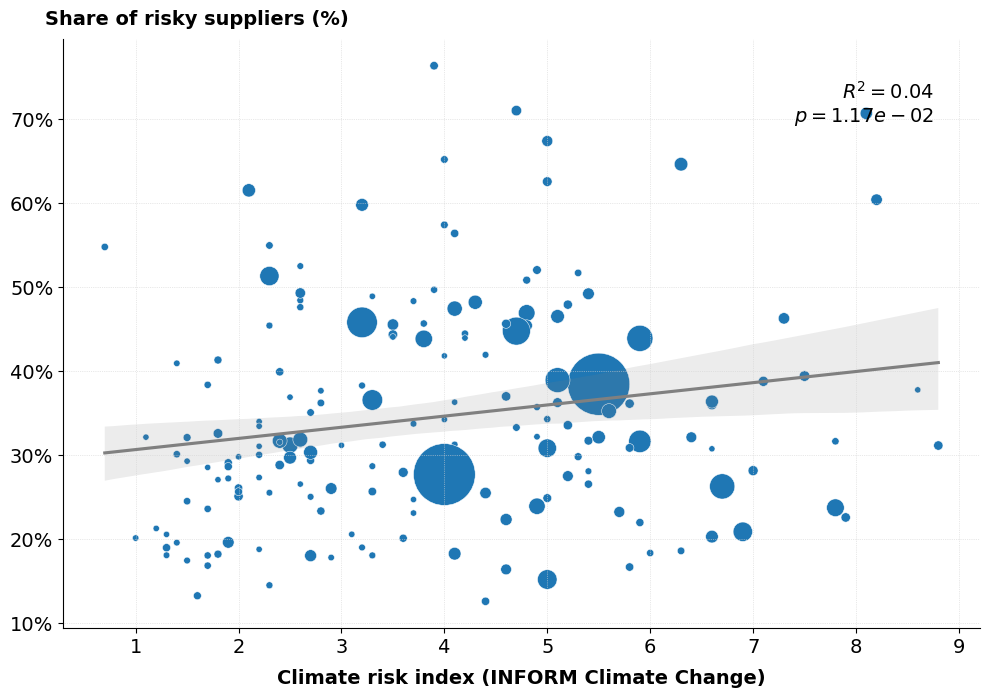

In [46]:
# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CF

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig3d.png")

# Show the plot
#####
plt.show()

#### XY Figure

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

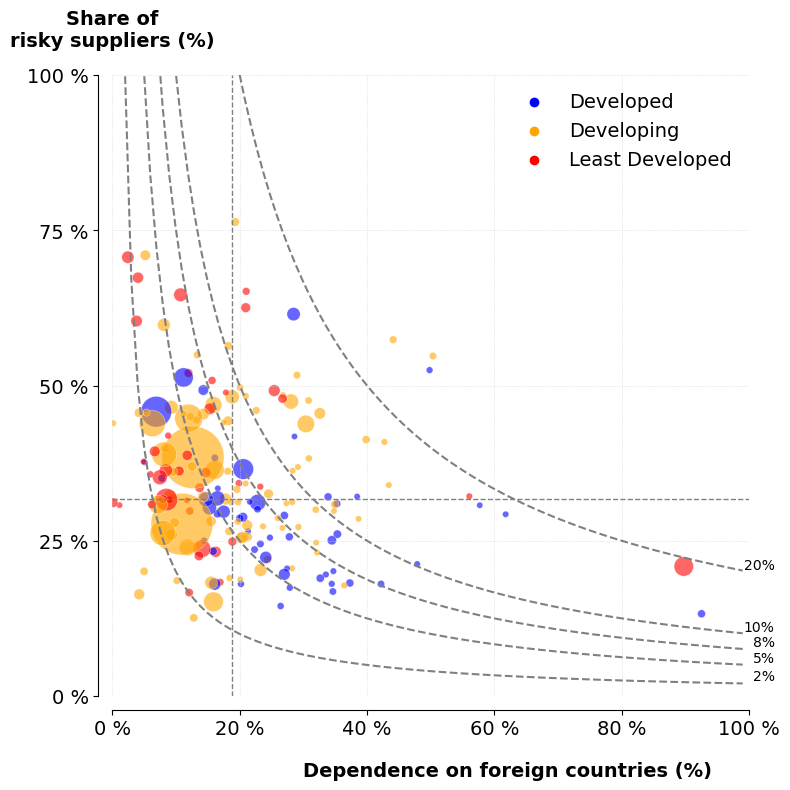

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_exports_leontief_CF

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'red', 'orange']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    num_developed_groups = len(result['Development'].unique())
    
    handles, labels = scatter.get_legend_handles_labels()
    # Example indices - replace them with actual indices from your list
    developed_index = labels.index('Developed')
    developing_index = labels.index('Developing')
    least_developed_index = labels.index('Least Developed')
    ordered_handles = [handles[developed_index], handles[developing_index], handles[least_developed_index]]
    ordered_labels = ['Developed', 'Developing', 'Least Developed']

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=ordered_handles,
        labels=ordered_labels,
        loc='upper right',  # Adjust location as needed
        frameon=False,      # This removes the box around the legend
        fontsize=14
    )    


median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1c.png")

plt.show()

##### Analyzing Quadrants


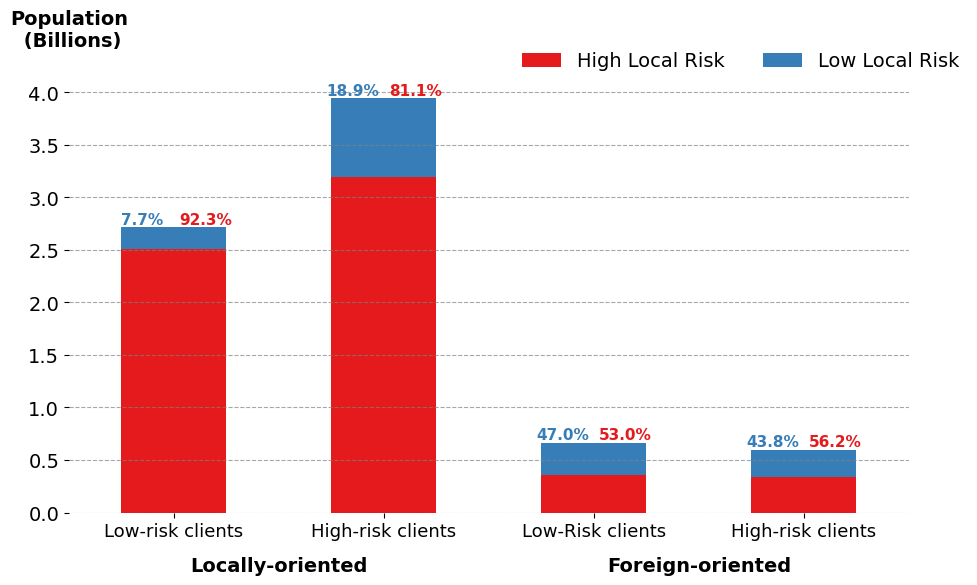

In [37]:
df = resulting_dataframe_country_exports_leontief_CF
# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.4e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk clients', 'High-risk clients', 'Low-Risk clients', 'High-risk clients']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

plt.tight_layout()
# Show the plot
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig2d.png")

plt.show()

## All together
----

In [82]:
inputs = resulting_dataframe_country_inputs_leontief
inputs= inputs.drop(columns=['VLR (%)',	'LR (%)', 'MR (%)', 'HR (%)', 'VHR (%)','ROW (%)'])
inputs = inputs.rename(columns={'Foreign (%)': 'Foreign Inputs (%)', 'Local (%)': 'Local Inputs (%)','Low Risk': 'Low Risk Inputs','High Risk':'High Risk Inputs','High Risk (imports)':'High Risk Inputs (imports)'})

conso = resulting_dataframe_country_cons_direct
conso= conso.drop(columns=['VLR (%)','LR (%)', 'MR (%)', 'HR (%)', 'VHR (%)','ROW (%)'])
conso = conso.rename(columns={'Foreign (%)': 'Foreign Conso (%)', 'Local (%)': 'Local Conso (%)','Low Risk': 'Low Risk Conso','High Risk':'High Risk Conso','High Risk (imports)':'High Risk Conso (imports)'})

result = conso.merge(inputs, on=['Country', 'Local Risk', 'Index 2050 (RCP8.5)','Change in Risk', 'Region',"Income group","Population (2023)","Development"], how='left')

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,Foreign Conso (%),Local Conso (%),Low Risk Conso,High Risk Conso,High Risk Conso (imports),Foreign Inputs (%),Local Inputs (%),Low Risk Inputs,High Risk Inputs,High Risk Inputs (imports)
0,Ethiopia,High Risk,6.9,0.1,Sub-Saharan Africa,Low income,126527060.0,Least Developed,99.124561,0.875439,52.301094,46.823467,47.236998,26.366562,73.633438,15.910877,10.357080,39.428571
1,Belarus,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,91.190654,8.809346,67.029194,24.161460,26.495545,13.712575,86.287425,7.993184,5.362888,40.153183
2,"Moldova, Republic of",Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,65.349042,34.650958,36.959713,28.389329,43.442609,58.516092,41.483908,34.932377,21.907539,38.542526
3,Malta,Low Risk,1.5,0.0,Middle East & North Africa,High income,524909.0,Developed,54.591903,45.408097,47.883406,6.708497,12.288446,39.328761,60.671239,31.868777,7.419244,18.884240
4,Georgia,Low Risk,3.2,0.1,Europe & Central Asia,Upper middle income,3698729.0,Developing,44.112665,55.887335,26.398133,17.714532,40.157474,5.986046,94.013954,3.250746,2.693047,45.308553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,Burundi,High Risk,5.8,0.7,Sub-Saharan Africa,Low income,13238559.0,Least Developed,3.251776,96.748224,1.701013,1.550763,47.689737,21.771737,78.228263,13.099452,8.323349,38.852758
167,Syrian Arab Republic,High Risk,7.0,0.0,Middle East & North Africa,Low income,23227014.0,Developing,3.034432,96.965568,1.722888,1.311544,43.222061,12.176032,87.823968,7.662345,4.506639,37.033813
168,Myanmar,High Risk,6.3,0.1,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.458541,99.541459,0.276806,0.181735,39.633274,0.824747,99.175253,0.502601,0.308055,38.000700
169,Somalia,High Risk,8.8,0.0,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.141246,99.858754,0.050914,0.090332,63.953770,1.714303,98.285697,0.939892,0.740242,44.058497


### Save Data
----

In [192]:
import pickle as pkl
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_cons_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_cons_direct, f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_cons_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_cons_leontief, f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_exports_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_exports_direct, f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_exports_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_exports_leontief, f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_inputs_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_inputs_direct, f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_inputs_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_inputs_leontief, f)

### Retrieve Data
-----

In [5]:
import pickle as pkl
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_cons_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_cons_direct = pkl.load(f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_cons_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_cons_leontief = pkl.load(f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_exports_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_exports_direct = pkl.load(f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_exports_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_exports_leontief = pkl.load(f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_inputs_direct_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_inputs_direct = pkl.load(f)
    
file_path = r"C:\Users\delah\Documents\Code\Exposition_commerciale\Tables IO\results\resulting_dataframe_country_inputs_leontief_eora.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_inputs_leontief = pkl.load(f)

In [4]:
 resulting_dataframe_country_inputs_direct.sort_values('Country', ascending=True).reset_index(drop=True)

,Country,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (imports)
0,Afghanistan,High Risk,8.1,0.1,South Asia,Low income,42239854.0,Least Developed,3.927358,9.301477,5.532420,1.981120,0.052518,0,20.847701,79.152299,13.228835,7.566058,36.384213
1,Albania,Low Risk,2.7,0.1,Europe & Central Asia,Upper middle income,2766215.0,Developed,1.578054,18.900035,4.939879,0.356350,0.092185,0,25.950440,74.049560,20.478089,5.388414,20.831630
2,Algeria,High Risk,4.1,0.2,Middle East & North Africa,Lower middle income,45606480.0,Developing,2.357082,23.617699,5.202048,0.969920,0.051955,0,32.206996,67.793004,25.974780,6.223924,19.329734
3,Angola,High Risk,5.4,0.9,Sub-Saharan Africa,Lower middle income,36684202.0,Least Developed,6.085853,6.616058,3.365966,3.161906,0.023334,0,19.265736,80.734264,12.701911,6.551205,34.026727
4,Antigua and Barbuda,Low Risk,2.2,0.2,Latin America & Caribbean,High income,94298.0,Developing,3.653382,26.131791,3.661274,1.522891,0.424762,0,35.870377,64.129623,29.785173,5.608927,15.847068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,Venezuela (Bolivarian Republic of),High Risk,4.6,0.4,Latin America & Caribbean,NaN,28838499.0,Developing,0.456099,7.578001,2.031848,2.762824,0.113504,0,12.964048,87.035952,8.034101,4.908176,37.923590
167,Viet Nam,High Risk,3.8,0.1,East Asia & Pacific,Lower middle income,98858950.0,Developing,12.049065,22.848131,21.723104,1.661323,0.057017,0,58.360145,41.639855,34.897195,23.441444,40.181678
168,Yemen,High Risk,8.2,0.1,Middle East & North Africa,Low income,34449825.0,Least Developed,1.332222,6.708766,5.491438,2.724275,0.028125,0,16.307390,83.692610,8.040988,8.243838,50.622821
169,Zambia,High Risk,5.0,0.8,Sub-Saharan Africa,Lower middle income,20569737.0,Least Developed,1.445234,3.312397,8.138975,1.126381,0.641387,0,14.688822,85.311178,4.757630,9.906743,67.556538


### Plot
----

#### Plot direct/leontief
---

C:\Users\delah\AppData\Local\Temp\ipykernel_7444\3987990537.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_7444\3987990537.py:108: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_7444\3987990537.py:147: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])


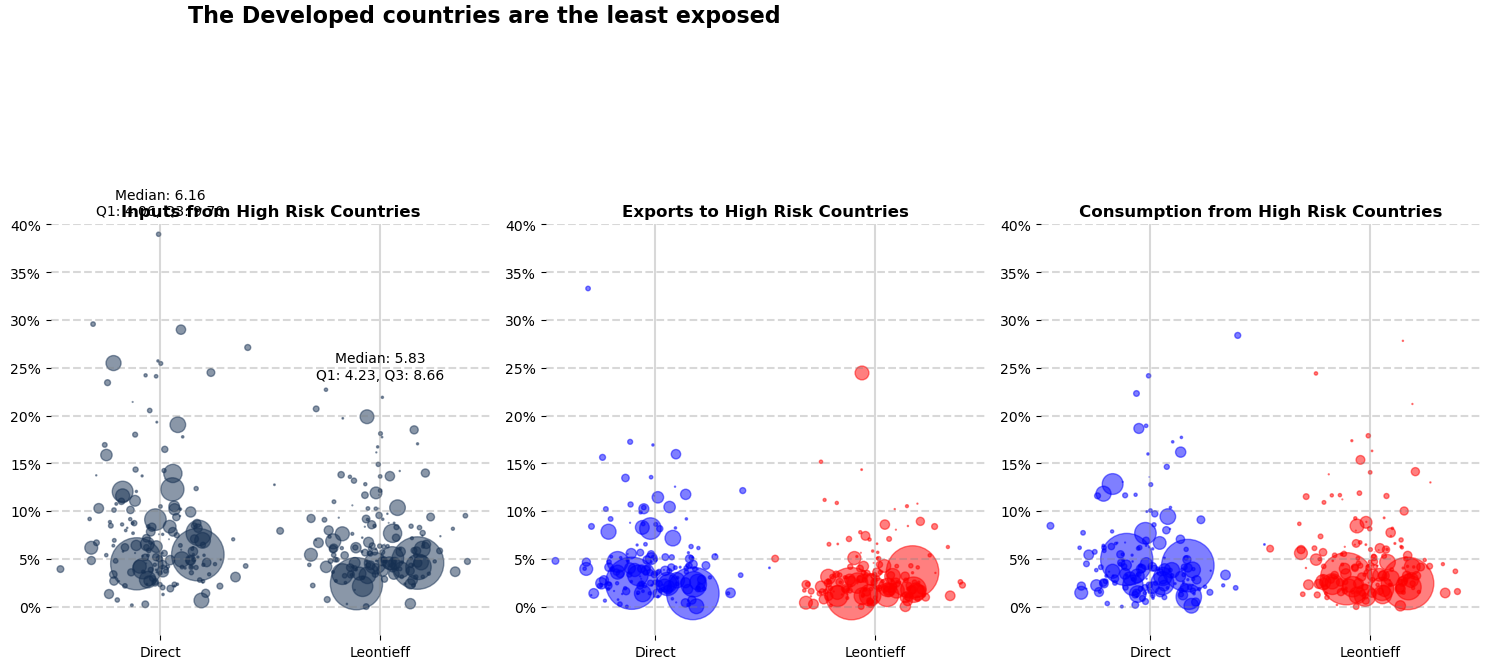

In [289]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

elegant_blue = (0.086, 0.188, 0.322)  

resulting_dataframe_country_inputs_direct =  resulting_dataframe_country_inputs_direct.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_cons_direct =  resulting_dataframe_country_cons_direct.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_exports_direct =  resulting_dataframe_country_exports_direct.sort_values('Country', ascending=True).reset_index(drop=True)

###########
# First pannel
###########

inputs_direct = resulting_dataframe_country_inputs_direct['High Risk']
#inputs_leontief = resulting_dataframe_country_inputs_leontief['High Risk']

# Scale population values for point sizes
population_sizes = resulting_dataframe_country_inputs_leontief['Population (2023)'] / 1000000

# Jitter data centered around x=1
x_data = np.random.normal(1, 0.15, size=len(y_data))

# Plot the first jitter plot (centered around x=1)
axs[0].scatter(x_data, inputs_direct, s=population_sizes, color=elegant_blue, alpha=0.5)

# Plot the second jitter plot (centered around x=2)
axs[0].scatter(x_data+1, inputs_leontief, s=population_sizes, color=elegant_blue, alpha=0.5)  # Choose a different color if needed

axs[0].set_title('Inputs from High Risk Countries',fontweight='bold',fontsize=12)
axs[0].set_xticks([1, 2])  # Set x-ticks to indicate the centers of the jitters
axs[0].set_xlim(0.5, 2.5)  # Adjust as needed
axs[0].set_ylim(-3, 40)  # Adjust as needed

# Custom x-axis labels
axs[0].set_xticks([1, 2])
axs[0].set_xticklabels(['Direct', 'Leontieff'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0].get_yticks():
    axs[0].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)



##########
# Second Pannel
##########

exports_direct = resulting_dataframe_country_exports_direct['High Risk']
exports_leontief = resulting_dataframe_country_exports_leontief['High Risk']

# Scale population values for point sizes
population_sizes = resulting_dataframe_country_inputs_leontief['Population (2023)'] / 1000000

# Plot the first jitter plot (centered around x=1)
axs[1].scatter(x_data, exports_direct, s=population_sizes, color='blue', alpha=0.5)

# Plot the second jitter plot (centered around x=2)
axs[1].scatter(x_data+1, exports_leontief, s=population_sizes, color='red', alpha=0.5)  # Choose a different color if needed

axs[1].set_title('Exports to High Risk Countries',fontweight='bold',fontsize=12)
axs[1].set_xticks([1, 2])  # Set x-ticks to indicate the centers of the jitters
axs[1].set_xlim(0.5, 2.5)  # Adjust as needed
axs[1].set_ylim(-3, 40)  # Adjust as needed

# Custom x-axis labels
axs[1].set_xticks([1, 2])
axs[1].set_xticklabels(['Direct', 'Leontieff'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1].get_yticks():
    axs[1].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

########
# Third panel
########
cons_direct = resulting_dataframe_country_cons_direct['High Risk']
cons_leontief = resulting_dataframe_country_cons_leontief['High Risk']

# Scale population values for point sizes
population_sizes = resulting_dataframe_country_inputs_leontief['Population (2023)'] / 1000000

# Plot the first jitter plot (centered around x=1)
axs[2].scatter(x_data, cons_direct, s=population_sizes, color='blue', alpha=0.5)

# Plot the second jitter plot (centered around x=2)
axs[2].scatter(x_data+1, cons_leontief, s=population_sizes, color='red', alpha=0.5)  # Choose a different color if needed

axs[2].set_title('Consumption from High Risk Countries',fontweight='bold',fontsize=12)
axs[2].set_xticks([1, 2])  # Set x-ticks to indicate the centers of the jitters
axs[2].set_xlim(0.5, 2.5)  # Adjust as needed
axs[2].set_ylim(-3, 40)  # Adjust as needed

# Custom x-axis labels
axs[2].set_xticks([1, 2])
axs[2].set_xticklabels(['Direct', 'Leontieff'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[2].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[2].get_yticks():
    axs[2].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[2].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[2].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Set labels and title
plt.text(0, 0.8, "The Developed countries are the least exposed",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 0.7, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Show the plot
plt.show()


#### Plot Developped VS Row with boxplots
----

C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3749042660.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3749042660.py:130: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 1].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3749042660.py:197: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3749042660.py:266: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3749042660.py:334: UserWarning: FixedFormat

NameError: name 'ax' is not defined

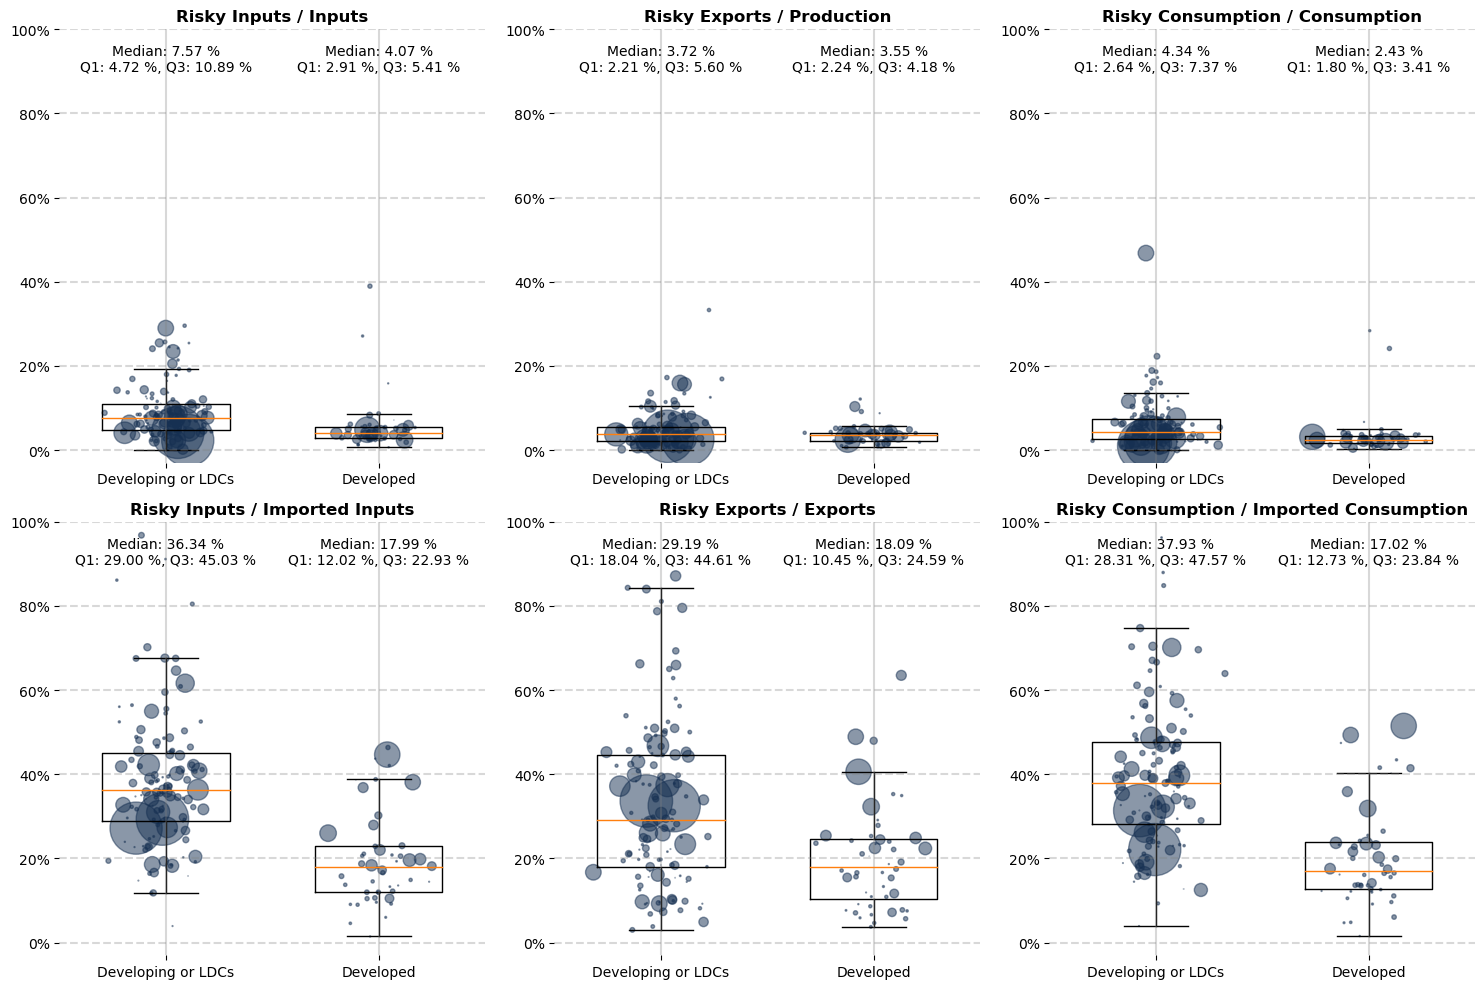

In [10]:
### import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  

elegant_blue = (0.086, 0.188, 0.322)  

resulting_dataframe_country_inputs_direct =  resulting_dataframe_country_inputs_direct.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_cons_direct =  resulting_dataframe_country_cons_direct.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_exports_direct =  resulting_dataframe_country_exports_direct.sort_values('Country', ascending=True).reset_index(drop=True)
lim=100

###########
# First line First pannel
###########

inputs_direct_Row = resulting_dataframe_country_inputs_direct[resulting_dataframe_country_inputs_direct['Development']!='Developed']
inputs_direct_developed = resulting_dataframe_country_inputs_direct[resulting_dataframe_country_inputs_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [inputs_direct_Row['High Risk'], inputs_direct_developed['High Risk']]

# Plot the boxplots
axs[0, 0].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = inputs_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = inputs_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(inputs_direct_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 0].scatter(x_positions_row, inputs_direct_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(inputs_direct_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 0].scatter(x_positions_developed, inputs_direct_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 0].set_title('Risky Inputs / Inputs', fontweight='bold', fontsize=12)

axs[0, 0].set_xlim(0.5, 2.5)
axs[0, 0].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 0].set_xticks([1, 2])
axs[0, 0].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 0].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 0].get_yticks():
    axs[0, 0].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 0].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 0].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)


# Calculate medians and quartiles
median_developed = np.median(inputs_direct_developed['High Risk'])
q1_developed, q3_developed = np.percentile(inputs_direct_developed['High Risk'], [25, 75])

median_row = np.median(inputs_direct_Row['High Risk'])
q1_row, q3_row = np.percentile(inputs_direct_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,0].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,0].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)


##########
# First Line Second Pannel
##########


exports_direct_Row = resulting_dataframe_country_exports_direct[resulting_dataframe_country_exports_direct['Development']!='Developed']
exports_direct_developed = resulting_dataframe_country_exports_direct[resulting_dataframe_country_exports_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [exports_direct_Row['High Risk'], exports_direct_developed['High Risk']]

# Plot the boxplots
axs[0, 1].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = exports_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = exports_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(exports_direct_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 1].scatter(x_positions_row, exports_direct_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(exports_direct_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 1].scatter(x_positions_developed, exports_direct_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 1].set_title('Risky Exports / Production', fontweight='bold', fontsize=12)

axs[0, 1].set_xlim(0.5, 2.5)
axs[0, 1].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 1].set_xticks([1, 2])
axs[0, 1].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 1].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 1].get_yticks():
    axs[0, 1].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 1].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 1].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 1].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(exports_direct_developed['High Risk'])
q1_developed, q3_developed = np.percentile(exports_direct_developed['High Risk'], [25, 75])

median_row = np.median(exports_direct_Row['High Risk'])
q1_row, q3_row = np.percentile(exports_direct_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,1].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,1].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

########
# First Third panel
########

conso_direct_Row = resulting_dataframe_country_cons_direct[resulting_dataframe_country_cons_direct['Development']!='Developed']
conso_direct_developed = resulting_dataframe_country_cons_direct[resulting_dataframe_country_cons_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [conso_direct_Row['High Risk'], conso_direct_developed['High Risk']]

# Plot the boxplots
axs[0, 2].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = conso_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = conso_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(conso_direct_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 2].scatter(x_positions_row, conso_direct_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(conso_direct_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 2].scatter(x_positions_developed, conso_direct_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 2].set_title('Risky Consumption / Consumption', fontweight='bold', fontsize=12)

axs[0, 2].set_xlim(0.5, 2.5)
axs[0, 2].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 2].set_xticks([1, 2])
axs[0, 2].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 2].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 2].get_yticks():
    axs[0, 2].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 2].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 2].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(conso_direct_developed['High Risk'])
q1_developed, q3_developed = np.percentile(conso_direct_developed['High Risk'], [25, 75])

median_row = np.median(conso_direct_Row['High Risk'])
q1_row, q3_row = np.percentile(conso_direct_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,2].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,2].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

###########
# Second line First pannel
###########

lim=100

inputs_direct_Row = resulting_dataframe_country_inputs_direct[resulting_dataframe_country_inputs_direct['Development']!='Developed']
inputs_direct_developed = resulting_dataframe_country_inputs_direct[resulting_dataframe_country_inputs_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [inputs_direct_Row['High Risk (imports)'], inputs_direct_developed['High Risk (imports)']]

# Plot the boxplots
axs[1, 0].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = inputs_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = inputs_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(inputs_direct_Row['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 0].scatter(x_positions_row, inputs_direct_Row['High Risk (imports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(inputs_direct_developed['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 0].scatter(x_positions_developed, inputs_direct_developed['High Risk (imports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 0].set_title('Risky Inputs / Imported Inputs', fontweight='bold', fontsize=12)

axs[1, 0].set_xlim(0.5, 2.5)
axs[1, 0].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 0].set_xticks([1, 2])
axs[1, 0].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 0].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 0].get_yticks():
    axs[1, 0].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 0].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 0].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(inputs_direct_developed['High Risk (imports)'])
q1_developed, q3_developed = np.percentile(inputs_direct_developed['High Risk (imports)'], [25, 75])

median_row = np.median(inputs_direct_Row['High Risk (imports)'])
q1_row, q3_row = np.percentile(inputs_direct_Row['High Risk (imports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,0].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,0].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

##########
# Second line Second Pannel
##########


exports_direct_Row = resulting_dataframe_country_exports_direct[resulting_dataframe_country_exports_direct['Development']!='Developed']
exports_direct_developed = resulting_dataframe_country_exports_direct[resulting_dataframe_country_exports_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [exports_direct_Row['High Risk (exports)'], exports_direct_developed['High Risk (exports)']]

# Plot the boxplots
axs[1, 1].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = exports_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = exports_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(exports_direct_Row['High Risk (exports)']))  # Adjust the spread as necessary
axs[1, 1].scatter(x_positions_row, exports_direct_Row['High Risk (exports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(exports_direct_developed['High Risk (exports)']))  # Adjust the spread as necessary
axs[1, 1].scatter(x_positions_developed, exports_direct_developed['High Risk (exports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 1].set_title('Risky Exports / Exports', fontweight='bold', fontsize=12)

axs[1, 1].set_xlim(0.5, 2.5)
axs[1, 1].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 1].set_xticks([1, 2])
axs[1, 1].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 1].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 1].get_yticks():
    axs[1, 1].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[1, 1].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 1].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 1].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(exports_direct_developed['High Risk (exports)'])
q1_developed, q3_developed = np.percentile(exports_direct_developed['High Risk (exports)'], [25, 75])

median_row = np.median(exports_direct_Row['High Risk (exports)'])
q1_row, q3_row = np.percentile(exports_direct_Row['High Risk (exports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,1].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,1].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)


########
# Second line Third panel
########
conso_direct_Row = resulting_dataframe_country_cons_direct[resulting_dataframe_country_cons_direct['Development']!='Developed']
conso_direct_developed = resulting_dataframe_country_cons_direct[resulting_dataframe_country_cons_direct['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [conso_direct_Row['High Risk (imports)'], conso_direct_developed['High Risk (imports)']]

# Plot the boxplots
axs[1, 2].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = conso_direct_Row['Population (2023)'] / 1000000
population_sizes_developed = conso_direct_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(conso_direct_Row['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 2].scatter(x_positions_row, conso_direct_Row['High Risk (imports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(conso_direct_developed['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 2].scatter(x_positions_developed, conso_direct_developed['High Risk (imports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 2].set_title('Risky Consumption / Imported Consumption', fontweight='bold', fontsize=12)

axs[1, 2].set_xlim(0.5, 2.5)
axs[1, 2].autoscale(enable=False, axis='y')
axs[1, 2].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 2].set_xticks([1, 2])
axs[1, 2].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 2].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 2].get_yticks():
    axs[1, 2].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 2].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 2].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(conso_direct_developed['High Risk (imports)'])
q1_developed, q3_developed = np.percentile(conso_direct_developed['High Risk (imports)'], [25, 75])

median_row = np.median(conso_direct_Row['High Risk (imports)'])
q1_row, q3_row = np.percentile(conso_direct_Row['High Risk (imports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,2].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,2].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Set labels and title
plt.text(-0.15, 1.45, "The Developed countries are among the least exposed",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.15, 1.3, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Show the plot
plt.show()


##### Leontieff - 6 pannels
-----

C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3215063947.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3215063947.py:130: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 1].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3215063947.py:197: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3215063947.py:266: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3215063947.py:334: UserWarning: FixedFormat

AttributeError: 'numpy.ndarray' object has no attribute 'transAxes'

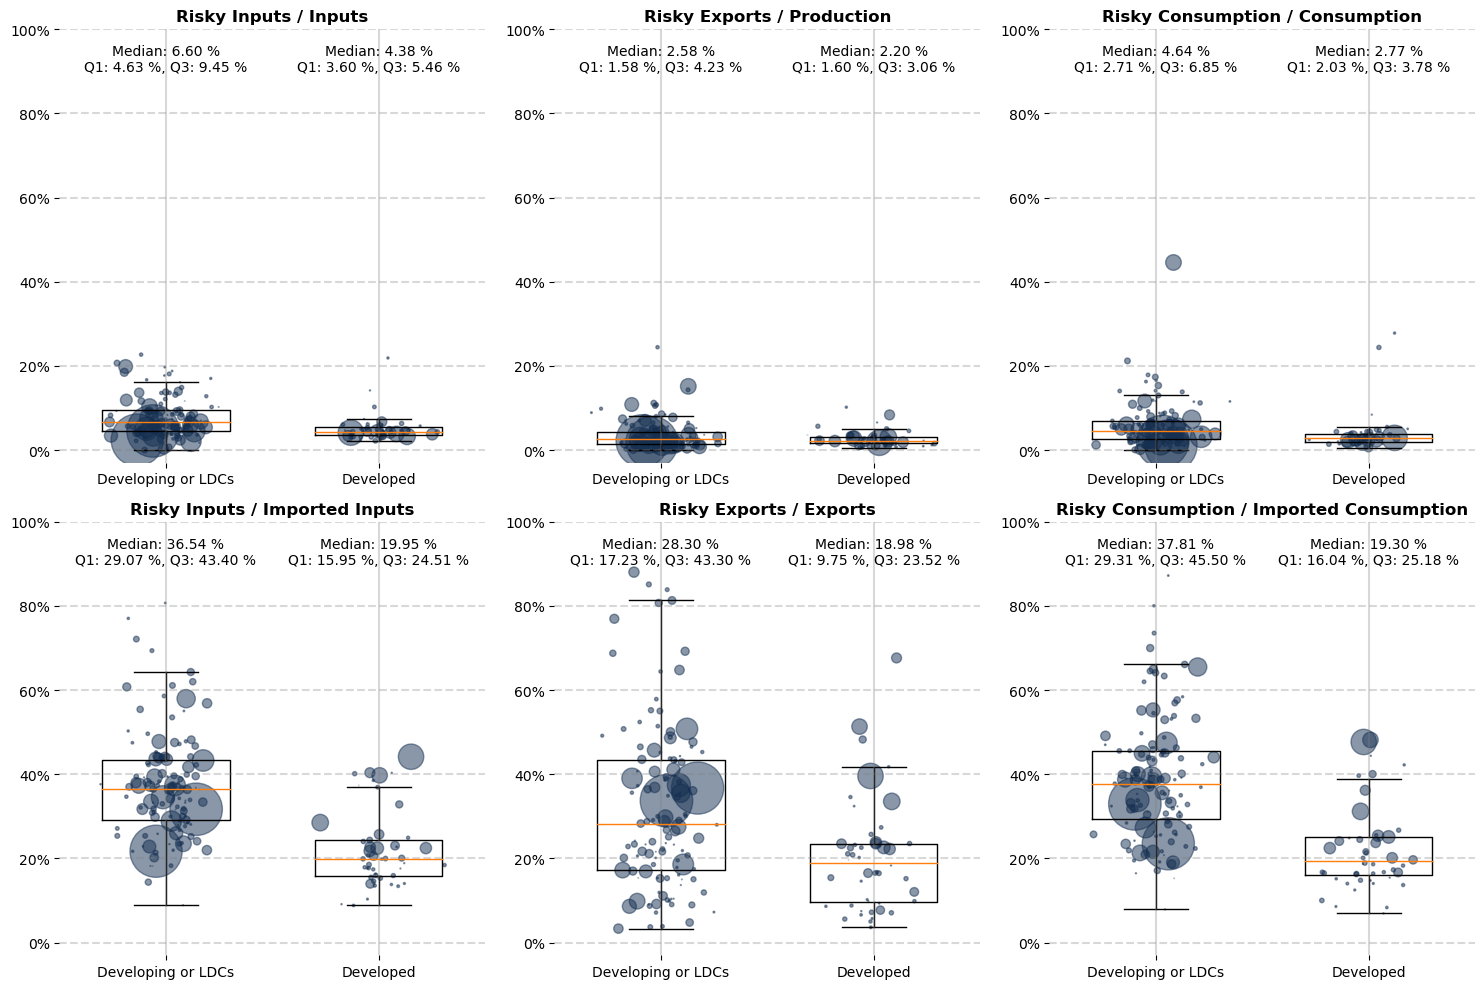

In [14]:
### import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  

elegant_blue = (0.086, 0.188, 0.322)  

resulting_dataframe_country_inputs_leontief =  resulting_dataframe_country_inputs_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_cons_leontief =  resulting_dataframe_country_cons_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_exports_leontief =  resulting_dataframe_country_exports_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
lim=100

###########
# First line First pannel
###########

inputs_leontief_Row = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development']!='Developed']
inputs_leontief_developed = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [inputs_leontief_Row['High Risk'], inputs_leontief_developed['High Risk']]

# Plot the boxplots
axs[0, 0].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = inputs_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = inputs_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(inputs_leontief_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 0].scatter(x_positions_row, inputs_leontief_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(inputs_leontief_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 0].scatter(x_positions_developed, inputs_leontief_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 0].set_title('Risky Inputs / Inputs', fontweight='bold', fontsize=12)

axs[0, 0].set_xlim(0.5, 2.5)
axs[0, 0].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 0].set_xticks([1, 2])
axs[0, 0].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 0].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 0].get_yticks():
    axs[0, 0].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 0].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 0].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)


# Calculate medians and quartiles
median_developed = np.median(inputs_leontief_developed['High Risk'])
q1_developed, q3_developed = np.percentile(inputs_leontief_developed['High Risk'], [25, 75])

median_row = np.median(inputs_leontief_Row['High Risk'])
q1_row, q3_row = np.percentile(inputs_leontief_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,0].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,0].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)


##########
# First Line Second Pannel
##########


exports_leontief_Row = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development']!='Developed']
exports_leontief_developed = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [exports_leontief_Row['High Risk'], exports_leontief_developed['High Risk']]

# Plot the boxplots
axs[0, 1].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = exports_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = exports_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(exports_leontief_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 1].scatter(x_positions_row, exports_leontief_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(exports_leontief_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 1].scatter(x_positions_developed, exports_leontief_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 1].set_title('Risky Exports / Production', fontweight='bold', fontsize=12)

axs[0, 1].set_xlim(0.5, 2.5)
axs[0, 1].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 1].set_xticks([1, 2])
axs[0, 1].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 1].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 1].get_yticks():
    axs[0, 1].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 1].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 1].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 1].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(exports_leontief_developed['High Risk'])
q1_developed, q3_developed = np.percentile(exports_leontief_developed['High Risk'], [25, 75])

median_row = np.median(exports_leontief_Row['High Risk'])
q1_row, q3_row = np.percentile(exports_leontief_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,1].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,1].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

########
# First Third panel
########

conso_leontief_Row = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development']!='Developed']
conso_leontief_developed = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [conso_leontief_Row['High Risk'], conso_leontief_developed['High Risk']]

# Plot the boxplots
axs[0, 2].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = conso_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = conso_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(conso_leontief_Row['High Risk']))  # Adjust the spread as necessary
axs[0, 2].scatter(x_positions_row, conso_leontief_Row['High Risk'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(conso_leontief_developed['High Risk']))  # Adjust the spread as necessary
axs[0, 2].scatter(x_positions_developed, conso_leontief_developed['High Risk'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[0, 2].set_title('Risky Consumption / Consumption', fontweight='bold', fontsize=12)

axs[0, 2].set_xlim(0.5, 2.5)
axs[0, 2].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[0, 2].set_xticks([1, 2])
axs[0, 2].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[0, 2].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[0, 2].get_yticks():
    axs[0, 2].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[0, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[0, 2].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[0, 2].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(conso_leontief_developed['High Risk'])
q1_developed, q3_developed = np.percentile(conso_leontief_developed['High Risk'], [25, 75])

median_row = np.median(conso_leontief_Row['High Risk'])
q1_row, q3_row = np.percentile(conso_leontief_Row['High Risk'], [25, 75])


# Display median and quartiles for x=1
axs[0,2].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[0,2].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

###########
# Second line First pannel
###########

lim=100

inputs_leontief_Row = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development']!='Developed']
inputs_leontief_developed = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [inputs_leontief_Row['High Risk (imports)'], inputs_leontief_developed['High Risk (imports)']]

# Plot the boxplots
axs[1, 0].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = inputs_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = inputs_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(inputs_leontief_Row['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 0].scatter(x_positions_row, inputs_leontief_Row['High Risk (imports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(inputs_leontief_developed['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 0].scatter(x_positions_developed, inputs_leontief_developed['High Risk (imports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 0].set_title('Risky Inputs / Imported Inputs', fontweight='bold', fontsize=12)

axs[1, 0].set_xlim(0.5, 2.5)
axs[1, 0].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 0].set_xticks([1, 2])
axs[1, 0].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 0].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 0].get_yticks():
    axs[1, 0].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 0].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 0].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 0].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 0].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(inputs_leontief_developed['High Risk (imports)'])
q1_developed, q3_developed = np.percentile(inputs_leontief_developed['High Risk (imports)'], [25, 75])

median_row = np.median(inputs_leontief_Row['High Risk (imports)'])
q1_row, q3_row = np.percentile(inputs_leontief_Row['High Risk (imports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,0].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,0].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

##########
# Second line Second Pannel
##########


exports_leontief_Row = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development']!='Developed']
exports_leontief_developed = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [exports_leontief_Row['High Risk (exports)'], exports_leontief_developed['High Risk (exports)']]

# Plot the boxplots
axs[1, 1].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = exports_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = exports_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(exports_leontief_Row['High Risk (exports)']))  # Adjust the spread as necessary
axs[1, 1].scatter(x_positions_row, exports_leontief_Row['High Risk (exports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(exports_leontief_developed['High Risk (exports)']))  # Adjust the spread as necessary
axs[1, 1].scatter(x_positions_developed, exports_leontief_developed['High Risk (exports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 1].set_title('Risky Exports / Exports', fontweight='bold', fontsize=12)

axs[1, 1].set_xlim(0.5, 2.5)
axs[1, 1].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 1].set_xticks([1, 2])
axs[1, 1].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 1].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 1].get_yticks():
    axs[1, 1].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 1].set_yticklabels(['{:.0f}%'.format(y) for y in axs[1, 1].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 1].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 1].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(exports_leontief_developed['High Risk (exports)'])
q1_developed, q3_developed = np.percentile(exports_leontief_developed['High Risk (exports)'], [25, 75])

median_row = np.median(exports_leontief_Row['High Risk (exports)'])
q1_row, q3_row = np.percentile(exports_leontief_Row['High Risk (exports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,1].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,1].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)


########
# Second line Third panel
########
conso_leontief_Row = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development']!='Developed']
conso_leontief_developed = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development']=='Developed']

# Boxplot data preparation
data_for_boxplots = [conso_leontief_Row['High Risk (imports)'], conso_leontief_developed['High Risk (imports)']]

# Plot the boxplots
axs[1, 2].boxplot(data_for_boxplots, positions=[1, 2], widths=0.6,showfliers=False)

# Scale population sizes for point sizes (if you still want to overlay scatter points)
population_sizes_row = conso_leontief_Row['Population (2023)'] / 1000000
population_sizes_developed = conso_leontief_developed['Population (2023)'] / 1000000


# For Row
x_positions_row = np.random.normal(1, 0.1, size=len(conso_leontief_Row['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 2].scatter(x_positions_row, conso_leontief_Row['High Risk (imports)'], s=population_sizes_row, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# For Developed
x_positions_developed = np.random.normal(2, 0.1, size=len(conso_leontief_developed['High Risk (imports)']))  # Adjust the spread as necessary
axs[1, 2].scatter(x_positions_developed, conso_leontief_developed['High Risk (imports)'], s=population_sizes_developed, alpha=0.5, color=elegant_blue)  # Adjust color as needed

# Rest of your customization remains the same
axs[1, 2].set_title('Risky Consumption / Imported Consumption', fontweight='bold', fontsize=12)

axs[1, 2].set_xlim(0.5, 2.5)
axs[1, 2].autoscale(enable=False, axis='y')
axs[1, 2].set_ylim(-3, lim)  # Adjust as needed

# Custom x-axis labels
axs[1, 2].set_xticks([1, 2])
axs[1, 2].set_xticklabels(['Developing or LDCs', 'Developed'])  # Replace with your custom labels

# Remove the frame (black box)
for spine in axs[1, 2].spines.values():
    spine.set_visible(False)

# Add horizontal grey dotted lines
for y_tick in axs[1, 2].get_yticks():
    axs[1, 2].axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)
    
# Set y-axis to display percentages
axs[1, 2].set_yticklabels(['{:.0f}%'.format(y) for y in axs[0, 2].get_yticks()])

# Add vertical grey lines at x=1 and x=2
axs[1, 2].axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
axs[1, 2].axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

# Calculate medians and quartiles
median_developed = np.median(conso_leontief_developed['High Risk (imports)'])
q1_developed, q3_developed = np.percentile(conso_leontief_developed['High Risk (imports)'], [25, 75])

median_row = np.median(conso_leontief_Row['High Risk (imports)'])
q1_row, q3_row = np.percentile(conso_leontief_Row['High Risk (imports)'], [25, 75])


# Display median and quartiles for x=1
axs[1,2].text(1, lim*0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Display median and quartiles for x=2
axs[1,2].text(2, lim*0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %', 
            horizontalalignment='center', color='black', fontsize=10)

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Set labels and title
plt.text(-0.15, 1.45, "The Developed countries are among the least exposed",   transform=axs.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.15, 1.3, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Show the plot
plt.show()


##### Leontieff - Absolute
----

C:\Users\delah\AppData\Local\Temp\ipykernel_18828\85493787.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\85493787.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\85493787.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])


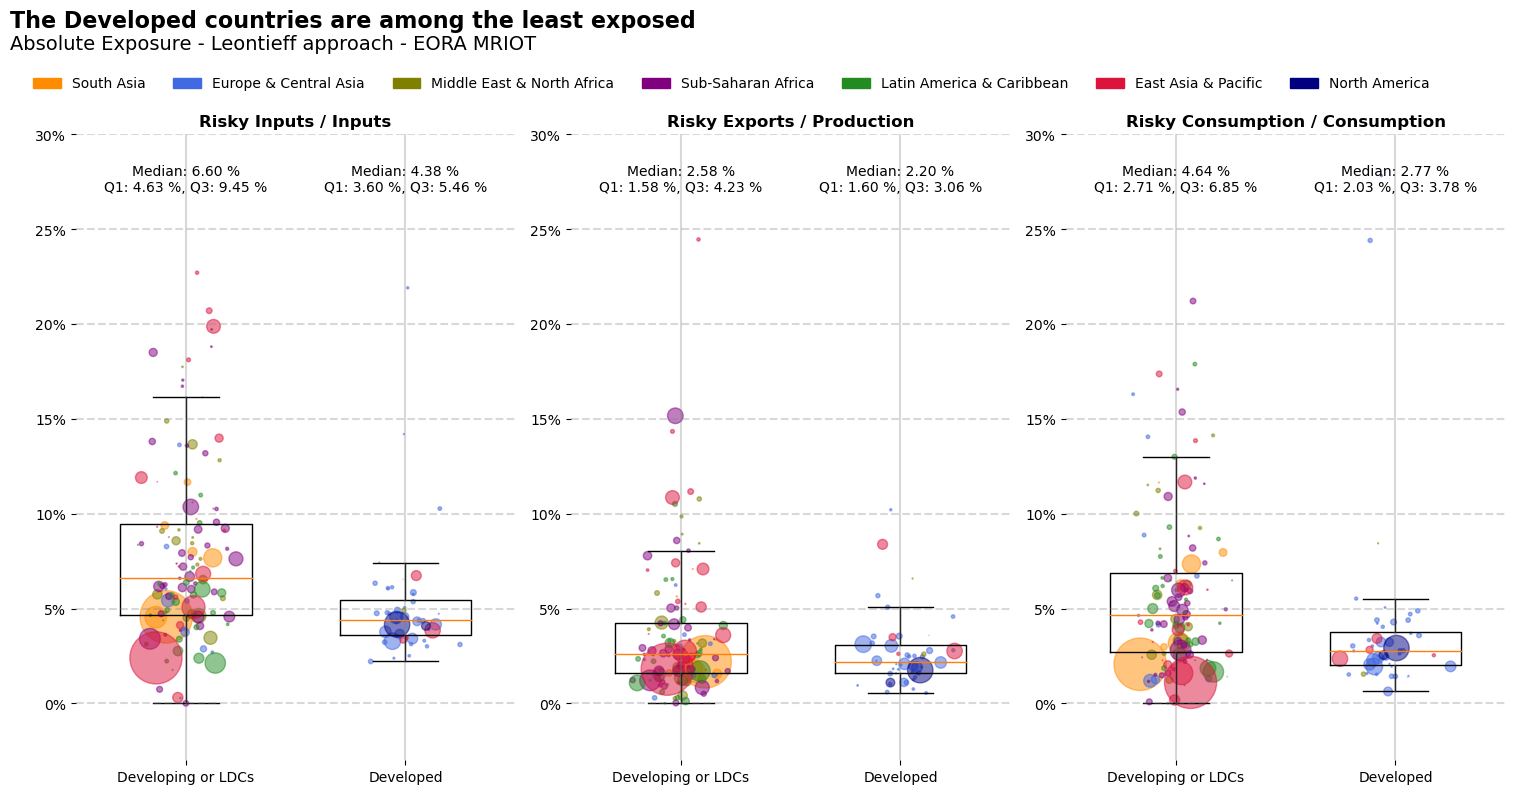

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

fig, axs = plt.subplots(1, 3, figsize=(15, 7))

elegant_blue = (0.086, 0.188, 0.322)

region_colors = {
    'South Asia': 'darkorange',
    'Europe & Central Asia': 'royalblue',
    'Middle East & North Africa': 'olive',
    'Sub-Saharan Africa': 'purple',
    'Latin America & Caribbean': 'forestgreen',
    'East Asia & Pacific': 'crimson',
    'North America': 'navy'
}

# Sort and reset index for dataframes (assuming these dataframes are defined somewhere)
resulting_dataframe_country_inputs_leontief = resulting_dataframe_country_inputs_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_cons_leontief = resulting_dataframe_country_cons_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_exports_leontief = resulting_dataframe_country_exports_leontief.sort_values('Country', ascending=True).reset_index(drop=True)

lim = 30

# Function to plot boxplots, scatter, and customizations
def plot_data(ax, data_row, data_developed, title):
    # Boxplot data preparation
    data_for_boxplots = [data_row['High Risk'], data_developed['High Risk']]

    # Plot the boxplots
    ax.boxplot(data_for_boxplots, positions=[1, 2], widths=0.6, showfliers=False)
    # Update scatter plots to use colors based on region
    for region in region_colors:
        # Filter data for each region
        data_row_region = data_row[data_row['Region'] == region]
        data_developed_region = data_developed[data_developed['Region'] == region]

        # Scale population sizes for point sizes
        population_sizes_row_region = data_row_region['Population (2023)'] / 1000000
        population_sizes_developed_region = data_developed_region['Population (2023)'] / 1000000

        # For Row
        x_positions_row = np.random.normal(1, 0.1, size=len(data_row_region['High Risk']))
        ax.scatter(x_positions_row, data_row_region['High Risk'], s=population_sizes_row_region, alpha=0.5, color=region_colors[region])

        # For Developed
        x_positions_developed = np.random.normal(2, 0.1, size=len(data_developed_region['High Risk']))
        ax.scatter(x_positions_developed, data_developed_region['High Risk'], s=population_sizes_developed_region, alpha=0.5, color=region_colors[region])

    # Rest of your customization remains the same
    ax.set_title(title, fontweight='bold', fontsize=12)

    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(-3, lim)

    # Custom x-axis labels
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Developing or LDCs', 'Developed'])

    # Remove the frame (black box)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add horizontal grey dotted lines
    for y_tick in ax.get_yticks():
        ax.axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)

    # Set y-axis to display percentages
    ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])

    # Add vertical grey lines at x=1 and x=2
    ax.axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
    ax.axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

    # Calculate medians and quartiles
    median_developed = np.median(data_developed['High Risk'])
    q1_developed, q3_developed = np.percentile(data_developed['High Risk'], [25, 75])

    median_row = np.median(data_row['High Risk'])
    q1_row, q3_row = np.percentile(data_row['High Risk'], [25, 75])

    # Display median and quartiles for x=1
    ax.text(1, lim * 0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %',
            horizontalalignment='center', color='black', fontsize=10)

    # Display median and quartiles for x=2
    ax.text(2, lim * 0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %',
            horizontalalignment='center', color='black', fontsize=10)

# First panel
inputs_leontief_Row = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development'] != 'Developed']
inputs_leontief_developed = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development'] == 'Developed']
plot_data(axs[0], inputs_leontief_Row, inputs_leontief_developed, 'Risky Inputs / Inputs')

# Second panel
exports_leontief_Row = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development'] != 'Developed']
exports_leontief_developed = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development'] == 'Developed']
plot_data(axs[1], exports_leontief_Row, exports_leontief_developed, 'Risky Exports / Production')

# Third panel
conso_leontief_Row = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development'] != 'Developed']
conso_leontief_developed = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development'] == 'Developed']
plot_data(axs[2], conso_leontief_Row, conso_leontief_developed, 'Risky Consumption / Consumption')

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Create legend handles
legend_handles = [mpatches.Patch(color=color, label=region) for region, color in region_colors.items()]
# Add legend without a frame and title
plt.figlegend(handles=legend_handles, loc='upper left',ncol=len(region_colors), bbox_to_anchor=(0, 1.05), frameon=False)
ncol=len(region_colors)
# Set labels and title
plt.text(-0.15, 1.2, "The Developed countries are among the least exposed", transform=axs[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(-0.15, 1.16, "Absolute Exposure - Leontieff approach - EORA MRIOT", transform=axs[0].transAxes, fontsize=14, va='top', ha='left')

# Show the plot
plt.show()

##### Leontieff - Relative
-----

C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3512917929.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3512917929.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\3512917929.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])


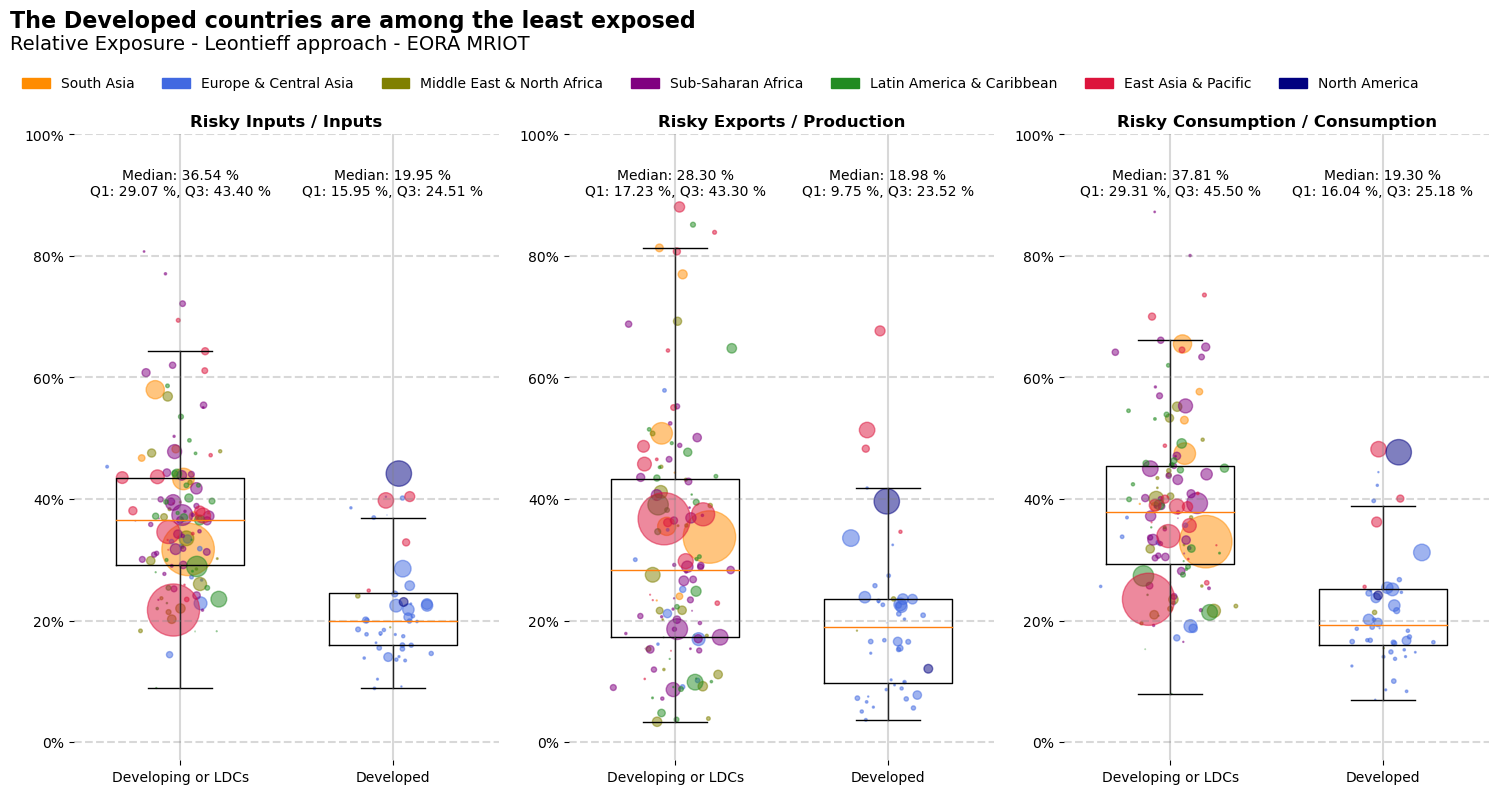

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

fig, axs = plt.subplots(1, 3, figsize=(15, 7))

elegant_blue = (0.086, 0.188, 0.322)

region_colors = {
    'South Asia': 'darkorange',
    'Europe & Central Asia': 'royalblue',
    'Middle East & North Africa': 'olive',
    'Sub-Saharan Africa': 'purple',
    'Latin America & Caribbean': 'forestgreen',
    'East Asia & Pacific': 'crimson',
    'North America': 'navy'
}

# Sort and reset index for dataframes (assuming these dataframes are defined somewhere)
resulting_dataframe_country_inputs_leontief = resulting_dataframe_country_inputs_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_cons_leontief = resulting_dataframe_country_cons_leontief.sort_values('Country', ascending=True).reset_index(drop=True)
resulting_dataframe_country_exports_leontief = resulting_dataframe_country_exports_leontief.sort_values('Country', ascending=True).reset_index(drop=True)

lim = 100

# Function to plot boxplots, scatter, and customizations
def plot_data(ax, data_row, data_developed, title):
    # Boxplot data preparation
    data_for_boxplots = [data_row['High Risk (relative)'], data_developed['High Risk (relative)']]

    # Plot the boxplots
    ax.boxplot(data_for_boxplots, positions=[1, 2], widths=0.6, showfliers=False)
    # Update scatter plots to use colors based on region
    for region in region_colors:
        # Filter data for each region
        data_row_region = data_row[data_row['Region'] == region]
        data_developed_region = data_developed[data_developed['Region'] == region]

        # Scale population sizes for point sizes
        population_sizes_row_region = data_row_region['Population (2023)'] / 1000000
        population_sizes_developed_region = data_developed_region['Population (2023)'] / 1000000

        # For Row
        x_positions_row = np.random.normal(1, 0.1, size=len(data_row_region['High Risk (relative)']))
        ax.scatter(x_positions_row, data_row_region['High Risk (relative)'], s=population_sizes_row_region, alpha=0.5, color=region_colors[region])

        # For Developed
        x_positions_developed = np.random.normal(2, 0.1, size=len(data_developed_region['High Risk (relative)']))
        ax.scatter(x_positions_developed, data_developed_region['High Risk (relative)'], s=population_sizes_developed_region, alpha=0.5, color=region_colors[region])

    # Rest of your customization remains the same
    ax.set_title(title, fontweight='bold', fontsize=12)

    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(-3, lim)

    # Custom x-axis labels
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Developing or LDCs', 'Developed'])

    # Remove the frame (black box)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add horizontal grey dotted lines
    for y_tick in ax.get_yticks():
        ax.axhline(y=y_tick, color='grey', linestyle='--', alpha=0.3)

    # Set y-axis to display percentages
    ax.set_yticklabels(['{:.0f}%'.format(y) for y in ax.get_yticks()])

    # Add vertical grey lines at x=1 and x=2
    ax.axvline(x=1, color='grey', linestyle='solid', alpha=0.3)
    ax.axvline(x=2, color='grey', linestyle='solid', alpha=0.3)

    # Calculate medians and quartiles
    median_developed = np.median(data_developed['High Risk (relative)'])
    q1_developed, q3_developed = np.percentile(data_developed['High Risk (relative)'], [25, 75])

    median_row = np.median(data_row['High Risk (relative)'])
    q1_row, q3_row = np.percentile(data_row['High Risk (relative)'], [25, 75])

    # Display median and quartiles for x=1
    ax.text(1, lim * 0.9, f'Median: {median_row:.2f} %\nQ1: {q1_row:.2f} %, Q3: {q3_row:.2f} %',
            horizontalalignment='center', color='black', fontsize=10)

    # Display median and quartiles for x=2
    ax.text(2, lim * 0.9, f'Median: {median_developed:.2f} %\nQ1: {q1_developed:.2f} %, Q3: {q3_developed:.2f} %',
            horizontalalignment='center', color='black', fontsize=10)

# First panel
inputs_leontief_Row = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development'] != 'Developed']
inputs_leontief_developed = resulting_dataframe_country_inputs_leontief[resulting_dataframe_country_inputs_leontief['Development'] == 'Developed']
plot_data(axs[0], inputs_leontief_Row, inputs_leontief_developed, 'Risky Inputs / Inputs')

# Second panel
exports_leontief_Row = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development'] != 'Developed']
exports_leontief_developed = resulting_dataframe_country_exports_leontief[resulting_dataframe_country_exports_leontief['Development'] == 'Developed']
plot_data(axs[1], exports_leontief_Row, exports_leontief_developed, 'Risky Exports / Production')

# Third panel
conso_leontief_Row = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development'] != 'Developed']
conso_leontief_developed = resulting_dataframe_country_cons_leontief[resulting_dataframe_country_cons_leontief['Development'] == 'Developed']
plot_data(axs[2], conso_leontief_Row, conso_leontief_developed, 'Risky Consumption / Consumption')

# Adjust layout for better spacing (optional)
plt.tight_layout()

# Create legend handles
legend_handles = [mpatches.Patch(color=color, label=region) for region, color in region_colors.items()]
# Add legend without a frame and title
plt.figlegend(handles=legend_handles, loc='upper left',ncol=len(region_colors), bbox_to_anchor=(0, 1.05), frameon=False)
ncol=len(region_colors)

# Set labels and title
plt.text(-0.15, 1.2, "The Developed countries are among the least exposed", transform=axs[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(-0.15, 1.16, "Relative Exposure - Leontieff approach - EORA MRIOT", transform=axs[0].transAxes, fontsize=14, va='top', ha='left')

# Show the plot
plt.show()

# Sector-level analysis
-----

## Inputs
----

In [108]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########    

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)

leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######
index_cs = mriot.x.index

values = {'VLR (%)': [0] * index_cs.size}
Foreign_Inputs_VLR = pd.DataFrame(values, index=index_cs)

values = {'LR (%)': [0] * index_cs.size}
Foreign_Inputs_LR = pd.DataFrame(values, index=index_cs)

values = {'MR (%)': [0] * index_cs.size}
Foreign_Inputs_MR = pd.DataFrame(values, index=index_cs)

values = {'HR (%)': [0] * index_cs.size}
Foreign_Inputs_HR = pd.DataFrame(values, index=index_cs)

values = {'VHR (%)': [0] * index_cs.size}
Foreign_Inputs_VHR = pd.DataFrame(values, index=index_cs)

values = {'ROW (%)': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)


# Foreign_GO
######

for s in sector_list:    
    for c in country_list:
        leontieff_cs = leontieff[c,s]
        final_production_cs = final_production[c,s]
        leontieff_cs_local = leontieff_cs[leontieff_cs.index.get_level_values('region').isin([c])]
        leontieff_cs_foreign = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c])]
        leontieff_cs_foreign_VLR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VLR_list_MRIOT)]
        leontieff_cs_foreign_LR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(LR_list_MRIOT)]
        leontieff_cs_foreign_MR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(MR_list_MRIOT)]
        leontieff_cs_foreign_HR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(HR_list_MRIOT)]
        leontieff_cs_foreign_VHR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(VHR_list_MRIOT)]
        leontieff_cs_foreign_ROW = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(['ROW'])]

        intrants_cs = (leontieff_cs*final_production_cs).sum()
        
        if intrants_cs != 0 :
            Foreign_Inputs.loc[c,s]=(leontieff_cs_foreign*final_production_cs).sum() / intrants_cs*100
            Local_Inputs.loc[c,s] = (leontieff_cs_local*final_production_cs).sum() / intrants_cs*100
            Foreign_Inputs_VLR.loc[c,s] = (leontieff_cs_foreign_VLR*final_production_cs).sum() / intrants_cs*100
            Foreign_Inputs_LR.loc[c,s] = (leontieff_cs_foreign_LR*final_production_cs).sum() / intrants_cs *100
            Foreign_Inputs_MR.loc[c,s] = (leontieff_cs_foreign_MR*final_production_cs).sum() / intrants_cs *100
            Foreign_Inputs_HR.loc[c,s] = (leontieff_cs_foreign_HR*final_production_cs).sum() / intrants_cs*100
            Foreign_Inputs_VHR.loc[c,s] = (leontieff_cs_foreign_VHR*final_production_cs).sum() / intrants_cs *100
            Foreign_Inputs_ROW.loc[c,s] = (leontieff_cs_foreign_ROW*final_production_cs).sum() / intrants_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_VLR, Foreign_Inputs_LR, Foreign_Inputs_MR, Foreign_Inputs_HR, Foreign_Inputs_VHR, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Assuming your DataFrame is named df
result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

#result = result.sort_values('High Risk', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in VLR_list_MRIOT:
        return 'Low Risk'
    elif region in LR_list_MRIOT:
        return 'Low Risk'
    elif region in MR_list_MRIOT:
        return 'High Risk'
    elif region in HR_list_MRIOT:
        return 'High Risk'
    elif region in VHR_list_MRIOT:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
result = result[['Country','sector','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'VLR (%)', 'LR (%)','MR (%)','HR (%)','VHR (%)','ROW (%)','Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_sectors_inputs_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_6532\670979563.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.3745746982097082' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]=(leontieff_cs_foreign*final_production_cs).sum() / intrants_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_6532\670979563.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '96.62542530179029' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = (leontieff_cs_local*final_production_cs).sum() / intrants_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_6532\670979563.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.568883819853049' has dtype incompatible with int6

Number of outliers: 144
Outlier values: [40.111798551774974, 35.45929622846211, 36.85702620649858, 35.51934266887171, 34.98360506037399, 32.92694993992883, 35.49400298922639, 32.529796845769525, 33.73212047554275, 32.881796956128376, 31.788939316647493, 32.09943618403177, 33.683381983508184, 31.680402855497817, 40.44860131043004, 16.733084705877104, 31.44369593703299, 33.01965774081829, 33.07486545477536, 29.562351271491544, 18.813122453384768, 29.742631902171475, 28.86825968694424, 37.70626672763733, 33.10582719781096, 38.76126299678008, 27.499642240923055, 16.256949862283374, 28.87214129769882, 29.38915372918307, 30.67710965315365, 29.184270908789266, 30.48815193977314, 30.193278224547786, 38.72048234658425, 27.241261084204915, 27.241261592645067, 28.67496971405584, 31.58096065638389, 29.803105706799737, 15.630055134527352, 38.41745210123991, 27.76974490650769, 29.247724453695316, 27.69162031136598, 31.288042683981175, 38.26059302736351, 30.684715198115068, 34.23021229966443, 28.6909

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


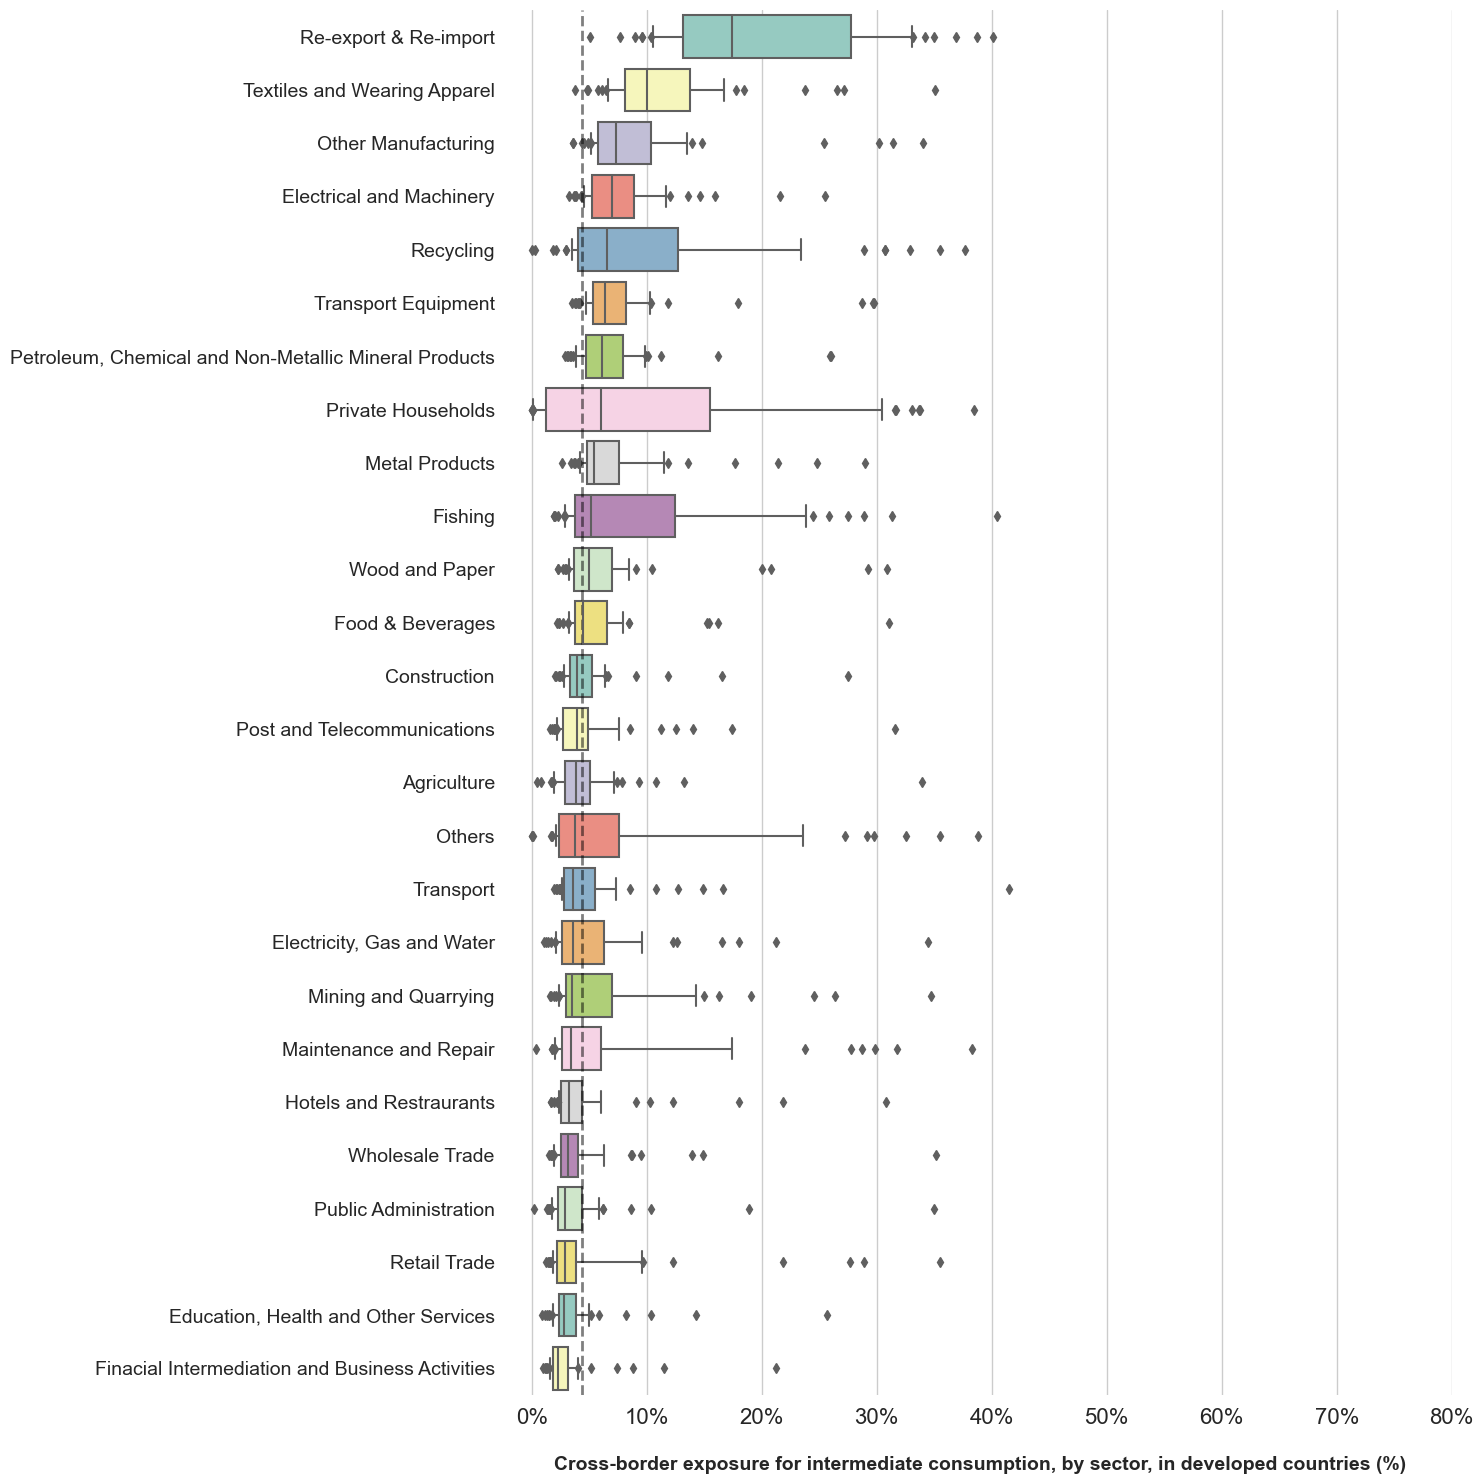

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_inputs_leontief

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk'].quantile(0.25)
Q3 = df_developed['High Risk'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk'].tolist())

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_inputs, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for intermediate consumption, by sector, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\D\Fig2b.png")
plt.show()

## Exports 
----

In [64]:
# Calcul de la final production
####################

# Il s'agit d'avoir pour chaque industrie (= couple region x secteur) la production finale (qu'elle soit à destinée à la consommation finale / investissement, etc. finaux ou étrangers).

import pandas as pd

final_production = mriot.Y.copy()

# Calcul de la final production, tout usage confondus
##########

final_production_by_use = mriot.Y.copy()
gross_output = mriot.x
final_production = final_production_by_use.sum(axis = 1)
final_production_by_destination = final_production_by_use.groupby(level=0, axis=1).sum()


leontieff= mriot.L

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()

# Répartition des intrants par origine
######

values = {'VLR (%)': [0] * sector_list.size}
sExport_VLR = pd.DataFrame(values, index=sector_list)

values = {'LR (%)': [0] * sector_list.size}
sExport_LR = pd.DataFrame(values, index=sector_list)

values = {'MR (%)': [0] * sector_list.size}
sExport_MR = pd.DataFrame(values, index=sector_list)

values = {'HR (%)': [0] * sector_list.size}
sExport_HR = pd.DataFrame(values, index=sector_list)

values = {'VHR (%)': [0] * sector_list.size}
sExport_VHR = pd.DataFrame(values, index=sector_list)

values = {'ROW (%)': [0] * sector_list.size}
sExport_ROW = pd.DataFrame(values, index=sector_list)


# Foreign_GO
######


for s in sector_list:
    export_s = 0
    export_s_VLR = 0
    export_s_LR = 0
    export_s_MR = 0
    export_s_HR = 0
    export_s_VHR = 0
    export_s_ROW = 0
    
    for c in country_list:
        export_s=export_s + final_production[c,s]-final_production_by_destination[c].loc[c,s] #Exports for final use
        export_s=export_s + mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum() #Exports for Intermediary Consumption
        if c in VLR_list_MRIOT:
            export_s_VLR = export_s_VLR +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_VLR = export_s_VLR +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()
        if c in LR_list_MRIOT:
            export_s_LR = export_s_LR +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_LR = export_s_LR +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()
        if c in MR_list_MRIOT:
            export_s_MR = export_s_MR +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_MR = export_s_MR +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()
        if c in HR_list_MRIOT:
            export_s_HR = export_s_HR +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_HR = export_s_HR +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()
        if c in VHR_list_MRIOT:
            export_s_VHR = export_s_VHR +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_VHR = export_s_VHR +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()
        if c == 'ROW':
            export_s_ROW = export_s_ROW +final_production[c,s]-final_production_by_destination[c].loc[c,s]
            export_s_ROW = export_s_ROW +mriot.Z.loc[c,s].sum()-mriot.Z.loc[c,s][c].sum()


    sExport_VLR.loc[s] = export_s_VLR / export_s*100
    sExport_LR.loc[s] = export_s_LR / export_s *100
    sExport_MR.loc[s] = export_s_MR / export_s *100
    sExport_HR.loc[s] = export_s_HR / export_s*100
    sExport_VHR.loc[s] = export_s_VHR / export_s *100
    sExport_ROW.loc[s] = export_s_ROW / export_s*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [sExport_VLR, sExport_LR, sExport_MR, sExport_HR, sExport_VHR, sExport_ROW]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe = pd.concat(dataframes_to_concat, axis=1)

C:\Users\delah\AppData\Local\Temp\ipykernel_18828\2732465453.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = final_production_by_use.groupby(level=0, axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\2732465453.py:82: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9.089698383057652' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sExport_VLR.loc[s] = export_s_VLR / export_s*100
C:\Users\delah\AppData\Local\Temp\ipykernel_18828\2732465453.py:83: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '42.049653974925135' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sExport_LR.loc[s] = export_s_LR / export_s *100
C:\Users\delah\AppData\Local\Temp\ipykernel_188

## Consumption

In [278]:
import pandas as pd

# Example high_risk_list and low_risk_list
high_risk_list=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
low_risk_list=LR_list_MRIOT+VLR_list_MRIOT

# Assuming 'mriot.L' and other necessary DataFrames are defined
leontieff = mriot.L
final_production = mriot.Y.sum(axis=1)  # Sum over all uses

# Group by region in production DataFrame if it's multi-level
final_production_by_destination = mriot.Y.copy().groupby(level='region', axis=1).sum()

# Initialize DataFrame for risks
index_cs = leontieff.index
values = {'Low Risk (%)': [0] * index_cs.size, 'High Risk (%)': [0] * index_cs.size}
risk_cs = pd.DataFrame(values, index=index_cs)

for c in leontieff.index.get_level_values(0).unique():
    for s in leontieff.index.get_level_values(1).unique():
        leontieff_cs = leontieff[c, s]

        # Select data for foreign inputs, categorized by risk
        leontieff_cs_foreign_local_low = leontieff_cs[leontieff_cs.index.get_level_values('region').isin(low_risk_list)]
        leontieff_cs_foreign_local_high = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin(low_risk_list)]
        final_production_cs = final_production[c, s]

        # Compute total inputs and by risk category
        total_inputs = (leontieff_cs * final_production_cs).sum()
        inputs_low_risk = (leontieff_cs_foreign_local_low * final_production_cs).sum()
        inputs_high_risk = (leontieff_cs_foreign_local_high * final_production_cs).sum()

        # Assign to DataFrame
        if c in low_risk_list:
            risk_cs.loc[(c, s), 'Low Risk (%)'] = (inputs_low_risk+final_production_cs) / (total_inputs+final_production_cs)*100
            risk_cs.loc[(c, s), 'High Risk (%)'] =  inputs_high_risk / (total_inputs+final_production_cs)*100
        else:
            risk_cs.loc[(c, s), 'Low Risk (%)'] = inputs_low_risk / (total_inputs+final_production_cs) *100
            risk_cs.loc[(c, s), 'High Risk (%)'] = (inputs_high_risk+final_production_cs) / (total_inputs+final_production_cs)*100

# Replace NaN with zeros and concatenate along columns
risk_cs.fillna(0, inplace=True)

C:\Users\delah\AppData\Local\Temp\ipykernel_15168\501719170.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = mriot.Y.copy().groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\501719170.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.1399657743659461' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs.loc[(c, s), 'Low Risk (%)'] = inputs_low_risk / (total_inputs+final_production_cs) *100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\501719170.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '98.86003422563405' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs.loc[(c, s), 'High Risk (%)'] = (inputs_high_r

In [310]:
# Pour chaque pays, quelle pondération de la consommation finale ?
####

index_cs = leontieff.index

# Assuming 'mriot.L' and other necessary DataFrames are defined
leontieff = mriot.L
final_production = mriot.Y.sum(axis=1)  # Sum over all uses

df = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'Household final consumption P.3h',
    'Non-profit institutions serving households P.3n',
    'Government final consumption P.3g','Gross fixed capital formation P.51','Acquisitions less disposals of valuables P.53'
]

# Filtering to get only columns where the second level matches the categories listed
filtered_df = df.loc[:, idx[:, categories_to_keep]]

final_production_by_destination_cons = filtered_df.groupby(level='region', axis=1).sum()

ConsoFin = final_production_by_destination_cons[c]
ConsoFin_tot=ConsoFin.groupby('sector').sum()

country_list = leontieff.index.get_level_values(0).unique()
sector_list = leontieff.index.get_level_values(1).unique()


values = {'Low Risk': [0] * index_cs.size}
ConsoFin_Low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
ConsoFin_High = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
ConsoFin_Foreign = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
ConsoFin_Local = pd.DataFrame(values, index=index_cs)

for c in ['SRB']:
    ConsoFin = final_production_by_destination_cons[c]
    ConsoFin_tot=ConsoFin.groupby('sector').sum()
    country_list_except = [x for x in country_list if x != c]
    for s in ['Metal Products']:
        if ConsoFin_tot.loc[s]>0:
            for cc in country_list_except:
                ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[(cc, s), 'Low Risk (%)']/100
                ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[(cc, s), 'High Risk (%)']/100
            ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_Foreign.loc[c,s] = ConsoFin_Low.loc[c,s].iloc[0] + ConsoFin_High.loc[c,s].iloc[0]
            ConsoFin_Local.loc[c,s] = 100 - ConsoFin_Foreign.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [ConsoFin_Low, ConsoFin_High, ConsoFin_Foreign, ConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1
resulting_dataframe_sectors_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
#result = result.sort_values('High Risk', ascending=False).reset_index()
result = resulting_dataframe_sectors_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()


C:\Users\delah\AppData\Local\Temp\ipykernel_15168\868942251.py:22: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = filtered_df.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\868942251.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '6.606889343615231' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[(cc, s), 'Low Risk (%)']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\868942251.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '44.607100656384766' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.lo

In [280]:

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_list:
        return 'Low Risk'
    elif region in high_risk_list:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')

# Replace the 'region' column with the 'name' column
result['region'] = result['name']

notes = Climate_Risk_INFORMCC.copy()
notes = notes.drop(columns=['INFORM  2022','INFORM 2050 Optimistic','INFORM 2080 Pessimistic','INFORM 2080 Optimistic'])

# Initialize an empty dictionary
country_mapping = {}

# Use the replace method to change the values in the "Country" column
for index, row in iso_convert.iterrows():
    country_name = row['name']
    alpha_2_code = row['alpha-2']
    country_mapping[alpha_2_code] = country_name
    #print(f"Mapping {country_name} to {alpha_2_code}")

# Perform a left join based on columns 'A' and 'B'
result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
result= result.drop(columns=['Country'])

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

path='C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path)  # Try 'latin1' or 'ISO-8859-1'
result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','Country Code','Country Name','Lending category','Economy','Code'])
result.rename(columns={'region':'Country','2023 [YR2023]':'Population (2023)'},inplace=True)

# Convert the column to numeric
result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
result = result.dropna(subset=['INDEX 2050 Pessimistic'])
# Drop the unnecessary columns (alpha-2 and alpha-3)
result.drop(['name', 'alpha-2', 'alpha-3'], axis=1, inplace=True)
# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result = result[result['Local Risk'] != 'Unknown']

result['High Risk (relative)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

# Reorder columns
#result = result[['Country','sector','Local Risk','INDEX 2050 Pessimistic', 'Change in Risk','Region','Income group','Population (2023)','Development', 'Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

resulting_dataframe_sectors_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_15168\28789378.py:23: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = filtered_df.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\28789378.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '76.04608833459356' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[(cc, s), 'Low Risk (%)']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_15168\28789378.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.19390166540644596' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.loc[

In [281]:
resulting_dataframe_sectors_cons_leontief.sort_values('High Risk', ascending=False).reset_index().iloc[0:100]


,index,Country,sector,Low Risk,High Risk,Foreign (%),Local (%),Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,High Risk (relative)
0,0,Serbia,Metal Products,3263.337021,1953.569502,5216.906523,-5116.906523,Low Risk,2.7,0.3,Europe & Central Asia,Upper middle income,6699916.0,Developed,37.446895
1,1,Madagascar,Metal Products,789.198887,852.405825,1641.604711,-1541.604711,High Risk,5.7,0.5,Sub-Saharan Africa,Low income,30325732.0,Least Developed,51.925157
2,8,Eswatini,Metal Products,38.938286,286.662443,325.600729,-225.600729,High Risk,3.5,0.2,Sub-Saharan Africa,Lower middle income,1210822.0,Developing,88.041094
3,4,Viet Nam,Other Manufacturing,184.323512,256.527523,440.851035,-340.851035,High Risk,3.8,0.1,East Asia & Pacific,Lower middle income,98858950.0,Developing,58.189162
4,2,Bhutan,Metal Products,312.594946,252.805262,565.400208,-465.400208,Low Risk,3.3,0.1,South Asia,Lower middle income,787424.0,Least Developed,44.712623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,788,Japan,Textiles and Wearing Apparel,14.780777,60.569090,75.349866,24.650134,Low Risk,2.3,0.0,East Asia & Pacific,High income,124389416.0,Developed,80.383805
96,814,Namibia,Other Manufacturing,13.306445,60.532709,73.839154,26.160846,High Risk,3.7,0.5,Sub-Saharan Africa,Upper middle income,2604172.0,Developing,81.979147
97,579,Sri Lanka,Maintenance and Repair,29.107195,60.487378,89.594572,10.405428,High Risk,3.6,0.2,South Asia,Lower middle income,22241304.0,Developing,67.512324
98,871,Namibia,Metal Products,9.994454,60.009592,70.004046,29.995954,High Risk,3.7,0.5,Sub-Saharan Africa,Upper middle income,2604172.0,Developing,85.723034


In [13]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_sectors_cons_leontief_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_sectors_cons_leontief, f)

In [150]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_sectors_cons_leontief_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_cons_leontief = pickle.load(f)

In [502]:
df = resulting_dataframe_sectors_cons_leontief

# List of row indices to be removed
#indices_to_remove = [630, 2709, 3454, 3714, 3974, 4304, 4306, 4590, 5028]

# Drop the specified rows from the DataFrame
#df = df.drop(indices_to_remove)

# Split the data
df_developed = df[df['Development'] == 'Developed']
df_developed.sort_values('High Risk', ascending=False).reset_index().iloc[0:100]

,index,Country,sector,Low Risk,High Risk,Foreign (%),Local (%),Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,High Risk (relative)
0,197,Russian Federation,Public Administration,10.697828,89.287332,99.985160,0.014840,Low Risk,3.3,0.0,Europe & Central Asia,Upper middle income,143036336.0,Developed,89.300585
1,95,Sweden,Retail Trade,17.168903,82.830251,99.999154,0.000846,Low Risk,1.9,0.1,Europe & Central Asia,High income,10544776.0,Developed,82.830952
2,459,Denmark,Recycling,17.737469,81.378754,99.116223,0.883777,Low Risk,1.5,0.1,Europe & Central Asia,High income,5928585.0,Developed,82.104374
3,126,Sweden,Wholesale Trade,19.147112,80.850618,99.997729,0.002271,Low Risk,1.9,0.1,Europe & Central Asia,High income,10544776.0,Developed,80.852454
4,676,San Marino,Transport,9.963802,78.901730,88.865532,11.134468,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,88.787776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,749,Serbia,Maintenance and Repair,46.727194,37.929561,84.656755,15.343245,Low Risk,2.7,0.3,Europe & Central Asia,Upper middle income,6699916.0,Developed,44.803939
96,515,"Moldova, Republic of",Metal Products,59.711505,37.870056,97.581560,2.418440,Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,38.808619
97,445,Belarus,Agriculture,61.730854,37.587782,99.318636,0.681364,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,37.845649
98,527,Belarus,Construction,59.510625,37.559258,97.069883,2.930117,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,38.693008


In [521]:
public_administration_data = mriot.Y['RUS'].xs('Public Administration', level='sector')
public_administration_data.T.sum().loc['RUS']

1.6723762999999998

Number of outliers: 129
Outlier values: [1953.5695017645378, 41.35026500390766, 145.58737235414443, 39.38570638927104, 97.60706353015921, 49.92698512766559, 57.14128212566267, 36.70668008497948, 67.89382442749718, 42.889538306602134, 79.82810844425657, 65.34277902467447, 57.16337046498469, 78.32402202451179, 68.24741110803308, 66.80416224658292, 76.80195031032342, 79.23864047386459, 73.88538269387726, 75.58070618596189, 47.84581126179282, 47.724893123331796, 69.50798395727945, 32.29125894307198, 49.29803609723524, 41.43239320103619, 67.74771644366872, 38.529197624749564, 55.67343304303031, 41.99644001398317, 79.61074100956502, 34.3072098179321, 55.08550400612662, 55.40894815342672, 32.08636616350006, 32.058651199238206, 58.79029245173481, 53.07050890206325, 41.78290753517559, 38.780819522690265, 38.20722155492136, 74.87399029224576, 57.435646773332294, 39.936869171121344, 40.425449800751245, 54.83522176249792, 39.72917246096404, 34.72674157269794, 34.96931464487298, 41.72819771891306, 

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


NameError: name 'median_high_risk_developed_consumption' is not defined

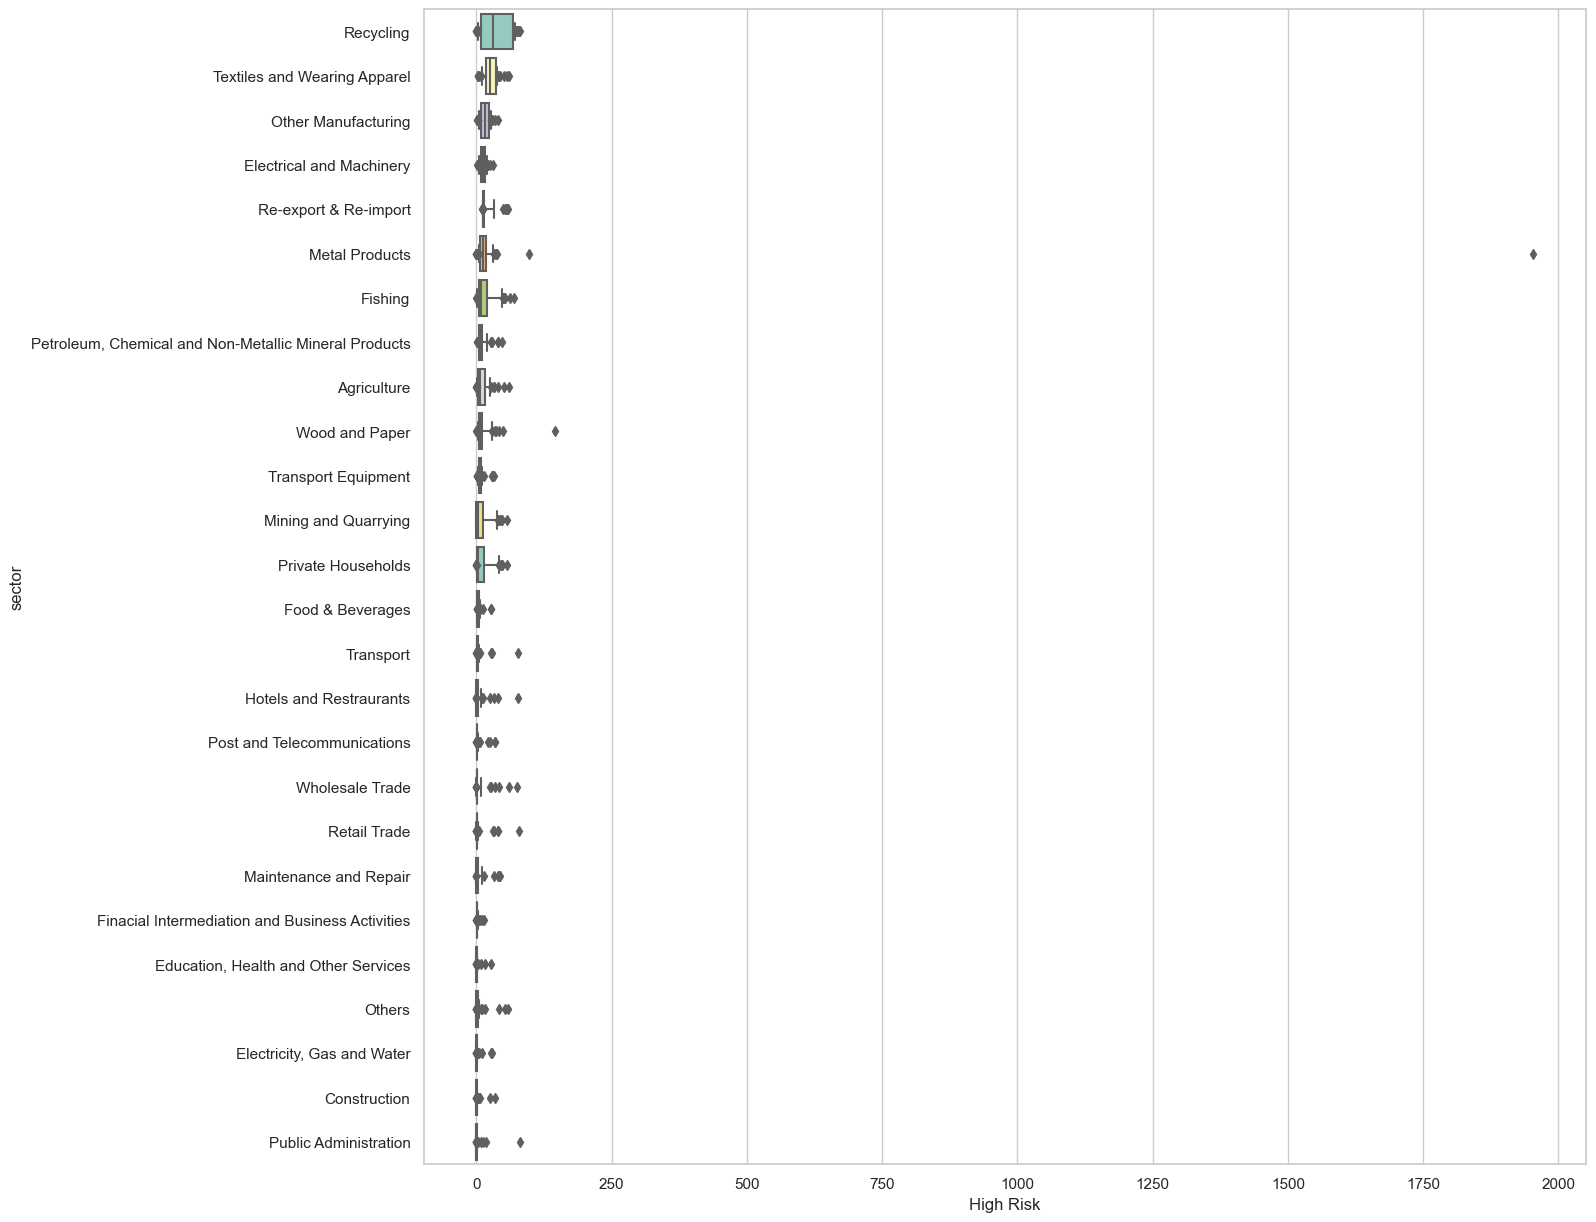

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_cons_leontief

# List of row indices to be removed
#indices_to_remove = [630, 2709, 3454, 3714, 3974, 4304, 4306, 4590, 5028]

# Drop the specified rows from the DataFrame
#df = df.drop(indices_to_remove)

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk'].quantile(0.25)
Q3 = df_developed['High Risk'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk'].tolist())

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])

# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_consumption, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 100, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for final consumption, by sector, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\D\Fig1b.png")
plt.show()

In [490]:
df_developed.sort_values('High Risk', ascending=False).reset_index().iloc[:100]

,index,Country,sector,Low Risk,High Risk,Foreign (%),Local (%),Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,High Risk (relative)
0,197,Russian Federation,Public Administration,10.697828,89.287332,99.985160,0.014840,Low Risk,3.3,0.0,Europe & Central Asia,Upper middle income,143036336.0,Developed,89.300585
1,95,Sweden,Retail Trade,17.168903,82.830251,99.999154,0.000846,Low Risk,1.9,0.1,Europe & Central Asia,High income,10544776.0,Developed,82.830952
2,459,Denmark,Recycling,17.737469,81.378754,99.116223,0.883777,Low Risk,1.5,0.1,Europe & Central Asia,High income,5928585.0,Developed,82.104374
3,126,Sweden,Wholesale Trade,19.147112,80.850618,99.997729,0.002271,Low Risk,1.9,0.1,Europe & Central Asia,High income,10544776.0,Developed,80.852454
4,676,San Marino,Transport,9.963802,78.901730,88.865532,11.134468,Low Risk,2.7,0.2,Europe & Central Asia,High income,33642.0,Developed,88.787776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,749,Serbia,Maintenance and Repair,46.727194,37.929561,84.656755,15.343245,Low Risk,2.7,0.3,Europe & Central Asia,Upper middle income,6699916.0,Developed,44.803939
96,515,"Moldova, Republic of",Metal Products,59.711505,37.870056,97.581560,2.418440,Low Risk,2.6,0.3,Europe & Central Asia,Upper middle income,2464653.0,Developed,38.808619
97,445,Belarus,Agriculture,61.730854,37.587782,99.318636,0.681364,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,37.845649
98,527,Belarus,Construction,59.510625,37.559258,97.069883,2.930117,Low Risk,1.6,0.2,Europe & Central Asia,Upper middle income,9167767.0,Developed,38.693008


In [52]:
import pandas as pd

# Assuming 'resulting_dataframe_sectors_cons_leontief' is your DataFrame
# Load your DataFrame as df or ensure it's already loaded
df = resulting_dataframe_sectors_cons_leontief

# Filter to find rows where 'High Risk' is greater than 100%
high_risk_over_100 = df[df['High Risk'] > 100]

# Display the rows where 'High Risk' exceeds 100%
high_risk_over_100

,Country,sector,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
630,Bhutan,Metal Products,Low Risk,3.3,0.1,South Asia,Lower middle income,787424.0,Least Developed,84.535278,228.059668,165.231163,74.475920,10.622334,0,NaN,NaN,312.594946,250.329418,44.469459
2709,Madagascar,Metal Products,High Risk,5.7,0.5,Sub-Saharan Africa,Low income,30325732.0,Least Developed,130.596391,658.602496,676.649083,166.954163,6.866854,0,NaN,NaN,789.198887,850.470099,51.868402
3454,Oman,Fishing,Low Risk,2.6,0.2,Middle East & North Africa,High income,4644384.0,Developing,143.973281,83.680158,46.768260,166.792326,22.862677,0,NaN,NaN,227.653439,236.423264,50.944868
3714,"Korea, Republic of",Wood and Paper,Low Risk,2.1,0.0,East Asia & Pacific,High income,51559476.0,Developed,40.685221,146.234719,138.642814,6.539109,0.376577,0,NaN,NaN,186.919940,145.558500,43.779831
3974,Serbia,Metal Products,Low Risk,2.7,0.3,Europe & Central Asia,Upper middle income,6699916.0,Developed,891.113353,2372.223668,1320.434741,522.556145,84.955200,0,NaN,NaN,3263.337021,1927.946085,37.138142
4304,Eswatini,Wood and Paper,High Risk,3.5,0.2,Sub-Saharan Africa,Lower middle income,1210822.0,Developing,7.199138,17.352334,142.834329,2.996081,0.898877,0,NaN,NaN,24.551472,146.729287,85.665949
4306,Eswatini,Metal Products,High Risk,3.5,0.2,Sub-Saharan Africa,Lower middle income,1210822.0,Developing,8.250225,30.688061,279.285658,5.783366,1.322898,0,NaN,NaN,38.938286,286.391921,88.031150
4590,Turkey,Recycling,High Risk,4.9,0.0,Europe & Central Asia,Upper middle income,85816199.0,Developing,8.292655,44.532955,121.580252,37.719223,0.322764,0,NaN,NaN,52.825610,159.622238,75.134787
5028,Viet Nam,Other Manufacturing,High Risk,3.8,0.1,East Asia & Pacific,Lower middle income,98858950.0,Developing,33.695899,150.627613,201.739382,53.730645,0.771486,0,NaN,NaN,184.323512,256.241514,58.162019


In [55]:
df = resulting_dataframe_sectors_cons_leontief

# Filter to find rows where 'High Risk' is greater than 100%
df[df['Country'] == "France"]

,Country,sector,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
1656,France,Agriculture,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,2.264848,14.384678,6.370896,6.626575,2.169699,0,NaN,NaN,16.649526,15.167170,47.670475
1657,France,Fishing,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,14.125320,26.859238,3.871456,1.741843,0.277955,0,NaN,NaN,40.984558,5.891254,12.567791
1658,France,Mining and Quarrying,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,12.731245,78.847472,30.169740,26.526851,0.404492,0,NaN,NaN,91.578717,57.101083,38.405407
1659,France,Food & Beverages,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,3.050577,10.225039,2.130836,1.041073,0.038049,0,NaN,NaN,13.275616,3.209958,19.471317
1660,France,Textiles and Wearing Apparel,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,7.483501,26.717101,24.854376,5.358176,0.081412,0,NaN,NaN,34.200603,30.293964,46.971343
1661,France,Wood and Paper,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,14.414559,35.924416,8.066682,2.163630,0.095827,0,NaN,NaN,50.338974,10.326139,17.021544
1662,France,"Petroleum, Chemical and Non-Metallic Mineral P...",Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,5.748151,26.047388,4.094601,1.552734,0.163612,0,NaN,NaN,31.795539,5.810947,15.451981
1663,France,Metal Products,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,1.996037,7.164712,3.241205,0.546565,0.011231,0,NaN,NaN,9.160748,3.799001,29.313847
1664,France,Electrical and Machinery,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,13.171368,34.576261,12.371542,1.458105,0.043037,0,NaN,NaN,47.747629,13.872683,22.513166
1665,France,Transport Equipment,Low Risk,2.6,0.2,Europe & Central Asia,High income,68059744.0,Developed,6.164503,30.844005,2.763618,0.555996,0.044293,0,NaN,NaN,37.008508,3.363907,8.332191


# Sensitivity Analysis

We are looking to generate two lists : low climate risk and high climate risk.

There are two ways of comparing graphs : (i) through a specific metric taken out of the graph, (ii) by comparing main graph with the sentisitivity analysis graph.

## Threshold function

In the data, EORA has 189. For a list, see : https://worldmrio.com/metadata.jsp.

In the data, INFROM CC Index has 191 countries.

It appears that these countries in EORA do not have an INFORM CCI : 
- ABW - Aruba
- AND - Andorra
- TWN - Taiwan (Officially known as the Republic of China)
- PYF - French Polynesia
- GRL - Greenland
- BMU - Bermuda
- CYM - Cayman Islands
- MCO - Monaco
- VGB - Virgin Islands
- MAC - Macau
- SMR - San Marino
- HKG - Hong Kong
- NCL - New Caledonia
- ANT - Netherlands Antillas (do not exist anymore, since 2010)
- USR - USSR ?

ANT and USR (USSR ?) do not exist any more and are discarded.

We choose to link Taiwan, Hong Kong et Macau to China's risk, Andorra, Monaco to France's, Saint Marin to Italy's.

We choose to discard Aruba,French Polynesia,Greenland,Bermuda,Cayman Islands,Virgin Islands,New Caledonia because we do not have a risk index for them. 

EORA has then 180 countries.

In [6]:
#########
## Importing INFORM CCI Data
#########

import pandas as pd

file_path = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Indices/INFORM_Climate_Change_Index/InformCC_usable.xlsx'
Climate_Risk_INFORMCC = pd.read_excel(file_path)
# Replace NaN values in the 'Country' column with "NA"
Climate_Risk_INFORMCC['Country'].fillna("NA", inplace=True)
# Calculate the difference and add it as a new column
Climate_Risk_INFORMCC['Change in Risk'] = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']-Climate_Risk_INFORMCC['INFORM  2022']
# Add risk index for countries that are in EORA, have not risk index in INFORM CCI, but can be linked to countries in INFORM CCI

# China - Taiwan
row_tw = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_tw['Country'] = 'TW'
# China - HK
row_hk = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_hk['Country'] = 'HK'
# China - Macao
row_mo = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'CN'].copy()
row_mo['Country'] = 'MO'
# France - Monaco
row_mc = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_mc['Country'] = 'MC'
# France - Andorra
row_ad = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'FR'].copy()
row_ad['Country'] = 'AD'
# Italy - San Marino
row_sm = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == 'IT'].copy()
row_sm['Country'] = 'SM'

Climate_Risk_INFORMCC = pd.concat([Climate_Risk_INFORMCC, row_tw, row_hk, row_mo, row_mc, row_ad, row_sm], ignore_index=True)
# As a consequence, there are now 197 countries in this database.

# Conversion table (2-letter code / 3-letter)

csv_file = "C:/Users/delah/Documents/Code/Exposition_commerciale/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Threshold function
######

def create_risk_level_lists(inform_ccri_df, t):
    
    thresholds= {
    'VLR': (0, 1.9),
    'LR': (2, 3.4+t),
    'MR': (3.5+t, 4.9),
    'HR': (5, 6.4),
    'VHR': (6.5, 10)
    }

    # INFORM CCI 2 letters code by risk level
    df = inform_ccri_df
    risk_level_lists = {level: [] for level in thresholds.keys()}
    for level, (lower, upper) in thresholds.items():
        risk_level_lists[level] = list(df[(df['INDEX 2050 Pessimistic'] >= lower) & (df['INDEX 2050 Pessimistic'] <= upper)]['Country'])
   
    leontieff= mriot.L
    country_list = leontieff.index.get_level_values(0).unique()
    sector_list = leontieff.index.get_level_values(1).unique()

    MRIOT_3_letters = list(country_list).copy()

    # ANT, USR,  ABW, PYF, GRL, BMU, CYM, VGB, NCL are discarded because they either do not exist (USR) or do not have a risk index.
    MRIOT_3_letters.remove('ANT')  
    MRIOT_3_letters.remove('USR')  
    MRIOT_3_letters.remove('ABW')
    MRIOT_3_letters.remove('PYF')
    MRIOT_3_letters.remove('GRL')
    MRIOT_3_letters.remove('BMU')
    MRIOT_3_letters.remove('CYM')
    MRIOT_3_letters.remove('VGB')
    MRIOT_3_letters.remove('NCL')
    
    risk_level_lists_MRIOT = {level: [] for level in thresholds.keys()}
    
    code_mapping3to2 = dict(zip(iso_convert['alpha-3'], iso_convert['alpha-2']))

    # Triage des codes OCDE 2 lettres selon les niveaux de risque.
    MRIOT_2_letters = [code_mapping3to2[code] for code in MRIOT_3_letters]
    
    # Categorize countries by risk level based on 'INDEX 2050 Pessimistic' values
    for level, (lower, upper) in thresholds.items():
        risk_level_lists_MRIOT[level] = list(filter(lambda x: x in risk_level_lists[level], MRIOT_2_letters))    
    
    code_mapping2to3 = dict(zip(iso_convert['alpha-2'], iso_convert['alpha-3']))

    # Translate the lists of two-letter codes to three-letter codes
    risk_level_lists_MRIOT['VLR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['VLR']]

    risk_level_lists_MRIOT['LR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['LR']]

    risk_level_lists_MRIOT['MR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['MR']]

    risk_level_lists_MRIOT['HR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['HR']]

    risk_level_lists_MRIOT['VHR'] = [code_mapping2to3[code] for code in risk_level_lists_MRIOT['VHR']]

    return risk_level_lists_MRIOT


# Assuming 'Climate_Risk_INFORMCC' is your INFORM CCRI DataFrame and 'iso_convert' is your conversion DataFrame
# Define your thresholds here, for example:
thresholds= {
    'VLR': (0, 1.9),
    'LR': (2, 3.4),
    'MR': (3.5, 4.9),
    'HR': (5, 6.4),
    'VHR': (6.5, 10)
}


# Call the function with simulated data and thresholds
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, 0)

Generate exposure calculation

In [17]:
import pandas as pd

def calculate_country_inputs(risk_level_lists_MRIOT, mriot):
    final_production = mriot.Y.copy()
    final_production_by_use = mriot.Y.copy()
    gross_output = mriot.x
    final_production = final_production_by_use.sum(axis=1)
    leontieff = mriot.L
    country_list = leontieff.index.get_level_values(0).unique()
    sector_list = leontieff.index.get_level_values(1).unique()

    values = {'cFIR (%)': [0] * country_list.size}
    cFIR1 = pd.DataFrame(values, index=country_list)

    values = {'VLR (%)': [0] * country_list.size}
    cForeign_Inputs_VLR = pd.DataFrame(values, index=country_list)

    values = {'LR (%)': [0] * country_list.size}
    cForeign_Inputs_LR = pd.DataFrame(values, index=country_list)

    values = {'MR (%)': [0] * country_list.size}
    cForeign_Inputs_MR = pd.DataFrame(values, index=country_list)

    values = {'HR (%)': [0] * country_list.size}
    cForeign_Inputs_HR = pd.DataFrame(values, index=country_list)

    values = {'VHR (%)': [0] * country_list.size}
    cForeign_Inputs_VHR = pd.DataFrame(values, index=country_list)

    values = {'ROW (%)': [0] * country_list.size}
    cForeign_Inputs_ROW = pd.DataFrame(values, index=country_list)

    values = {'Foreign (%)': [0] * country_list.size}
    cForeign_Inputs = pd.DataFrame(values, index=country_list)

    values = {'Local (%)': [0] * country_list.size}
    cLocal_Inputs = pd.DataFrame(values, index=country_list)

    for c in country_list:
        intrants_c = 0
        intrants_c_foreign = 0
        intrants_c_foreign_VLR = 0
        intrants_c_foreign_LR = 0
        intrants_c_foreign_MR = 0
        intrants_c_foreign_HR = 0
        intrants_c_foreign_VHR = 0
        intrants_c_foreign_ROW = 0

        for s in sector_list:
            leontieff_cs = leontieff[c, s]
            final_production_cs = final_production[c, s]
            leontieff_cs_foreign = leontieff_cs[leontieff_cs.index.get_level_values('region') != c]
            leontieff_cs_foreign_VLR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(risk_level_lists_MRIOT['VLR'])]
            leontieff_cs_foreign_LR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(risk_level_lists_MRIOT['LR'])]
            leontieff_cs_foreign_MR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(risk_level_lists_MRIOT['MR'])]
            leontieff_cs_foreign_HR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(risk_level_lists_MRIOT['HR'])]
            leontieff_cs_foreign_VHR = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(risk_level_lists_MRIOT['VHR'])]
            leontieff_cs_foreign_ROW = leontieff_cs[~leontieff_cs.index.get_level_values('region').isin([c]) & leontieff_cs.index.get_level_values('region').isin(['ROW'])]

            intrants_cs = (leontieff_cs * final_production_cs).sum()
            intrants_cs_foreign = (leontieff_cs_foreign * final_production_cs).sum()
            intrants_cs_foreign_VLR = (leontieff_cs_foreign_VLR * final_production_cs).sum()
            intrants_cs_foreign_LR = (leontieff_cs_foreign_LR * final_production_cs).sum()
            intrants_cs_foreign_MR = (leontieff_cs_foreign_MR * final_production_cs).sum()
            intrants_cs_foreign_HR = (leontieff_cs_foreign_HR * final_production_cs).sum()
            intrants_cs_foreign_VHR = (leontieff_cs_foreign_VHR * final_production_cs).sum()
            intrants_cs_foreign_ROW = (leontieff_cs_foreign_ROW * final_production_cs).sum()

            intrants_c += intrants_cs
            intrants_c_foreign += intrants_cs_foreign
            intrants_c_foreign_VLR += intrants_cs_foreign_VLR
            intrants_c_foreign_LR += intrants_cs_foreign_LR
            intrants_c_foreign_MR += intrants_cs_foreign_MR
            intrants_c_foreign_HR += intrants_cs_foreign_HR
            intrants_c_foreign_VHR += intrants_cs_foreign_VHR
            intrants_c_foreign_ROW += intrants_cs_foreign_ROW

        cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c * 100
        cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c * 100
        cForeign_Inputs_LR.loc[c] = intrants_c_foreign_LR / intrants_c * 100
        cForeign_Inputs_MR.loc[c] = intrants_c_foreign_MR / intrants_c * 100
        cForeign_Inputs_HR.loc[c] = intrants_c_foreign_HR / intrants_c * 100
        cForeign_Inputs_VHR.loc[c] = intrants_c_foreign_VHR / intrants_c * 100
        cForeign_Inputs_ROW.loc[c] = intrants_c_foreign_ROW / intrants_c * 100

        cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]

    dataframes_to_concat = [cForeign_Inputs_VLR, cForeign_Inputs_LR, cForeign_Inputs_MR, cForeign_Inputs_HR, cForeign_Inputs_VHR, cForeign_Inputs_ROW, cForeign_Inputs, cLocal_Inputs]
    resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)
    resulting_dataframe_country_inputs_leontief = resulting_dataframe_country_inputs_leontief.drop('USR', errors='ignore')

    result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()
    result['Low Risk'] = result['VLR (%)'] + result['LR (%)']
    result['High Risk'] = result['MR (%)'] + result['HR (%)'] + result['VHR (%)']

    def categorize_local_risk(region):
        if region in VLR_list_MRIOT:
            return 'Low Risk'
        elif region in LR_list_MRIOT:
            return 'Low Risk'
        elif region in MR_list_MRIOT:
            return 'High Risk'
        elif region in HR_list_MRIOT:
            return 'High Risk'
        elif region in VHR_list_MRIOT:
            return 'High Risk'
        else:
            return 'Unknown'

    result['Local Risk'] = result['region'].apply(categorize_local_risk)

    result = result.merge(iso_convert, left_on='region', right_on='alpha-3', how='left')
    result['region'] = result['name']

    notes = Climate_Risk_INFORMCC.copy()
    notes = notes.drop(columns=['INFORM  2022', 'INFORM 2050 Optimistic', 'INFORM 2080 Pessimistic', 'INFORM 2080 Optimistic'])

    country_mapping = {}

    for index, row in iso_convert.iterrows():
        country_name = row['name']
        alpha_2_code = row['alpha-2']
        country_mapping[alpha_2_code] = country_name

    result = result.merge(notes, left_on='alpha-2', right_on='Country', how='left')
    result = result.drop(columns=['Country'])

    path = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Tables IO/World_Bank_Regions.xlsx'
    wb_regions = pd.read_excel(path)
    result = result.merge(wb_regions, left_on='alpha-3', right_on='Code', how='left')

    path = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Tables IO/World_Bank_Pop.csv'
    wb_pop = pd.read_csv(path)
    result = result.merge(wb_pop, left_on='alpha-3', right_on='Country Code', how='left')

    result = result.drop(columns=['Series Name', 'Series Code', 'Country Code', 'Country Name', 'Lending category', 'Economy', 'Code'])
    result.rename(columns={'region': 'Country', '2023 [YR2023]': 'Population (2023)'}, inplace=True)

    result['Population (2023)'] = pd.to_numeric(result['Population (2023)'], errors='coerce').fillna(0)
    result = result.dropna(subset=['INDEX 2050 Pessimistic'])

    def categorize_development(region):
        if region in least_developed_countries:
            return 'Least Developed'
        elif region in developed_countries:
            return 'Developed'
        elif region in developing_countries:
            return 'Developing'
        else:
            return 'Unknown'

    result['Development'] = result['Country'].apply(categorize_development)
    result = result[result['Local Risk'] != 'Unknown']
    result['High Risk (relative)'] = result['High Risk'] / (result['High Risk'] + result['Low Risk']) * 100
    result = result[['Country', 'Local Risk', 'INDEX 2050 Pessimistic', 'Change in Risk', 'Region', 'Income group', 'Population (2023)', 'Development', 'VLR (%)', 'LR (%)', 'MR (%)', 'HR (%)', 'VHR (%)', 'ROW (%)', 'Foreign (%)', 'Local (%)', 'Low Risk', 'High Risk', 'High Risk (relative)']]
    result = result.rename(columns={'INDEX 2050 Pessimistic': 'Index 2050 (RCP8.5)'})

    return result

Sensitivity analysis for different threshold : 3.5+t

In [99]:
# List of values for t
t_values = [-1, -0.75,-0.5,-0.25, 0,0.25, 0.75,0.5, 1]

# Dictionary to store results
resulting_dataframe_country_inputs_leontief = {}

for t in t_values:
    risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, t)
    resulting_dataframe_country_inputs_leontief[t] = calculate_country_inputs(risk_level_lists_MRIOT, mriot)

C:\Users\delah\AppData\Local\Temp\ipykernel_6484\3910819643.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c * 100
C:\Users\delah\AppData\Local\Temp\ipykernel_6484\3910819643.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.81758874134755' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_VLR.loc[c] = intrants_c_foreign_VLR / intrants_c * 100
C:\Users\delah\AppData\Local\Temp\ipykernel_6484\3910819643.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '5.097227973635605' has dtype incompatible with int64, please explicitly cast to a compatible dt

In [100]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_inputs_leontief_threshold.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_inputs_leontief, f)

In [105]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_inputs_leontief_threshold.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_inputs_leontief = pickle.load(f)

Histogram of countries by risk

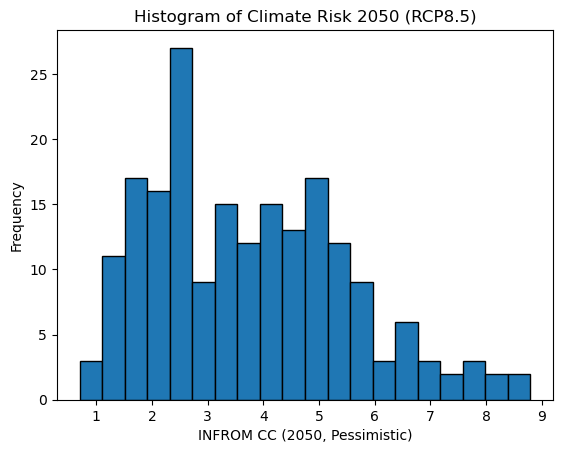

In [6]:
import matplotlib.pyplot as plt

# Extract the 'INDEX 2050 Pessimistic' values
index_2050_values = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']

# Create a histogram
plt.hist(index_2050_values, bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('INFROM CC (2050, Pessimistic)')
plt.ylabel('Frequency')
plt.title('Histogram of Climate Risk 2050 (RCP8.5)')

# Show the plot
plt.show()

In [118]:
df=Climate_Risk_INFORMCC
# Merge to get full country names
merged_df = pd.merge(df, iso_convert, left_on='Country', right_on='alpha-2', how='left')

# Filter countries where INDEX 2050 Pessimistic is between 3.5 and 3
between_3_5_and_3 = merged_df[(merged_df['INDEX 2050 Pessimistic'] <= 3.5) & (merged_df['INDEX 2050 Pessimistic'] >= 3)]

# Filter countries where INDEX 2050 Pessimistic is between 3.5 and 2.5
between_3_5_and_2_5 = merged_df[(merged_df['INDEX 2050 Pessimistic'] <= 3.5) & (merged_df['INDEX 2050 Pessimistic'] >= 2.5)]

# Print the results
print("Countries where INDEX 2050 Pessimistic is between 3.5 and 3:")
print(between_3_5_and_3['name'])

print("\nCountries where INDEX 2050 Pessimistic is between 3.5 and 2.5:")
print(between_3_5_and_2_5['name'])

Countries where INDEX 2050 Pessimistic is between 3.5 and 3:
6                             Argentina
10               Bosnia and Herzegovina
23                               Bhutan
24                             Botswana
33                                Chile
37                           Costa Rica
55                                 Fiji
56     Micronesia (Federated States of)
61                              Georgia
82                              Jamaica
110                    Marshall Islands
121                            Malaysia
142                            Paraguay
146                  Russian Federation
164                            Eswatini
171                             Tunisia
172                               Tonga
179            United States of America
186                               Samoa
Name: name, dtype: object

Countries where INDEX 2050 Pessimistic is between 3.5 and 2.5:
3                               Albania
6                             Argentina
8        

In [128]:
Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country']=='US']

,Country,INFORM 2022,INDEX 2050 Pessimistic,INFORM 2050 Optimistic,INFORM 2080 Pessimistic,INFORM 2080 Optimistic,Change in Risk
179,US,3.1,3.2,3.2,3.3,3.3,0.1


## Taking a country one at a time

How many risky countries ?

In [56]:
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, 0) # standard countries list
risky_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']
print('There are ' + str(len(risky_countries)) + ' risky countries')

There are 96 risky countries


In [ ]:
# Dictionary to store results
resulting_dataframe_country_inputs_leontief = {}

for c in risky_countries:
    code_mapping3to2 = dict(zip(iso_convert['alpha-3'], iso_convert['alpha-2']))
    # Find the index of the row where 'Country' is 'HK'
    index = Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country'] == code_mapping3to2[c]].index
    Climate_Risk_INFORMCC_sec = Climate_Risk_INFORMCC.copy()
    Climate_Risk_INFORMCC_sec.loc[index, 'INDEX 2050 Pessimistic'] = 3.5-(Climate_Risk_INFORMCC_sec.loc[index, 'INDEX 2050 Pessimistic']-3.5)/(10-3.5)*3.5
    risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC_sec,0)
    resulting_dataframe_country_inputs_leontief[c] = calculate_country_inputs(risk_level_lists_MRIOT, mriot)


In [90]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_inputs_leontief_onecountryout.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_inputs_leontief, f)

In [100]:
import pickle

# Explicit file path
file_path_pickle = 'C:/Users/delah/Documents/Code/Exposition_commerciale/Approches_IO/INFORM/results/resulting_dataframe_country_inputs_leontief_onecountryout.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_inputs_leontief = pickle.load(f)

## X/Y Graph

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

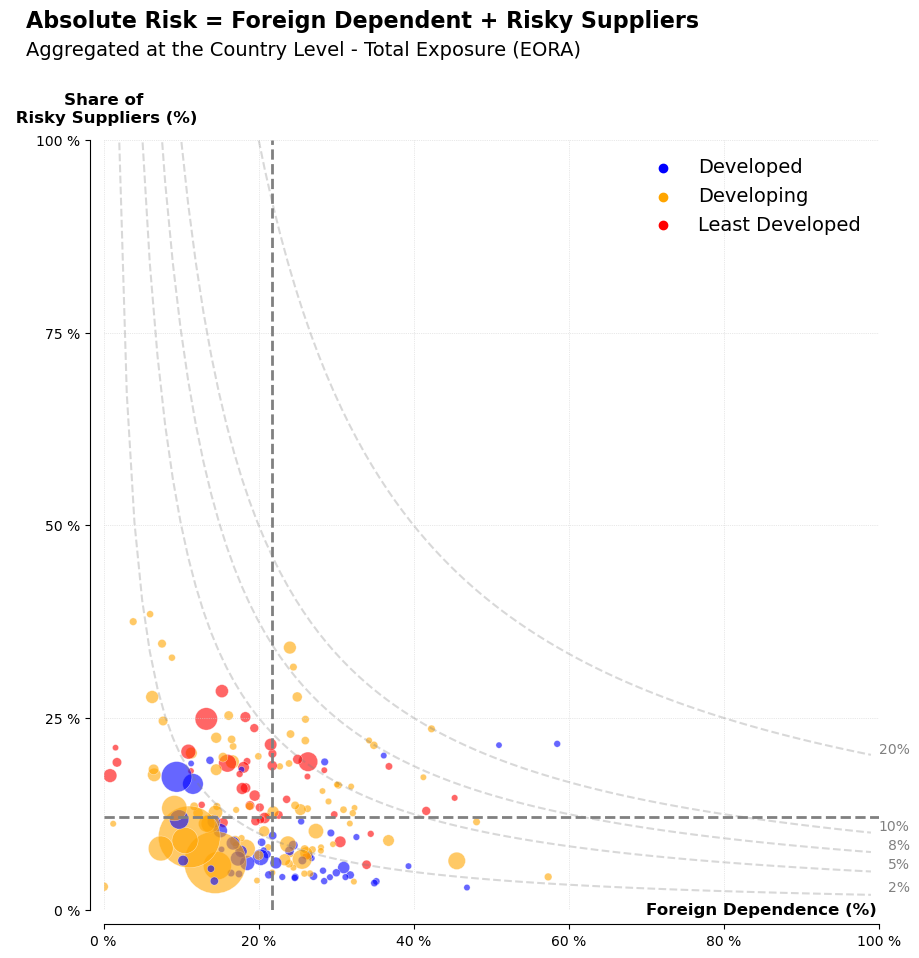

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_inputs_leontief[+1]

# Adjust the figure size as needed
plt.figure(figsize=(10, 10))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=0.3)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='grey')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        frameon=False,      # Suppress the legend box
        fontsize=14
    )
    
median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=2)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=2)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(70, 0, 'Foreign Dependence (%)', fontsize=12, va='center', ha='left', weight='bold')
plt.text(0, 102, 'Share of\n Risky Suppliers (%)', fontsize=12, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')

plt.show()

Getting an indicator to compare

In [8]:
import numpy as np

df=resulting_dataframe_country_inputs_leontief[0]

# Filter rows where Development is 'Developed'
developed_countries = df[df['Development'] == 'Developed']

# Calculate the 90th percentile of 'High Risk' in developed countries
high_risk_90th_percentile = np.percentile(developed_countries['High Risk'], 75)

print("90th percentile of High Risk in developed countries:", high_risk_90th_percentile)

import numpy as np

# Filter rows where Development is 'Developing'
developing_countries = df[df['Development'] == 'Developing']

# Filter rows where Development is 'Least Developed'
ldc_countries = df[df['Development'] == 'Least Developed']

# Concatenate the dataframes for developing and least developed countries
developing_ldc_countries = pd.concat([developing_countries, ldc_countries])

# Calculate the median of 'High Risk' for developing and least developed countries together
high_risk_median_developing_ldc = np.median(df['High Risk'])

print("Median of High Risk in developing and least developed countries together:", high_risk_median_developing_ldc)

90th percentile of High Risk in developed countries: 5.797756774647825
Median of High Risk in developing and least developed countries together: 5.836616849716054


Comparing with changing threshold

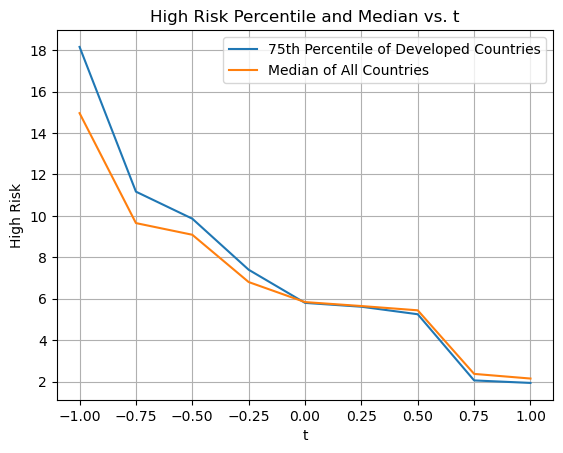

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to store t values, 80th percentiles for developed countries, and median for all countries
t_values=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]
percentile_80_developed = []
median_all_countries = []

# Iterate over t values
for c in t_values:  # Update t_values with your list of t values
    # Assuming df_t is the resulting dataframe for a specific t value
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    
    # Calculate the 80th percentile of 'High Risk' in developed countries
    high_risk_80th_percentile = np.percentile(developed_countries['High Risk'], 75)
    
    # Calculate the median of 'High Risk' for all countries
    high_risk_median = np.median(df_c['High Risk'])
    
    percentile_80_developed.append(high_risk_80th_percentile)
    median_all_countries.append(high_risk_median)

# Plotting
plt.plot(t_values, percentile_80_developed, label='75th Percentile of Developed Countries')
plt.plot(t_values, median_all_countries, label='Median of All Countries')
plt.xlabel('t')
plt.ylabel('High Risk')
plt.title('High Risk Percentile and Median vs. t')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
resulting_dataframe_country_inputs_leontief

Essai pour une autre visualisation

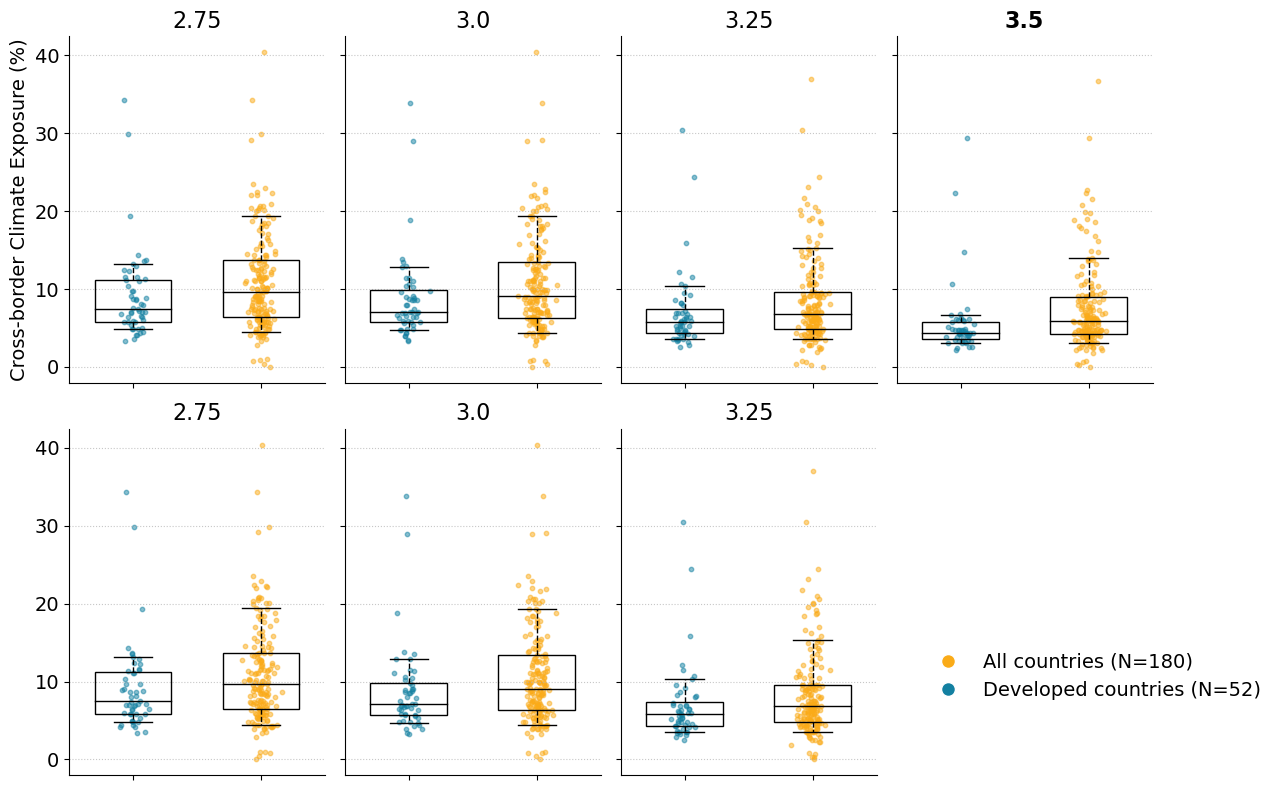

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import numpy as np

# Lists to store t values and data for developed and non-developed countries
t_values = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]
data_developed = []
data_not_developed = []

# Custom colors
colors = ['#1380A1', '#FAAB18']  # Orange for Developed, Blue for Developing/Least Developed

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk'].tolist()
    #not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk'].tolist()
    not_developed_data = df_t['High Risk'].tolist()
    
    # Append data for plotting
    data_developed.append(developed_data)
    data_not_developed.append(not_developed_data)

# Define the figure and axes for two rows
fig, axes = plt.subplots(nrows=2, ncols=len(t_values), figsize=(20, 8), sharey=True)

# Plot data in subplots
for row, t_values_row in enumerate([t_values[:4], t_values[4:]]):  # Adjusted to match your t_values splitting
    for idx, ax in enumerate(axes[row]):
        if idx < len(t_values_row):
            # Plot boxplot for developed countries
            ax.boxplot(data_developed[idx], positions=[1], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='none', color='black'),
                       medianprops=dict(color="black"),
                       whiskerprops=dict(color='black', linestyle='--'),
                       capprops=dict(color='black'),
                       flierprops=dict(marker='o', markerfacecolor=colors[0], markersize=5, markeredgecolor='black'),
                       showfliers=False,whis=[10, 90])
            
            # Plot boxplot for non-developed countries
            ax.boxplot(data_not_developed[idx], positions=[2], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='none', color='black'),
                       medianprops=dict(color="black"),
                       whiskerprops=dict(color='black', linestyle='--'),
                       capprops=dict(color='black'),
                       flierprops=dict(marker='o', markerfacecolor=colors[1], markersize=5, markeredgecolor='black'),
                       showfliers=False,whis=[10, 90])
            
            # Add jittered scatter plot for developed countries
            jitter = np.random.normal(1, 0.05, size=len(data_developed[idx]))
            ax.scatter(jitter, data_developed[idx], color=colors[0], alpha=0.5, s=10)

            # Add jittered scatter plot for non-developed countries
            jitter = np.random.normal(2, 0.05, size=len(data_not_developed[idx]))
            ax.scatter(jitter, data_not_developed[idx], color=colors[1], alpha=0.5, s=10)

            # Set x-ticks and labels off
            ax.set_xticklabels([])

            if t_values[idx]==0:
                ax.set_title(f'{t_values[idx]+3.5}', size=16,fontweight='bold')
            else:
                ax.set_title(f'{t_values[idx]+3.5}', size=16)

            # Configure y-ticks and labels
            ax.tick_params(axis='y', labelsize=14)
            if row == 0 and idx == 0:
                ax.set_ylabel('Cross-border Climate Exposure (%)', size=14)
            if row == 1:
                ax.set_ylabel('')  # Suppress y-axis label on the second line

            # Only enable y-axis grid and remove x-axis grid for clarity
            ax.yaxis.grid(True, linestyle=':', alpha=0.7)
            ax.xaxis.grid(False)

            # Hide the top and right spines to reduce visual clutter
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # Make spines darker
            for spine in ['left', 'bottom']:
                ax.spines[spine].set_color('black')

        else:
            # If the index is out of range, remove the subplot
            fig.delaxes(ax)

# Define custom legend for the scatter points
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'All countries (N={len(not_developed_data)})',  # Use f-string for formatting
           markerfacecolor='#FAAB18', markersize=10),
    Line2D([0], [0], marker='o', color='w',
           label=f'Developed countries (N={len(developed_data)})',
           markerfacecolor='#1380A1', markersize=10)
]

# Add the legend to the figure, not to the individual axes
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.55, 0.2), ncol=1, fontsize=14, frameon=False)

plt.tight_layout()

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\E\Figure2a.png')

# Display the plot
plt.show()

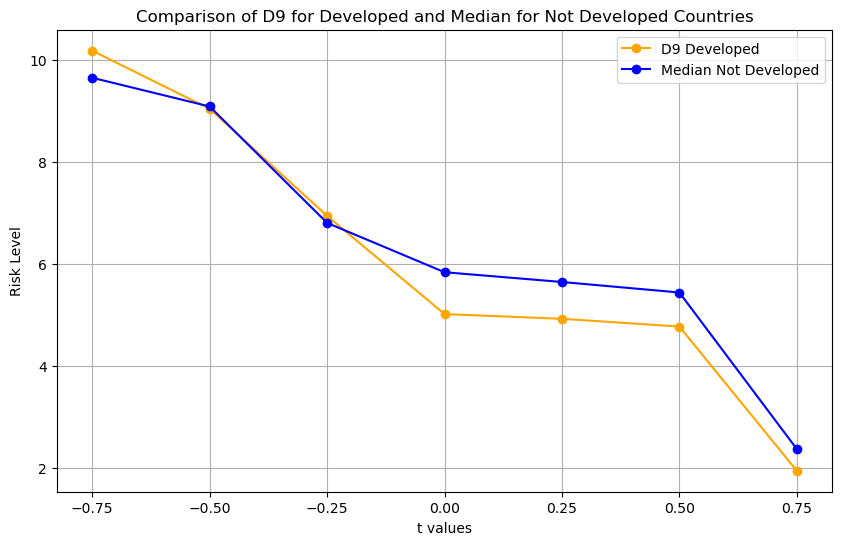

In [34]:
# Lists to store t values
t_values = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]
d9_developed = []
median_not_developed = []

# Iterate over t values
for t in t_values:
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk']
    #not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk']
    not_developed_data = df_t['High Risk']
    
    # Check if there is any data to process and calculate D9 for developed and median for not developed
    if not developed_data.empty:
        d9_developed.append(np.percentile(developed_data, 70))
    else:
        d9_developed.append(np.nan)  # Append NaN if no data
    
    if not not_developed_data.empty:
        median_not_developed.append(np.median(not_developed_data))
    else:
        median_not_developed.append(np.nan)  # Append NaN if no data

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(t_values, d9_developed, marker='o', linestyle='-', color='orange', label='D9 Developed')
plt.plot(t_values, median_not_developed, marker='o', linestyle='-', color='blue', label='Median Not Developed')

# Adding labels and title
plt.xlabel('t values')
plt.ylabel('Risk Level')
plt.title('Comparison of D9 for Developed and Median for Not Developed Countries')
plt.xticks(t_values)
plt.grid(True)

# Adding a legend
plt.legend()

# Show the plot
plt.show()

In [14]:
not_developed_data

Series([], Name: High Risk, dtype: float64)

In [202]:
len(developed_data)

52

Comparing with taking one country out at a time

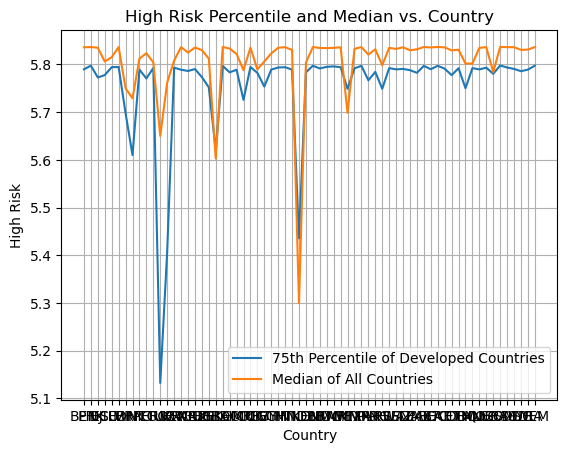

In [189]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to store t values, 80th percentiles for developed countries, and median for all countries
risky_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']
percentile_75_developed = []
median_all_countries = []

# Iterate over t values
for c in risky_countries:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    
    # Calculate the 80th percentile of 'High Risk' in developed countries
    high_risk_75th_percentile = np.percentile(developed_countries['High Risk'], 75)
    
    # Calculate the median of 'High Risk' for all countries
    high_risk_median = np.median(df_c['High Risk'])
    
    percentile_75_developed.append(high_risk_75th_percentile)
    median_all_countries.append(high_risk_median)

# Plotting
plt.plot(risky_countries, percentile_75_developed, label='75th Percentile of Developed Countries')
plt.plot(risky_countries, median_all_countries, label='Median of All Countries')
plt.xlabel('Country')
plt.ylabel('High Risk')
plt.title('High Risk Percentile and Median vs. Country')
plt.legend()
plt.grid(True)
plt.show()

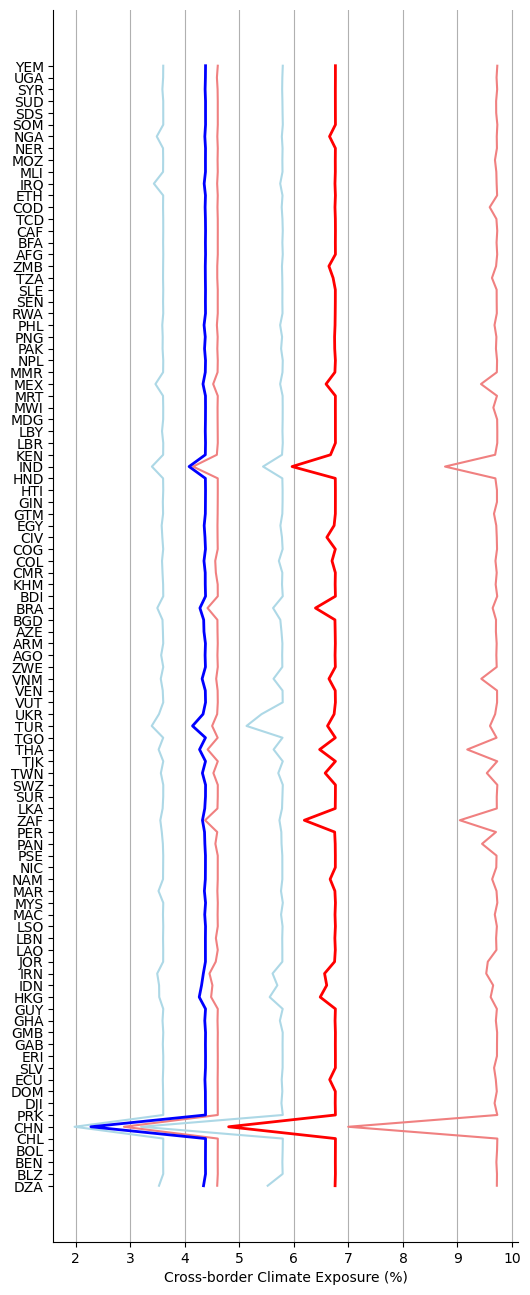

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to store t values, quartiles, and median for developed and non-developed countries
risky_countries = risk_level_lists_MRIOT['MR'] + risk_level_lists_MRIOT['HR'] + risk_level_lists_MRIOT['VHR']
quartile_25_developed = []
quartile_75_developed = []
quartile_25_non_developed = []
quartile_75_non_developed = []
median_developed = []
median_non_developed = []

# Iterate over countries
for c in risky_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    # Filter rows where Development is not 'Developed' (i.e., non-developed)
    non_developed_countries = df_c[df_c['Development'] != 'Developed']
    
    # Calculate the quartiles of 'High Risk' for developed countries
    quartile_25_dev = np.percentile(developed_countries['High Risk'], 25)
    quartile_75_dev = np.percentile(developed_countries['High Risk'], 75)
    
    # Calculate the quartiles of 'High Risk' for non-developed countries
    quartile_25_non_dev = np.percentile(non_developed_countries['High Risk'], 25)
    quartile_75_non_dev = np.percentile(non_developed_countries['High Risk'], 75)
    
    # Calculate the median of 'High Risk' for developed and non-developed countries
    median_dev = np.median(developed_countries['High Risk'])
    median_non_dev = np.median(non_developed_countries['High Risk'])
    
    quartile_25_developed.append(quartile_25_dev)
    quartile_75_developed.append(quartile_75_dev)
    quartile_25_non_developed.append(quartile_25_non_dev)
    quartile_75_non_developed.append(quartile_75_non_dev)
    median_developed.append(median_dev)
    median_non_developed.append(median_non_dev)

    
# Plotting
plt.figure(figsize=(6, 16))

# Plotting
plt.plot(quartile_25_developed, risky_countries, color='lightblue')
plt.plot(quartile_75_developed, risky_countries, color='lightblue')
plt.plot(quartile_25_non_developed, risky_countries, color='lightcoral')
plt.plot(quartile_75_non_developed, risky_countries, color='lightcoral')
plt.plot(median_developed, risky_countries, color='blue', linewidth=2)
plt.plot(median_non_developed, risky_countries, color='red', linewidth=2)

plt.xlabel('Cross-border Climate Exposure (%)')
# Hide the top and right spines to reduce visual clutter
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x')  # Show only vertical grid lines

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure8.png')

plt.show()

In [9]:
median_non_developed

[6.756185048269545,
 6.761918319346408,
 6.760683875462135,
 6.761567879624589,
 6.762654199548184,
 4.804879985468349,
 6.762408718543078,
 6.7584269562270975,
 6.760649927224028,
 6.657120363577693,
 6.761760044219795,
 6.762003223850082,
 6.760781180215032,
 6.762003361579026,
 6.755698658562425,
 6.7617648570382025,
 6.4832689833181805,
 6.602751165568689,
 6.563248302011429,
 6.746852220671156,
 6.760279969952417,
 6.752124783944932,
 6.761700004453685,
 6.755012173846433,
 6.762654199548184,
 6.75280292964435,
 6.665003414302564,
 6.760670282628238,
 6.760942269770126,
 6.758443652634675,
 6.748263903124958,
 6.191955443499088,
 6.759099311148754,
 6.761492436144509,
 6.762654199548184,
 6.574268821955866,
 6.762436107096777,
 6.4732458310276115,
 6.761056537959731,
 6.617454958828796,
 6.738365844187815,
 6.762157243317176,
 6.759063379099812,
 6.6437077467666406,
 6.760854265226321,
 6.7558834076480245,
 6.7608465734700145,
 6.757750534956008,
 6.753518420536903,
 6.39612355400

In [191]:
# Lists to store t values, 80th percentiles for developed countries, and median for all countries
risky_countries = risk_level_lists_MRIOT['MR'] + risk_level_lists_MRIOT['HR'] + risk_level_lists_MRIOT['VHR']
positive_difference_countries = []

# Iterate over risky countries
for c in risky_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    
    # Calculate the 75th percentile of 'High Risk' in developed countries
    high_risk_75th_percentile = np.percentile(developed_countries['High Risk'], 70)
    
    # Calculate the median of 'High Risk' for all countries
    high_risk_median = np.median(df_c['High Risk'])
    
    # Calculate the difference
    difference = high_risk_75th_percentile - high_risk_median
    
    # Check if the difference is positive
    if difference > 0:
        positive_difference_countries.append(c)

# Print the countries where the difference is positive
print("Countries where the difference between 75th Percentile of Developed Countries and Median of All Countries is positive:")
for country in positive_difference_countries:
    print(country)

Countries where the difference between 75th Percentile of Developed Countries and Median of All Countries is positive:


## Correlation Graph

Plot Graph

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_6484\2369311748.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Index 2050 (RCP8.5)',

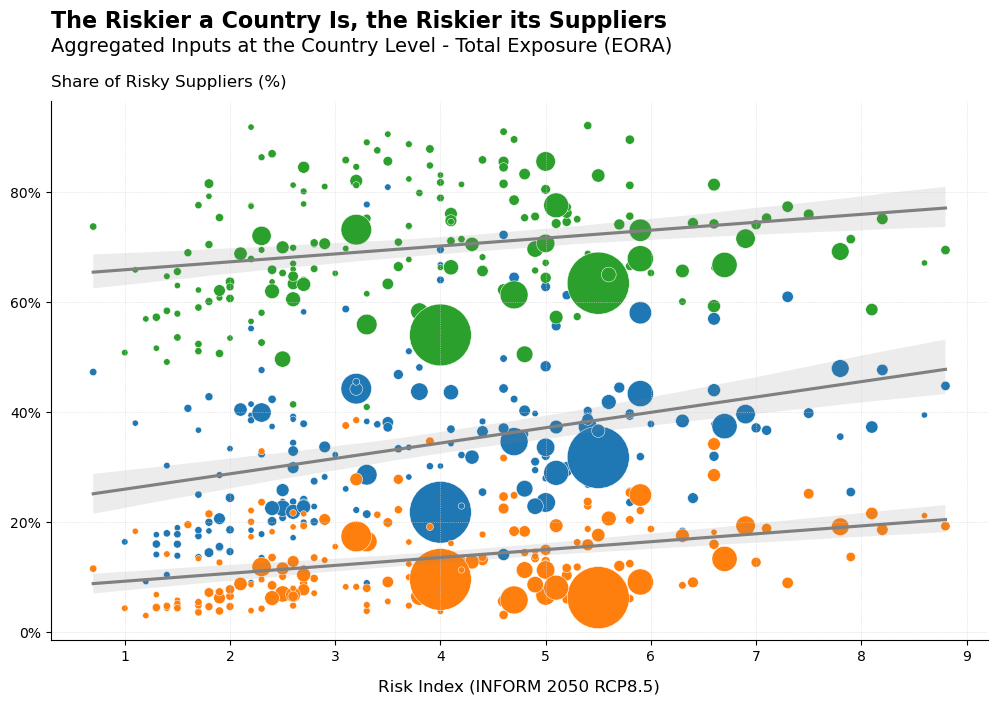

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Create a scatter plot with the custom color palette
plt.figure(figsize=(15, 7))

t_values = [0,1,-1]

for t in t_values:
    result_name = f"resulting_dataframe_country_inputs_leontief_{t}"
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                                data=results[result_name], 
                                palette=custom_palette, 
                                size='Population (2023)', 
                                sizes=(20, 2000))

# Extract handles and labels
handles, labels = scatter.get_legend_handles_labels()

# Identify number of unique regions to include in the legend
num_regions = len(result['Country'].unique())

# Create new legend with only the first `num_regions` handles
plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
plt.legend().set_visible(False)

# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Regression
for t in t_values:
    result_name = f"resulting_dataframe_country_inputs_leontief_{t}"
    sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=results[result_name], scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')


#Titles
#####
plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Risk Index (INFORM 2050 RCP8.5)', ha='center', va='bottom', transform=ax.transAxes, fontsize=12) 
plt.text(0, 1.05, 'Share of Risky Suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

# Show the plot
#####
plt.show()

A graph with threshold on x axis and R2 and p value on y axis

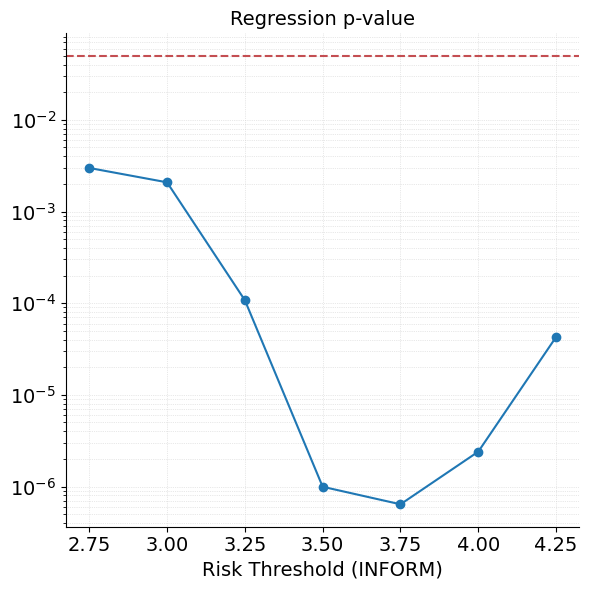

In [568]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store t values, p-values, and R-squared values
t_values = [-0.75,-0.5,-0.25,0,0.25,0.5,0.75]
p_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Extracting the columns for regression
    x = df_t['Index 2050 (RCP8.5)']
    y = df_t['High Risk (relative)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append p-value to list
    p_values.append(p_value)

# Convert lists to numpy arrays
t_values = np.array(t_values)
p_values = np.array(p_values)

# Plotting P-values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, p_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (INFORM)',fontsize=14)
plt.ylabel('')
plt.title('Regression p-value',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

plt.yscale('log')  # Setting logarithmic scale on y-axis
plt.axhline(y=0.05, color='r', linestyle='--')  # Add horizontal line at y = 0.05 in red

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label
# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

plt.tight_layout()

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\E\Figure4b.png')


plt.show()

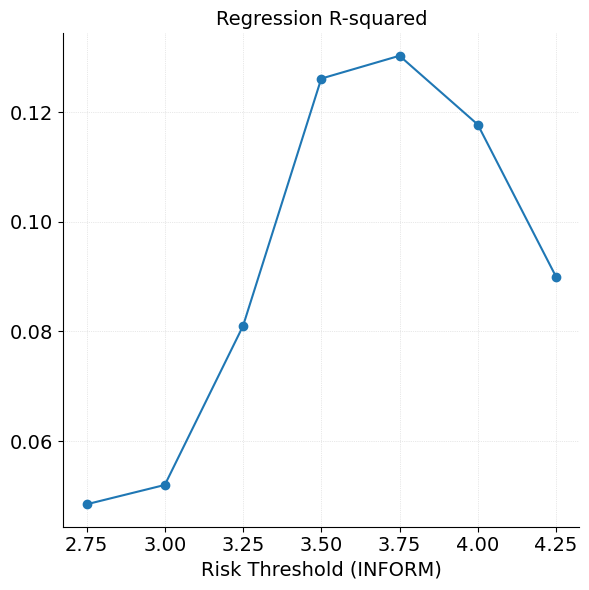

In [584]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from scipy import stats
# Lists to store t values and R-squared values
t_values = [ -0.75,-0.5,-0.25, 0,0.25, 0.5,0.75]
r_squared_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_inputs_leontief[t]
    
    # Extracting the columns for regression
    x = df_t['Index 2050 (RCP8.5)']
    y = df_t['High Risk (relative)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append R-squared value to list
    r_squared_values.append(r_value**2)

# Convert lists to numpy arrays
t_values = np.array(t_values)
r_squared_values = np.array(r_squared_values)

# Plotting R-squared values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, r_squared_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (INFORM)',fontsize=14)
plt.ylabel('')
plt.title('Regression R-squared',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label
# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

# Save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\E\Figure4a.png')


plt.tight_layout()
plt.show()

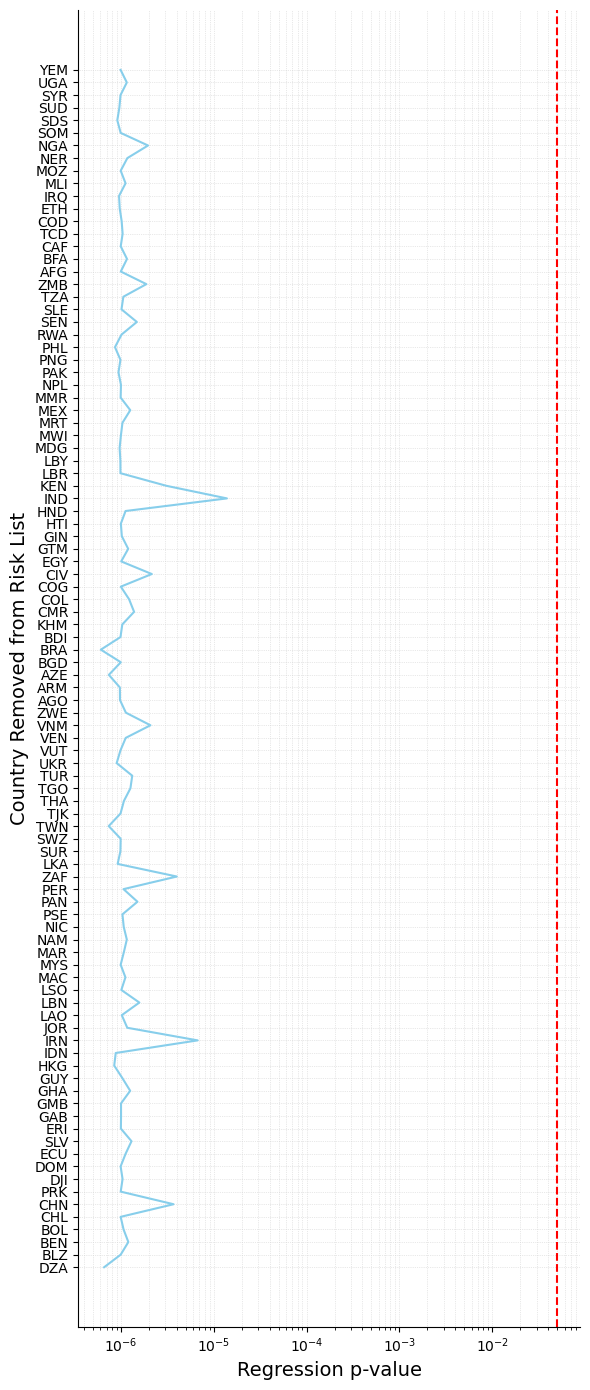

In [99]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store p-values
p_values = []

for c in risky_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Extracting the columns for regression
    x = df_c['Index 2050 (RCP8.5)']
    y = df_c['High Risk (relative)']
    
    # Perform linear regression
    _, _, _, p_value, _ = stats.linregress(x, y)
    
    # Append p-value to list
    p_values.append(p_value)

# Convert lists to numpy arrays
c_values = np.array(risky_countries)
p_values = np.array(p_values)

# Plotting P-values vs. country, but switching axes
plt.figure(figsize=(6, 14))
plt.plot(p_values, c_values, color='skyblue')
plt.ylabel('Country Removed from Risk List',size=14)
plt.xlabel('Regression p-value',size=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

plt.xscale('log')  # Setting logarithmic scale on x-axis
plt.axvline(x=0.05, color='r', linestyle='--')  # Add vertical line at x = 0.05 in red

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

# Optional: save the plot to a file
plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure9b.png')

plt.show()

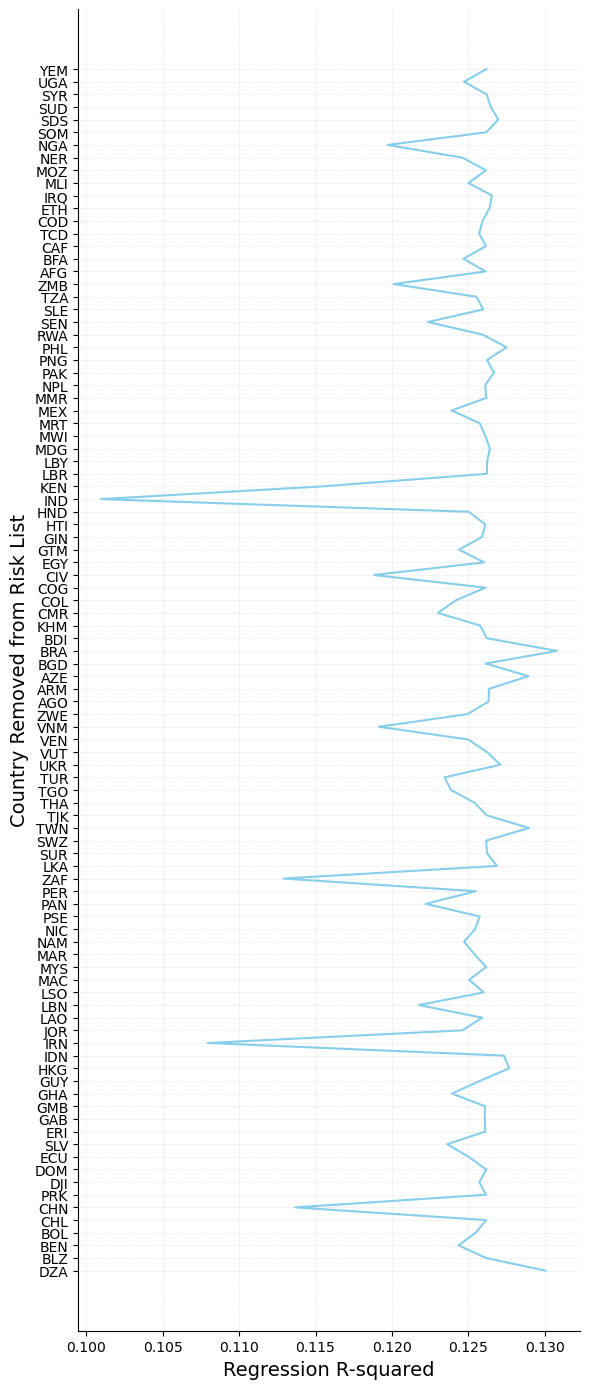

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store R-squared values
r_squared_values = []

# Assuming risky_countries is defined elsewhere as a list of country names
for c in risky_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_inputs_leontief[c]
    
    # Extracting the columns for regression
    x = df_c['Index 2050 (RCP8.5)']
    y = df_c['High Risk (relative)']
    
    # Perform linear regression
    _, _, r_value, _, _ = stats.linregress(x, y)
    
    # Append R-squared value to list
    r_squared_values.append(r_value**2)

# Convert lists to numpy arrays
c_values = np.array(risky_countries)
r_squared_values = np.array(r_squared_values)

# Plotting R-squared values vs. country, switching axes
plt.figure(figsize=(6, 14))  # Adjusted for better vertical layout
plt.plot(r_squared_values, c_values, color='skyblue')  # Using horizontal bar plot
plt.xlabel('Regression R-squared',size=14)
plt.ylabel('Country Removed from Risk List',size=14)
#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure9a.png')

plt.show()

In [98]:
# Sort the list by p-value
sorted_by_p_value = sorted(country_data, key=lambda x: x[1], reverse=True)
# Sort the list by R-squared value
sorted_by_r_squared = sorted(country_data, key=lambda x: x[2])

# Print the top 10 countries with the highest p-values
print("Top 10 countries with highest p-values:")
for i, (country, p_value, r_squared) in enumerate(sorted_by_p_value[:10], 1):
    print(f"{i}. {country}: p-value = {p_value}, R-squared = {r_squared}")

# Print the top 10 countries with the lowest R-squared values
print("\nTop 10 countries with lowest R-squared values:")
for i, (country, p_value, r_squared) in enumerate(sorted_by_r_squared[:10], 1):
    print(f"{i}. {country}: p-value = {p_value}, R-squared = {r_squared}")

Top 10 countries with highest p-values:
1. IND: p-value = 1.3856643983794522e-05, R-squared = 0.10094627960311009
2. IRN: p-value = 6.706850775388117e-06, R-squared = 0.10794035460814383
3. ZAF: p-value = 3.999986293804819e-06, R-squared = 0.1129005202795584
4. CHN: p-value = 3.6911241862229196e-06, R-squared = 0.11367008128290237
5. KEN: p-value = 3.0882012444404887e-06, R-squared = 0.11537633398174095
6. CIV: p-value = 2.1524305315180896e-06, R-squared = 0.11882306281479248
7. VNM: p-value = 2.0804492872282463e-06, R-squared = 0.11914733768913935
8. NGA: p-value = 1.9589760907874138e-06, R-squared = 0.11972069144622961
9. ZMB: p-value = 1.880073991825949e-06, R-squared = 0.1201123316017525
10. LBN: p-value = 1.5803331182287717e-06, R-squared = 0.12176546556378744

Top 10 countries with lowest R-squared values:
1. IND: p-value = 1.3856643983794522e-05, R-squared = 0.10094627960311009
2. IRN: p-value = 6.706850775388117e-06, R-squared = 0.10794035460814383
3. ZAF: p-value = 3.999986293

## Histogram

Graphically

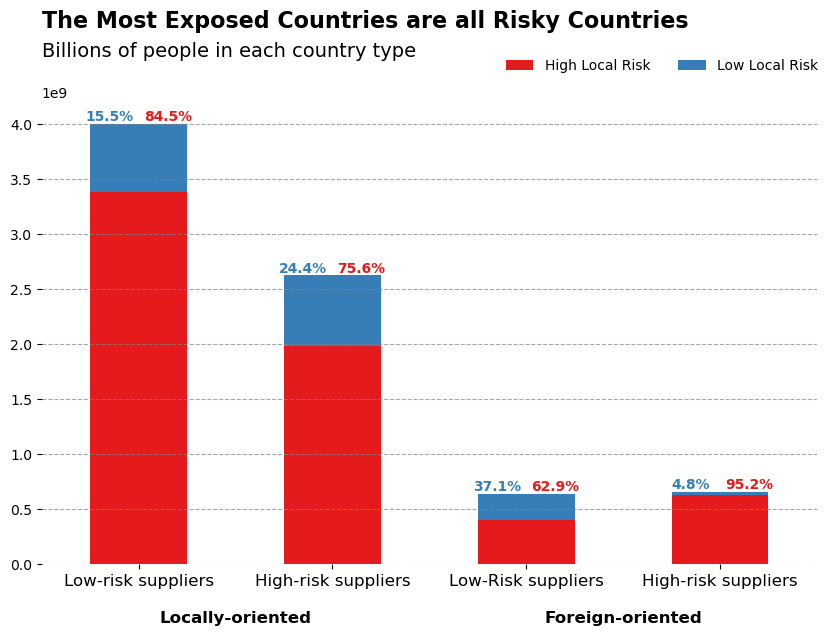

In [195]:
t=0
df = resulting_dataframe_country_inputs_leontief[t]
# Calculate the median values for 'High Risk (imports)' and 'Foreign (%)'
median_high_risk_imports = df['High Risk (relative)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=10,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=12)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=12,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.12), ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

# Show the plot
#plt.tight_layout()
plt.show()

In [198]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100

Percentage of population in High Local Risk among High-risk suppliers and Foreign-oriented: 95.2%


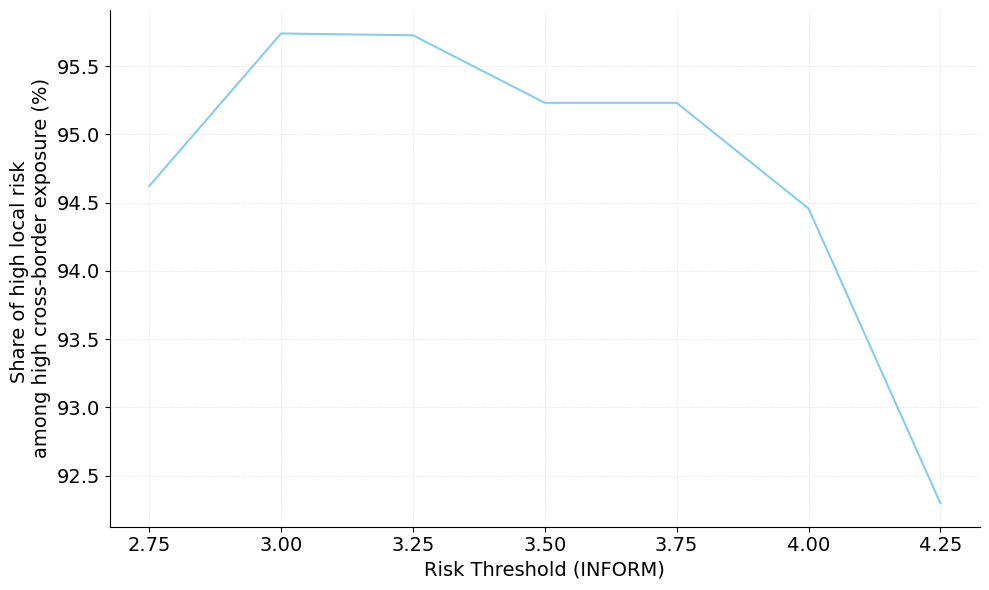

In [585]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store t values and the final percentage for each t
t_values =[-0.75,-0.5,-0.25,0,0.25,0.5,0.75]
percentages = []

# Iterate over each t
for t in t_values:
    # Set df to resulting_dataframe_country_inputs_leontief[t]
    df = resulting_dataframe_country_inputs_leontief[t]
    # Calculate the median values for 'High Risk (imports)' and 'Foreign (%)'
    median_high_risk_imports = df['High Risk (relative)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add columns to indicate if each row is over or under the median for the specified columns
    df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

    # Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

    # Group the sorted data
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

    # Unstack the 'Local Risk' level to prepare for a stacked bar chart
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

    # Define the custom order
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
    ]

    # Reorder the DataFrame according to the custom order
    population_by_risk = population_by_risk.loc[custom_order]

    # Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
    total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
    total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
    percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100
    
    # Append t and the final percentage to the lists
    percentages.append(percentage_high_local_risk)

# Plot using a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.plot(t_values, percentages, color='skyblue')
plt.ylabel('Share of high local risk \namong high cross-border exposure (%)',size=14)
plt.xlabel('Risk Threshold (INFORM)',size=14)


#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label

# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

plt.tight_layout()

plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\E\Figure3a.png')

plt.show() 

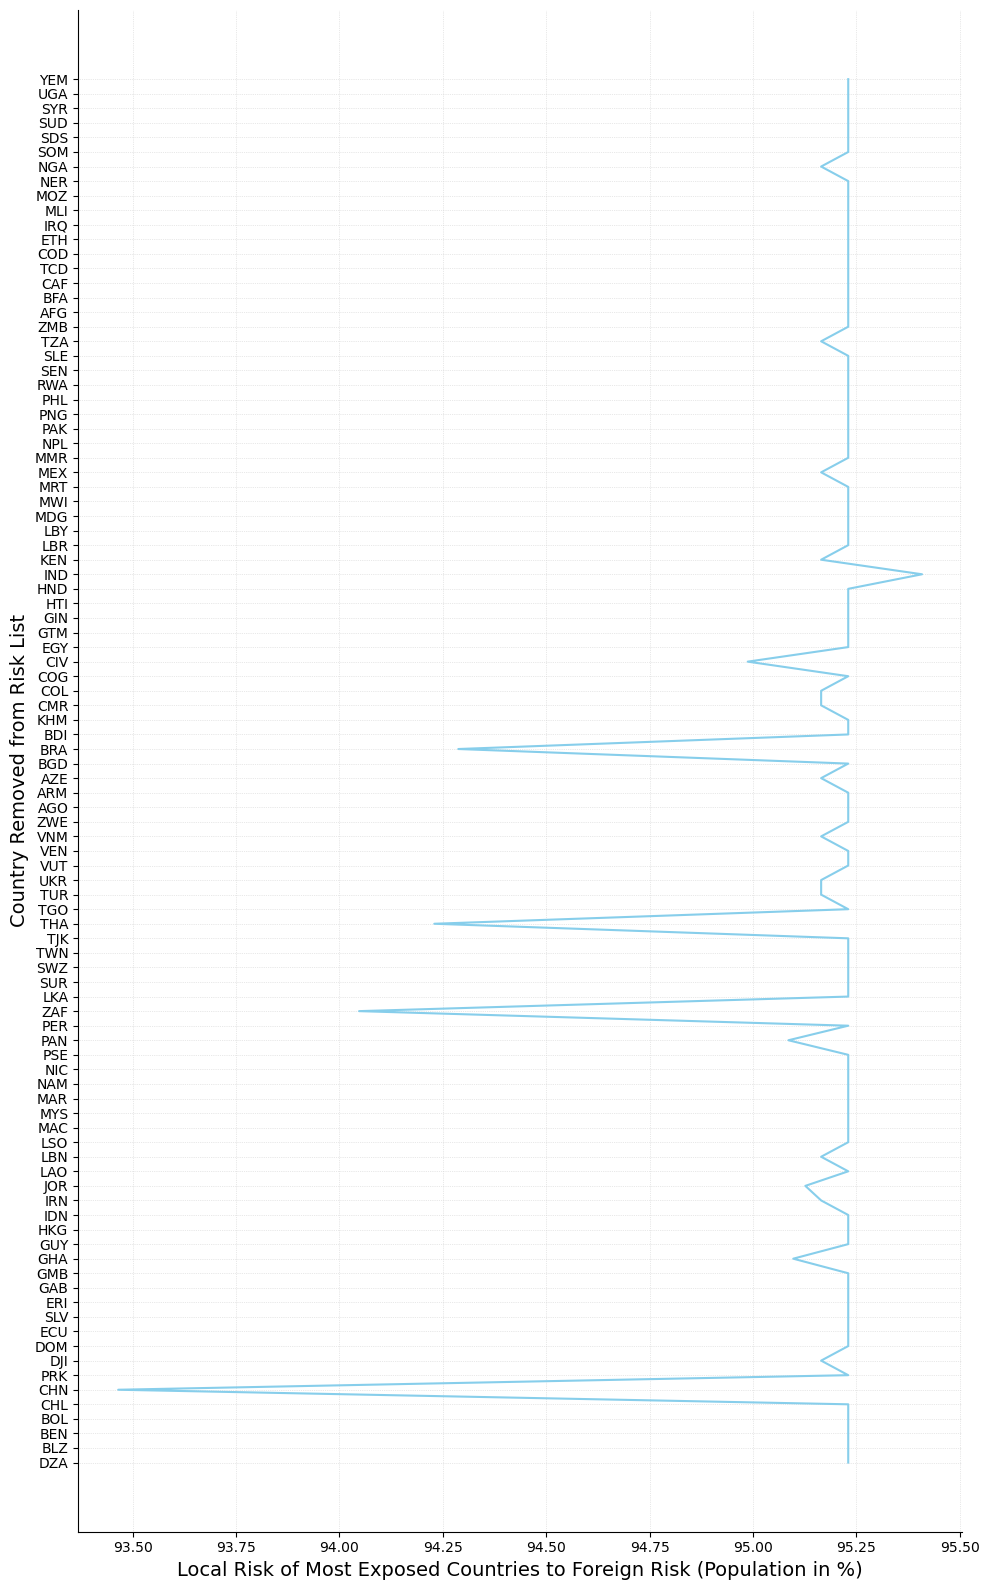

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store t values and the final percentage for each t
percentages = []

for c in risky_countries:
    # Set df to the resulting dataframe for a specific country
    df = resulting_dataframe_country_inputs_leontief[c]
    # Calculate median values for 'High Risk (imports)' and 'Foreign (%)'
    median_high_risk_imports = df['High Risk (relative)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add category columns based on median values
    df['High Risk (relative) Category'] = df['High Risk (relative)'].apply(
        lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(
        lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

    # Sort and group the DataFrame
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population (2023)'].sum()

    # Unstack and reorder data for plotting
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
    ]
    population_by_risk = population_by_risk.loc[custom_order]

    # Calculate percentages
    total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
    total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
    percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100

    percentages.append(percentage_high_local_risk)

# Plot using a horizontal bar chart
plt.figure(figsize=(10, 16))
plt.plot(percentages, risky_countries, color='skyblue')
plt.xlabel('Local Risk of Most Exposed Countries to Foreign Risk (Population in %)',size=14)
plt.ylabel('Country Removed from Risk List',size=14)


#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure10.png')

plt.show() 